<a href="https://colab.research.google.com/github/Necrotox/Python-Russian/blob/master/%D0%91%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82_%D0%9F%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Начало

In [1]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [2]:
!pip install -q --no-warn-script-location --index-url https://download.pytorch.org/whl/cpu \
  torch==2.7.1+cpu > /dev/null 2>&1

!pip install -q --no-warn-script-location --index-url https://download.pytorch.org/whl/cpu \
  torchvision==0.22.0+cpu > /dev/null 2>&1
!pip install -q --no-warn-script-location --index-url https://download.pytorch.org/whl/cpu \
  torchaudio==2.7.1+cpu > /dev/null 2>&1

!pip install -q --no-warn-script-location \
  pytorch-lightning==2.5.2 pytorch-forecasting==1.4.0 > /dev/null 2>&1

!pip install -q tinkoff-investments dill telebot --upgrade mplfinance > /dev/null 2>&1


import asyncio
import contextlib
import functools
import statsmodels.api as sm
import inspect
import zipfile
import tracemalloc
import pickle
import html
import json
import gc
import re
import io
import time
import logging
import pytz
import gzip
import dill
import lzma
import pandas as pd
import nest_asyncio
import hashlib
import random
import joblib
import math
import psutil

import scipy.sparse as sp
import scipy.sparse.linalg as spla

from decimal import Decimal, ROUND_HALF_UP
from numba import jit, njit
from grpc import StatusCode
from grpc.aio import AioRpcError
from contextlib import redirect_stderr, redirect_stdout
from tinkoff.invest import AsyncClient, CandleInterval, MoneyValue, Quotation, Client
from tinkoff.invest.exceptions import RequestError
from tinkoff.invest import (
    AsyncClient,
    #CandleInstrument,
    MarketDataRequest,
    #SubscribeCandlesRequest,
    #SubscriptionAction,
    SubscriptionInterval,
)
from tinkoff.invest.schemas import (
    AccountType,
    SubscribeCandlesRequest,
    SubscriptionAction,
    CandleInstrument,
)
from tinkoff.invest.market_data_stream.market_data_stream_manager import MarketDataRequest
from tinkoff.invest.schemas import Candle
from statsmodels.tsa.seasonal import STL
from scipy.stats import norm
from sklearn.ensemble import IsolationForest
from collections import defaultdict, deque
from multiprocessing import Process
from multiprocessing import Process
from datetime import datetime as dt
from datetime import timedelta
import numpy as np
import mplfinance as mpf
import matplotlib.pyplot as plt
import telebot
import datetime
import matplotlib
from sklearn.neighbors import NearestNeighbors
from scipy.signal import lfilter

from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from scipy.stats import norm, pearsonr
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import BaseCrossValidator

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, PowerTransformer, QuantileTransformer, RobustScaler, StandardScaler

from sklearn.neighbors import BallTree

from bisect import bisect_left

from pandas.tseries.frequencies import to_offset
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data.encoders import EncoderNormalizer
from pytorch_forecasting.metrics import Metric, QuantileLoss
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.callbacks.progress import RichProgressBar, TQDMProgressBar
from pytorch_lightning.loggers import TensorBoardLogger

from torchmetrics import MeanSquaredError
from torchmetrics.functional import mean_squared_error as torchmetrics_mse

import torch
import torch.nn as nn
import torch.nn.functional as F

from typing import Any, Dict, Iterable, Iterator, List, Literal, Mapping, Optional, Tuple, Set
import os, gc, warnings, typing as tp

from collections import deque, defaultdict
from dataclasses import dataclass, field
from typing import Deque, Dict, Any, Optional, Tuple, List
from __future__ import annotations

from lightgbm import LGBMRegressor
import lightgbm as lgb

matplotlib.use("agg")
%matplotlib inline
import warnings

warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings('ignore')

import psutil
import os.path

model_out_configuration = 3

In [3]:
class TinkoffHistoricalDataCollector:
    def __init__(self):
        self.sma_state = {}

    def generateVar(self, high_array, low_array, moving_average_length=10):
        valpha = 2 / (moving_average_length + 1)
        hl2 = (high_array + low_array) / 2

        before_val = hl2[0] if len(hl2) > 0 else 0

        vud1 = []
        vdd1 = []
        for current_hl2 in hl2:
            if current_hl2 > before_val:
                vud1.append(current_hl2 - before_val)
                vdd1.append(0)
            elif current_hl2 < before_val:
                vdd1.append(before_val - current_hl2)
                vud1.append(0)
            else:
                vud1.append(0)
                vdd1.append(0)
            before_val = current_hl2

        def calculate_window_sums(arr, window_size=9):
          return [sum(arr[max(0, i - window_size + 1):i+1]) for i in range(len(arr))]

        vUD = calculate_window_sums(vud1, 9)
        vDD = calculate_window_sums(vdd1, 9)

        vUD_ar = np.array(vUD)
        vDD_ar = np.array(vDD)

        epsilon = 1e-10
        with np.errstate(divide='ignore', invalid='ignore'):
            vCMO = np.divide(vUD_ar - vDD_ar, vUD_ar + vDD_ar + epsilon)

        vCMO = np.nan_to_num(vCMO, nan=0.0)

        var = []
        var_before = 0.0
        for i in range(len(hl2)):
            if i < len(vCMO):
                cmo = abs(vCMO[i])
                var_current = (valpha * cmo * hl2[i]) + (1 - valpha * cmo) * var_before
            else:
                var_current = var_before
            var.append(var_current)
            var_before = var_current

        return np.array(var)

    def generateAma(self, high_array, low_array, close_array, atr_period=14, min_period=5, max_period=50):
        """
        Генерация адаптивного скользящего среднего на основе волатильности.

        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param close_array: Массив значений close.
        :param atr_period: Период для расчета ATR.
        :param min_period: Минимальный период скользящего среднего.
        :param max_period: Максимальный период скользящего среднего.
        :return: Массив значений адаптивного скользящего среднего.
        """
        # Рассчитываем ATR
        atr = self._calculate_atr(high_array, low_array, close_array, atr_period)

        # Нормализуем ATR для использования в качестве коэффициента
        normalized_atr = (atr - np.min(atr)) / (np.max(atr) - np.min(atr) + 1e-10)

        # Рассчитываем динамический период
        dynamic_period = min_period + (max_period - min_period) * normalized_atr

        # Рассчитываем адаптивное скользящее среднее (гибрид SMA и EMA)
        adaptive_ma = np.zeros_like(close_array)
        for i in range(len(close_array)):
            if i < int(dynamic_period[i]):
                adaptive_ma[i] = np.mean(close_array[:i+1])  # SMA для начальных значений
            else:
                period = int(dynamic_period[i])
                alpha = 2 / (period + 1)
                adaptive_ma[i] = alpha * close_array[i] + (1 - alpha) * adaptive_ma[i-1]  # EMA

        return adaptive_ma

    def _calculate_atr(self, high_array, low_array, close_array, period=14):
        """
        Рассчитывает Average True Range (ATR).

        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param close_array: Массив значений close.
        :param period: Период для расчета ATR.
        :return: Массив значений ATR.
        """
        tr = np.zeros_like(high_array)
        tr[0] = high_array[0] - low_array[0]

        for i in range(1, len(high_array)):
            hl = high_array[i] - low_array[i]
            hc = abs(high_array[i] - close_array[i-1])
            lc = abs(low_array[i] - close_array[i-1])
            tr[i] = max(hl, hc, lc)

        atr = np.zeros_like(tr)
        atr[period-1] = np.mean(tr[:period])

        for i in range(period, len(tr)):
            atr[i] = (atr[i-1] * (period-1) + tr[i]) / period

        return atr

    def generateAtr(self, high_array, low_array, close_array, period=14):

        # Рассчитываем True Range (TR)
        tr1 = high_array - low_array
        tr2 = np.abs(high_array - np.roll(close_array, 1))
        tr3 = np.abs(low_array - np.roll(close_array, 1))

        tr = np.maximum(tr1, np.maximum(tr2, tr3))

        # Рассчитываем ATR
        atr = np.zeros_like(tr)
        atr[period - 1] = np.mean(tr[:period])

        for i in range(period, len(tr)):
            atr[i] = (atr[i - 1] * (period - 1) + tr[i]) / period

        return atr

    def generateSma(self, high_array, low_array, window=10):
        """
        Генерация Simple Moving Average (SMA).

        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param window: Период SMA.
        :return: Массив значений SMA.
        """
        hl2 = (high_array + low_array) * 0.5

        if window <= 1:
            return hl2

        # Создаем массив для результатов с NaN
        sma = np.full_like(hl2, np.nan)

        # Рассчитываем кумулятивную сумму
        cumsum = np.cumsum(hl2)

        # Создаем сдвинутый кумулятивный массив
        shifted_cumsum = np.zeros_like(cumsum)
        shifted_cumsum[window:] = cumsum[:-window]

        # Вычисляем SMA для валидных периодов
        valid = slice(window - 1, None)
        sma[valid] = (cumsum[valid] - shifted_cumsum[valid]) / window

        return sma

    def generatePMax(self, var_array, close_array, high_array, low_array, atr_period, atr_multiplier):
        """
        Генерация PMax (Profit Maximizer).

        :param var_array: Массив значений скользящего среднего.
        :param close_array: Массив значений close.
        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param atr_period: Период для расчета ATR.
        :param atr_multiplier: Множитель ATR.
        :return: Массив значений PMax.
        """
        try:
            atr = self.generateAtr(high_array, low_array, close_array, period=atr_period)
        except Exception as exp:
            print('exception in atr:', str(exp), flush=True)
            return []

        previous_final_upperband = 0
        previous_final_lowerband = 0
        final_upperband = 0
        final_lowerband = 0
        previous_var = 0
        previous_pmax = 0
        pmax = []
        pmaxc = 0

        for i in range(0, len(close_array)):
            if np.isnan(close_array[i]):
                pass
            else:
                atrc = atr[i]
                varc = var_array[i]

                if math.isnan(atrc):
                    atrc = 0

                basic_upperband = varc + atr_multiplier * atrc
                basic_lowerband = varc - atr_multiplier * atrc

                if basic_upperband < previous_final_upperband or previous_var > previous_final_upperband:
                    final_upperband = basic_upperband
                else:
                    final_upperband = previous_final_upperband

                if basic_lowerband > previous_final_lowerband or previous_var < previous_final_lowerband:
                    final_lowerband = basic_lowerband
                else:
                    final_lowerband = previous_final_lowerband

                if previous_pmax == previous_final_upperband and varc <= final_upperband:
                    pmaxc = final_upperband
                else:
                    if previous_pmax == previous_final_upperband and varc >= final_upperband:
                        pmaxc = final_lowerband
                    else:
                        if previous_pmax == previous_final_lowerband and varc >= final_lowerband:
                            pmaxc = final_lowerband
                        elif previous_pmax == previous_final_lowerband and varc <= final_lowerband:
                            pmaxc = final_upperband

                pmax.append(pmaxc)

                previous_var = varc

                previous_final_upperband = final_upperband

                previous_final_lowerband = final_lowerband

                previous_pmax = pmaxc

        return pmax

    def generate_signals(self, df, moving_average_length=10, atr_period=10, atr_multiplier=3, average_type='SMA',
                        ama_params=None):
        """
        Генерация сигналов на основе SMA или AMA.

        :param df: DataFrame с данными.
        :param moving_average_length: Период скользящего среднего.
        :param atr_period: Период ATR.
        :param atr_multiplier: Множитель ATR.
        :param average_type: Тип скользящего среднего ('SMA' или 'AMA').
        :param ama_params: Параметры для AMA (если используется).
        :return: DataFrame с добавленными сигналами.
        """
        high_array = df["high"].values
        low_array = df["low"].values
        close_array = df["close"].values
        df = df.copy()

        if average_type == 'SMA':
            ma_arr = self.generateSma(high_array, low_array, moving_average_length)
        elif average_type == 'VAR':
            ma_arr = self.generateVar(high_array, low_array, moving_average_length)
        elif average_type == 'AMA':
            if ama_params is None:
                raise ValueError("Для AMA необходимо указать параметры ama_params.")
            ma_arr = self.generateAma(high_array, low_array, close_array, **ama_params)
        else:
            raise ValueError("Неподдерживаемый тип скользящего среднего.")

        pmax = self.generatePMax(ma_arr, close_array, high_array, low_array, atr_period, atr_multiplier)
        df["pmax"] = pmax
        df["ma"] = ma_arr
        df["buy_signal"] = (df["ma"] > df["pmax"]) & (df["ma"].shift(1) < df["pmax"].shift(1))
        df["sell_signal"] = (df["ma"] < df["pmax"]) & (df["ma"].shift(1) > df["pmax"].shift(1))

        return df

def calculate_target(df, threshold=3.0):
    # Проверка необходимых колонок
    required_columns = ['event_price', 'event_sell_price']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        raise ValueError(f"Отсутствуют необходимые колонки: {missing_cols}")

    # Копируем DataFrame чтобы не менять оригинал
    result_df = df.copy()

    # Рассчитываем процентное изменение
    result_df['price_change_pct'] = (
        (result_df['event_sell_price'] / result_df['event_price'] - 1) * 100
    )

    # Создаем целевой признак
    result_df['target'] = (result_df['price_change_pct'] >= threshold).astype(int)

    # Обработка случаев с отсутствующими данными
    result_df['target'] = result_df['target'].where(
        result_df[['event_price', 'event_sell_price']].notnull().all(axis=1),
        other=0
    )

    # Обработка случаев с нулевой ценой покупки (если такие есть)
    result_df['target'] = result_df['target'].where(
        result_df['event_price'] != 0,
        other=0
    )

    # Удаляем временную колонку
    result_df.drop('price_change_pct', axis=1, inplace=True)

    return result_df

class AdaptiveTradingSystem:
    def __init__(self, regime_params: Dict[int, dict]):
        self.regime_params = regime_params

    # ──────────────────────────────────────────────────────────────
    def generate_adaptive_signals(
        self,
        df: pd.DataFrame,
        regime_series: pd.Series
    ) -> pd.DataFrame:

        df      = df.reset_index(drop=True)
        regimes = regime_series.reset_index(drop=True).astype(int).values
        n       = len(df)
        high    = df['high'].values
        low     = df['low'].values
        close   = df['close'].values

        # 0) создаём «коллектор» – единая точка доступа ко всем MA/ATR
        collector = TinkoffHistoricalDataCollector()

        # ────────────────────────────── 1. PRECOMPUTE  ────────────
        ma_cache:  Dict[int, np.ndarray] = {}
        atr_cache: Dict[int, np.ndarray] = {}

        for regime, p in self.regime_params.items():
            atype = p['average_type']
            L     = p['moving_average_length']
            P     = p['atr_period']

            # ---- MA ------------------------------------------------
            if atype == 'SMA':
                # готовая реализация из collector
                ma = collector.generateSma(high, low, window=L)

            elif atype == 'VAR':
                ma = collector.generateVar(high, low, moving_average_length=L)

            elif atype == 'EMA':
                ma = collector.generateEma(high, low, moving_average_length=L)

            elif atype == 'AMA':
                ama_pars = p.get('ama_params',                   # защита от None
                                 {'atr_period': 14,
                                  'min_period': 5,
                                  'max_period': 50})

                ma = collector.generateAma(
                    high, low, close,
                    atr_period=ama_pars['atr_period'],
                    min_period=ama_pars['min_period'],
                    max_period=ama_pars['max_period']
                )
            else:
                raise ValueError(f"Unknown MA type {atype!r}")

            ma_cache[regime] = ma

            # ---- ATR ----------------------------------------------
            atr_cache[regime] = collector.generateAtr(
                high, low, close, period=P
            )

        # ────────────────────────────── 2. МЭРДЖ ПО РЕЖИМАМ ───────
        var_all = np.empty(n, dtype=np.float64)
        atr_all = np.empty(n, dtype=np.float64)
        mul_all = np.empty(n, dtype=np.float64)

        for regime, p in self.regime_params.items():
            mask          = (regimes == regime)
            var_all[mask] = ma_cache[regime][mask]
            atr_all[mask] = atr_cache[regime][mask]
            mul_all[mask] = p['atr_multiplier']

        # Заполняем возможные NaN в начале серии MA одной первой валидной точкой
        if np.isnan(var_all[0]):
            first_valid = var_all[~np.isnan(var_all)][0]
            var_all[np.isnan(var_all)] = first_valid

        # ────────────────────────────── 3. PMax STATE MACHINE ─────
        pmax_all = np.empty(n, dtype=np.float64)

        prev_var = var_all[0]
        prev_atr = atr_all[0]
        prev_mul = mul_all[0]

        prev_fu = prev_var + prev_mul * prev_atr
        prev_fl = prev_var - prev_mul * prev_atr
        prev_p  = prev_fl                                # стартовое состояние
        pmax_all[0] = prev_p

        for i in range(1, n):
            v   = var_all[i]
            a   = atr_all[i]
            m   = mul_all[i]

            bu  = v + m * a
            bl  = v - m * a

            fu = bu if (bu < prev_fu or prev_var > prev_fu) else prev_fu
            fl = bl if (bl > prev_fl or prev_var < prev_fl) else prev_fl

            if prev_p == prev_fu:
                p = fu if v <= fu else fl
            else:  # prev_p == prev_fl
                p = fl if v >= fl else fu

            pmax_all[i] = p

            prev_var, prev_fu, prev_fl, prev_p = v, fu, fl, p

        # ────────────────────────────── 4. СИГНАЛЫ ────────────────
        v_prev = np.concatenate(([var_all[0]], var_all[:-1]))
        p_prev = np.concatenate(([pmax_all[0]], pmax_all[:-1]))

        buy  = (v_prev < p_prev) & (var_all > pmax_all)
        sell = (v_prev > p_prev) & (var_all < pmax_all)

        # ────────────────────────────── 5. ВЫХОДНОЙ DataFrame ──────
        out = df.copy()
        out['ma']   = var_all
        out['pmax'] = pmax_all
        out['buy_signal']    = buy
        out['sell_signal']   = sell
        out['regime']        = regimes

        return out

    def generate_signals_from_existing_ma_pmax(
        self,
        df: pd.DataFrame,
        regime_series: pd.Series = None,
        ma_col: str = "ma",
        pmax_col: str = "pmax",
        time_col: str = "time",
        fill_regime: int | float | None = None,
        output_only_signals: bool = False
    ) -> pd.DataFrame:
        """
        Генерирует buy/sell сигналы, используя уже рассчитанные в df MA и PMax.
        Ничего не пересчитывает. Возвращает DataFrame с сигналами и режимом.

        Параметры:
        - df: DataFrame, содержащий столбцы с уже посчитанными MA и PMax.
        - regime_series: pd.Series с режимами (индекс должен соответствовать df; если None, режим берется из df['regime'], если есть).
        - ma_col: имя столбца MA в df.
        - pmax_col: имя столбца PMax в df.
        - time_col: имя столбца времени (необязательно, но полезно для сортировки/уникализации).
        - fill_regime: если regime_series отсутствует/содержит NaN, чем заполнить (например 0). Если None — оставим как есть.
        - output_only_signals: если True — вернуть только колонки buy_signal, sell_signal, regime; иначе вернуть df с добавленными колонками.

        Возвращает:
        - DataFrame с колонками:
            buy_signal (bool)
            sell_signal (bool)
            regime (как передано)
        - плюс исходные колонки df (если output_only_signals=False)
        """
        if ma_col not in df.columns:
            raise KeyError(f"В DataFrame нет столбца MA '{ma_col}'")
        if pmax_col not in df.columns:
            raise KeyError(f"В DataFrame нет столбца PMax '{pmax_col}'")

        # Копия, чтобы не мутировать вход
        out = df.copy()

        # Режимы: берём из аргумента, либо из df, либо создаём NaN
        if regime_series is not None:
            # Привести индекс к df, если отличается
            if not regime_series.index.equals(out.index):
                # Попробуем выровнять по time_col, если есть
                if time_col in out.columns and isinstance(regime_series, pd.Series) and regime_series.index.name == time_col:
                    # join по time
                    regimes = out[[time_col]].merge(
                        regime_series.rename("regime").reset_index(),
                        on=time_col,
                        how="left"
                    )["regime"].to_numpy()
                else:
                    # простое reindex по индексу df
                    regimes = regime_series.reindex(out.index).to_numpy()
            else:
                regimes = regime_series.to_numpy()
        else:
            if "regime" in out.columns:
                regimes = out["regime"].to_numpy()
            else:
                regimes = np.full(len(out), np.nan)

        if fill_regime is not None:
            regimes = np.where(pd.isna(regimes), fill_regime, regimes)

        ma = pd.to_numeric(out[ma_col], errors="coerce").to_numpy(dtype=float)
        pmax = pd.to_numeric(out[pmax_col], errors="coerce").to_numpy(dtype=float)

        # Сдвиги для определения пересечений
        ma_prev = np.roll(ma, 1)
        pmax_prev = np.roll(pmax, 1)

        # На первом элементе нет предыдущего
        ma_prev[0] = np.nan
        pmax_prev[0] = np.nan

        # Опционально: допуск по равенству для float
        eps = 1e-12
        def leq(a, b):  # a <= b с допуском
            return (a < b) or (abs(a - b) <= eps)
        def geq(a, b):
            return (a > b) or (abs(a - b) <= eps)

        # Векторные условия
        with np.errstate(invalid="ignore"):
            buy = (np.vectorize(leq)(ma_prev, pmax_prev)) & (ma > pmax)
            sell = (np.vectorize(geq)(ma_prev, pmax_prev)) & (ma < pmax)

        # Первую точку гасим
        buy[0] = False
        sell[0] = False

        out["buy_signal"] = buy
        out["sell_signal"] = sell
        out["regime"] = regimes

        if output_only_signals:
            return out[["buy_signal", "sell_signal", "regime"]].copy()
        return out

def prepare_regime_params(optuna_params):
    """
    Преобразует параметры из формата Optuna в два словаря: базовые параметры режимов и параметры расчета.

    Args:
        optuna_params (dict): Словарь с параметрами из Optuna

    Returns:
        dict: Словарь с двумя ключами: 'base_params' (параметры режимов) и 'calc_params' (остальные параметры)
    """
    # Инициализируем словари для базовых параметров и параметров расчета
    start_params = {}
    base_params = {}
    calc_params = {}

    # Сначала обрабатываем параметры режимов (0-4)

    start_params['moving_average_length'] = optuna_params.get('moving_average_length', 14)
    start_params['atr_period'] = optuna_params.get('atr_period', 10)
    for regime in range(5):
        regime_key = f'regime_{regime}_'
        regime_params = {}

        # Основные параметры режима
        regime_params['average_type'] = optuna_params.get(f'{regime_key}average_type', 'SMA')
        regime_params['moving_average_length'] = optuna_params.get(f'{regime_key}ma_length', 50)
        regime_params['atr_period'] = optuna_params.get(f'{regime_key}atr_period', 14)
        regime_params['atr_multiplier'] = optuna_params.get(f'{regime_key}atr_multiplier', 3.0)

        # Параметры AMA, если они есть
        ama_atr_period = optuna_params.get(f'{regime_key}ama_atr_period')
        ama_min_period = optuna_params.get(f'{regime_key}ama_min_period')
        ama_max_period = optuna_params.get(f'{regime_key}ama_max_period')

        if regime_params['average_type'] == 'AMA' and all(p is not None for p in [ama_atr_period, ama_min_period, ama_max_period]):
            regime_params['ama_params'] = {
                'atr_period': int(ama_atr_period),
                'min_period': int(ama_min_period),
                'max_period': int(ama_max_period)
            }

        base_params[regime] = regime_params

    # Теперь собираем все остальные параметры в calc_params
    other_params = [
        'rsi_length', 'use_smoothing', 'smoothing_length', 'smoothing_type',
        'alma_sigma', 'rsi_overbought', 'rsi_oversold', 'use_knn',
        'knn_neighbors', 'knn_lookback', 'knn_weight', 'feature_count',
        'use_filter', 'filter_method', 'filter_strength', 'sma_length',
        'ema_length', 'rsi_helbuth'
    ]

    for param in other_params:
        if param in optuna_params:
            calc_params[param] = optuna_params[param]

    return {
        'start_params': start_params,
        'base_params': base_params,
        'calc_params': calc_params
    }

def extract_features(df: pd.DataFrame, window: int = 126):
    """
    Вычисляет устойчивые признаки для кластеризации рыночных режимов.
    """

    def calculate_macd(df, macd_fast_periods=[12], macd_slow_periods=[26], macd_signal_periods=[9]):
        """
        Быстрый расчет нормализованного MACD с использованием векторизованных операций
        """
        close = df['close']

        # Создаем множества для уникальных периодов
        unique_fast = set(macd_fast_periods)
        unique_slow = set(macd_slow_periods)


        # Предварительно вычисляем все необходимые EMA и скользящие средние
        ema_cache = {}
        rolling_cache = {}

        # Кешируем быстрые EMA
        for fp in unique_fast:
            ema_cache[f'ema_{fp}'] = close.ewm(span=fp, adjust=False).mean()

        # Кешируем медленные EMA и скользящие средние
        for sp in unique_slow:
            ema_cache[f'ema_{sp}'] = close.ewm(span=sp, adjust=False).mean()
            rolling_cache[f'rolling_{sp}'] = close.rolling(window=sp).mean()

        # Основной цикл вычислений
        for fp in macd_fast_periods:
            ema_fast = ema_cache[f'ema_{fp}']
            for sp in macd_slow_periods:
                ema_slow = ema_cache[f'ema_{sp}']
                rolling_mean = rolling_cache[f'rolling_{sp}']

                # Вычисляем MACD и нормализацию
                macd = ema_fast - ema_slow
                macd_norm = macd / rolling_mean

                # Сохраняем MACD только один раз для комбинации fp/sp

                # Обрабатываем сигнальные периоды
                for sig in macd_signal_periods:
                    # Вычисляем сигнальную линию
                    signal = macd.ewm(span=sig, adjust=False).mean()
                    signal_norm = signal / rolling_mean

        return pd.DataFrame([macd_norm, signal_norm, macd_norm - signal_norm]).T.fillna(0)

    def calculate_atr(df, atr_window=14):
        """
        Расчет ATR и его сдвигов.
        """
        high = df['high']
        low = df['low']
        close = df['close']

        tr1 = high - low
        tr2 = np.abs(high - close.shift(1))
        tr3 = np.abs(low - close.shift(1))
        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
        atr = tr.rolling(atr_window).mean()

        return pd.Series(atr).fillna(0)

    def calculate_rsi(df, rsi_period=14):
        """
        Расчет RSI и его сдвиги.
        """
        close = df['close']
        delta = close.diff()
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)
        avg_gain = gain.rolling(rsi_period).mean()
        avg_loss = loss.rolling(rsi_period).mean()
        rs = avg_gain / (avg_loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))

        return pd.Series(rsi).fillna(0)

    def calculate_bollinger_bands(df, bollinger_window=20):
        """
        Расчет Bollinger Bands (ширины полос) и сдвигов.
        """
        close = df['close']
        ma = close.rolling(bollinger_window).mean()
        std = close.rolling(bollinger_window).std()
        bb_width = (2 * std) / ma

        return pd.Series(bb_width).fillna(0)

    def detect_market_regime(df: pd.DataFrame, window: int = 30, n_clusters: int = 3) -> pd.Series:
        """
        Классифицирует рыночную фазу на основе кластеризации признаков: волатильность, автокорреляция, наклон тренда.
        Возвращает метку режима рынка для каждого окна.
        """
        from sklearn.cluster import KMeans
        from sklearn.preprocessing import StandardScaler
        import pandas as pd
        import numpy as np

        features = []

        for i in range(len(df) - window + 1):
            window_df = df.iloc[i:i+window]
            close = window_df['close'].values

            # Волатильность (стандартное отклонение)
            volatility = np.std(np.diff(close))

            # Наклон тренда (регрессия по времени)
            x = np.arange(window)
            y = close
            slope = np.polyfit(x, y, deg=1)[0]

            # Автокорреляция лаг-1
            autocorr = np.corrcoef(close[:-1], close[1:])[0, 1]

            features.append([volatility, slope, autocorr])

        features = np.array(features)
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)

        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(features_scaled)

        # Расширим метки до длины df
        regime_series = pd.Series(np.nan, index=df.index)
        regime_series.iloc[window - 1:] = labels

        return regime_series.fillna(0).ffill().astype(int)
    macd_trend = calculate_macd(df, macd_slow_periods=[window], macd_fast_periods=[window//3],
                                 macd_signal_periods=[window//6])
    atr = calculate_atr(df, atr_window=window)
    rel_volatility = atr / df["close"]
    rsi_ind = calculate_rsi(df, rsi_period=window//2)
    volume_ratio = df['volume'].rolling(window).apply(
        lambda x: x[-1]/x.mean(), raw=True
    ).fillna(1).values

    features = np.column_stack([
        macd_trend,
        rel_volatility,
        rsi_ind,
        volume_ratio
    ])

    return features

class FastRollingMode:
    def __init__(self, window_size):
        self.window = deque(maxlen=window_size)
        self.counts = {}

    def update(self, new_val):
        if len(self.window) == self.window.maxlen:
            old_val = self.window.popleft()
            self.counts[old_val] -= 1
            if self.counts[old_val] == 0:
                del self.counts[old_val]

        self.window.append(new_val)
        self.counts[new_val] = self.counts.get(new_val, 0) + 1
        return max(self.counts.items(), key=lambda x: x[1])[0]

def patch_feature_timings(cls):
    """
    Оборачивает все методы cls, начинающиеся на _feat_,
    и складывает затраченное время в self._timings[method_name].
    Вызывать сразу после объявления класса.
    """
    def timed(func):
        def wrapper(self, *args, **kwargs):
            t0 = time.perf_counter()
            result = func(self, *args, **kwargs)
            dt = time.perf_counter() - t0
            # заводим словарь при первом же вызове
            if not hasattr(self, "_timings"):
                self._timings = {}
            self._timings[func.__name__] = dt
            return result
        return wrapper

    for name, method in inspect.getmembers(cls, inspect.isfunction):
        if name.startswith("_feat_"):             # ← только расчётные функции
            setattr(cls, name, timed(method))

    return cls

def _slope(y):
        x = np.arange(len(y))
        # линейная регрессия «по формуле»
        xm, ym = x.mean(), y.mean()
        beta = ((x - xm) * (y - ym)).sum() / ((x - xm)**2).sum()
        return beta

@njit
def _rolling_entropy_exact_numba(x, window):
    """ Точная реализация rolling entropy с bins='auto' для каждого окна. """
    n = len(x)
    res = np.empty(n, dtype=np.float32)
    res[:] = np.nan
    if window < 2:
        return res
    for end in range(window - 1, n):
        win = x[end - window + 1 : end + 1]
        a_min = np.min(win)
        a_max = np.max(win)
        if a_min == a_max:
            res[end] = 0.0
            continue
        sorted_win = np.sort(win)
        idx25 = int(0.25 * window)
        idx75 = int(0.75 * window)
        q25 = sorted_win[idx25]
        q75 = sorted_win[idx75]
        iqr = q75 - q25
        sturges = int(np.ceil(np.log2(window) + 1))
        if iqr > 0:
            bin_width = 2.0 * iqr / (window ** (1.0 / 3.0))
            fd = int(np.ceil((a_max - a_min) / bin_width))
        else:
            fd = 1
        nbins = max(sturges, fd, 1)
        edges = np.empty(nbins + 1, dtype=np.float32)
        step = (a_max - a_min) / nbins
        edges[0] = a_min
        for i in range(1, nbins):
            edges[i] = a_min + i * step
        edges[nbins] = a_max
        counts = np.zeros(nbins, dtype=np.int32)  # int32 достаточно для window<=1e9
        for val in win:
            idx = np.searchsorted(edges, val, side='right') - 1
            if 0 <= idx < nbins:
                counts[idx] += 1
        ent = 0.0
        total = float(window)
        for c in counts:
            if c > 0:
                p = c / total
                ent -= p * np.log(p + 1e-10)
        res[end] = ent
    return res

@jit(nopython=True)
def rolling_autocorr(arr, window):
    n = len(arr)
    result = np.full(n, 0.0)
    for i in range(n):
        start = max(0, i - window + 1)
        w = i - start + 1
        if w <= 1:
            continue
        s = arr[start: i + 1]
        a = s[1:]
        b = s[:-1]
        n_pts = w - 1
        mean_a = np.sum(a) / n_pts
        mean_b = np.sum(b) / n_pts
        cov = np.dot(a, b) / n_pts - mean_a * mean_b
        var_a = np.dot(a, a) / n_pts - mean_a * mean_a
        var_b = np.dot(b, b) / n_pts - mean_b * mean_b
        if var_a <= 0 or var_b <= 0:
            result[i] = np.nan
        else:
            std_a = np.sqrt(var_a)
            std_b = np.sqrt(var_b)
            result[i] = cov / (std_a * std_b)
    return result


# ------------------------------------------------------------------------------
@patch_feature_timings
class FeatureCalculatorForRegression:
    """
    df  -- исходный OHLCV-DataFrame.
    required_features -- список имён колонок, которые нужны модели.
    params -- { primitive_name: {... гиперпараметры ...}, 'stat_window': int }.
    """

    _PRIMITIVES = {
        "MEDPRICE":               "_feat_base",
        "MACD":                   "_feat_macd",
        "MACD_Hist":              "_feat_macd",
        "Overbought_Oversold":    "_feat_overbought",
        "Overbought_Oversold_Index_mean": "_feat_overbought",
        "Price_MADist%":          "_feat_madist",
        "Mean_Reversion":         "_feat_mean_reversion",
        "Fear_Greed":             "_feat_fear_greed",
        "perc_var_open_close":    "_feat_price_variation",
        "pmax_norm":              "_feat_pmax_ma",
        "ma_norm":                "_feat_pmax_ma",
        "ma_pmax_norm_rage":      "_feat_pmax_ma",
        "ma_pmax_norm_rage_pct":  "_feat_pmax_ma",
        "slope_trend":            "_feat_slope",
        "ema_trend":              "_feat_ema_trend",
        "hp_trend":               "_feat_hp_trend",
        "trade_bars_counter":     "_feat_trade_duration",
        "ROC":                    "_feat_roc",
        "ATR_norm":               "_feat_atr",
        "BB_Width":               "_feat_bb_width",
        "Asset_Growth":           "_feat_asset_growth",
        "ema_acceleration":       "_feat_ema_acceleration",
        "price_change":           "_feat_price_change",
        "Asset_To_Equity_Ratio":  "_feat_asset_to_equity_ratio",
        "volume_ratio":           "_feat_fear_greed_index",
        "WILLR":                  "_feat_willr",
        "kf_trend":               "_feat_kf_trend",
        "Fractal_Dim":            "_feat_fractal_dim",
        "Peak_Exhaustion_Score":  "_feat_peak_exhaustion",
        "%B_BB":                  "_feat_bb_percent",
        "Kurtosis_roll":          "_feat_kurtosis_roll",
        "OBV_div":                "_feat_obv_div",
        "RSI_slope":              "_feat_rsi_slope",
        "Vol_Decay":              "_feat_vol_decay",
        "Accel_Decay":            "_feat_accel_decay",
        "Entropy_roll":           "_feat_entropy_roll",
        "Wavelet_Var_Ratio":      "_feat_wavelet_var",
        "Autocorr_Lag1":          "_feat_autocorr",
        "Beta_Market":            "_feat_beta",
        "PSC":                    "_feat_peak_squeeze_curvature",
        "PSC_raw":                "_feat_peak_squeeze_curvature",
        "PSC_z":                  "_feat_peak_squeeze_curvature",
        "PSC_sigmoid":            "_feat_peak_squeeze_curvature",
    }

    # СТАРАЯ: r"^ago_(\d+)_"
    # НОВАЯ: умеет и "ago50_", и "ago_50_"
    _LAG_RE  = re.compile(r"^ago_?(\d+)_")
    _STAT_RE = re.compile(r"_(mean|min|max|std|skew|kurt|quantile(\d{2}))$")
    _LOGSF   = "_logsf"

    def __init__(self, df: pd.DataFrame,  show_current_open: bool = False):
        self.df = df.copy()
        self.show_current_open = show_current_open
        f64 = self.df.select_dtypes("float64").columns
        self.df[f64] = self.df[f64].astype(np.float32)
        if "time" in self.df:
            ts = pd.to_datetime(self.df["time"], utc=True, errors="coerce")
            self.df["hour"]        = ts.dt.hour.astype("int8")
            self.df["day_of_week"] = ts.dt.day_of_week.astype("int8")

    def calculate_features(
        self,
        required_features: Iterable[str],
        params: Mapping[str, Mapping[str, Any]] | None = None
    ) -> pd.DataFrame:
        saved_cols = ['regime', 'normalized_target', 'batch', 'time', 'open', 'close', 'high', 'low', 'volume', 'buy_signal',
                      'sell_signal', 'event_sell_time', 'event_sell_price', 'event_time', 'event_price', 'event_sell_time',
                      'event_sell_price', 'target', 'pnl', 'ma', 'pmax']
        self._params      = defaultdict(dict, params or {})
        self._stat_window = self._params.get("stat_window", 50)
        for col in required_features:
            self._ensure_column(col)
        out = self.df[list(required_features)].copy()
        f64 = out.select_dtypes("float64").columns
        out[f64] = out[f64].astype(np.float32)

        for mandatory_col in saved_cols:
            if mandatory_col in self.df.columns:
                out[mandatory_col] = self.df[mandatory_col]

        return out

    def calculate_all_possible_features(self, params: Mapping[str, Mapping[str, Any]] | None = None) -> pd.DataFrame:
        """
        Вычисляет все возможные фичи, исключая lag-версии для указанных колонок.
        Все бесконечные значения (np.inf/-np.inf) заменяются на 0.
        Порядок вычислений:
        1. Все базовые примитивы
        2. Lag-версии фич (кроме исключенных)
        3. Статистики для всех фич
        """
        # Инициализация параметров
        if not hasattr(self, '_params'):
            self._params = defaultdict(dict, params or {})
        self._stat_window = self._params.get("stat_window", 50)

        # Колонки, для которых не нужно создавать lag-версии
        EXCLUDE_FROM_LAGS = {
            'time', 'open', 'close', 'high', 'low', 'volume',
            'ma', 'pmax', 'buy_signal', 'sell_signal', 'regime',
            'event_time', 'event_price', 'event_sell_time',
            'event_sell_price', 'pnl', 'target', 'normalized_target',
            'batch', 'hour', 'day_of_week', 'trade_bars_counter'
        }

        # 1. Вычисляем все базовые примитивы
        all_primitives = list(self._PRIMITIVES.keys())
        for primitive in all_primitives:
            method_name = self._PRIMITIVES[primitive]
            primitive_params = self._params.get(primitive, {})
            try:
                getattr(self, method_name)(**primitive_params)
            except Exception as e:
                print(f"Ошибка при вычислении примитива {primitive}: {str(e)}")

        # 2. Добавляем lag-версии только для разрешенных фич
        numeric_cols = [
            col for col in self.df.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).columns
            if col not in EXCLUDE_FROM_LAGS and  # Исключаем указанные колонки
            not self._LAG_RE.match(col) and      # Исключаем уже lag-фичи
            not col.endswith(self._LOGSF) and    # Исключаем logsf-фичи
            not self._STAT_RE.search(col)        # Исключаем статистики
        ]

        lag_periods = [1, 2, 3, 5, 10, 20, 50]  # Стандартные лаги

        for col in numeric_cols:
            for lag in lag_periods:
                lag_col = f"ago_{lag}_{col}"
                if lag_col not in self.df.columns:
                    self.df[lag_col] = self.df[col].shift(lag)

        # 3. Добавляем статистики для всех фич (кроме исключенных)
        all_cols_for_stats = [
            col for col in self.df.columns
            if col not in EXCLUDE_FROM_LAGS and
            not col.endswith(self._LOGSF) and
            not self._STAT_RE.search(col)
        ]

        stats = ['mean', 'std', 'min', 'max', 'skew', 'kurt']

        for col in all_cols_for_stats:
            for stat in stats:
                stat_col = f"{col}_{stat}"
                if stat_col not in self.df.columns:
                    try:
                        self._add_stat(col, stat)
                    except Exception as e:
                        print(f"Ошибка при вычислении статистики {stat} для {col}: {str(e)}")

        # 4. Добавляем logsf-версии только для разрешенных фич
        main_cols_for_logsf = [
            col for col in numeric_cols
            if not col.startswith('ago_') and
            not col.endswith(self._LOGSF) and
            col not in EXCLUDE_FROM_LAGS
        ]

        for col in main_cols_for_logsf:
            logsf_col = f"{col}{self._LOGSF}"
            if logsf_col not in self.df.columns:
                try:
                    self.df[logsf_col] = norm.logsf(self.df[col])
                except Exception as e:
                    print(f"Ошибка при вычислении logsf для {col}: {str(e)}")

        # 5. Заменяем бесконечные значения на 0
        numeric_cols_all = self.df.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).columns
        self.df[numeric_cols_all] = self.df[numeric_cols_all].replace([np.inf, -np.inf], 0)

        # Сохраняем все оригинальные колонки
        for col in EXCLUDE_FROM_LAGS:
            if col in self.df.columns and col not in self.df:
                self.df[col] = self.df[col]

        return self.df.copy()

    def _ensure_column(self, name: str):
        if name in self.df:
            return

        # 1) lag-префикс "ago50_" или "ago_50_"
        m = self._LAG_RE.match(name)
        if m:
            lag  = int(m.group(1))
            base = name[m.end():]
            self._ensure_column(base)
            self.df[name] = self.df[base].shift(lag)
            return

        # 2) _logsf
        if name.endswith(self._LOGSF):
            base = name[:-len(self._LOGSF)]
            self._ensure_column(base)
            self.df[name] = norm.logsf(self.df[base])
            return

        # 3) статистический суффикс
        m = self._STAT_RE.search(name)
        if m:
            stat = m.group(1)
            base = name[:m.start()]
            self._ensure_column(base)
            self._add_stat(base, stat)
            return

        # 4) примитив
        prim = name
        if prim.startswith("Overbought_Oversold"):
            prim = "Overbought_Oversold"
        if prim.startswith("Fear_Greed"):
            prim = "Fear_Greed"
        if prim not in self._PRIMITIVES:
            raise KeyError(f"Не знаю, как получить примитив «{prim}» для «{name}»")
        getattr(self, self._PRIMITIVES[prim])(**self._params.get(prim, {}))
        if name not in self.df:
            raise RuntimeError(f"После _feat_{prim}() нет колонки «{name}»")

    def _add_stat(self, base: str, stat: str):
        col = f"{base}_{stat}"
        if col in self.df:
            return
        s = self.df[base]; w = self._stat_window
        if stat == "mean":
            self.df[col] = s.rolling(w).mean()
        elif stat == "std":
            self.df[col] = s.rolling(w).std()
        elif stat == "min":
            self.df[col] = s.rolling(w).min()
        elif stat == "max":
            self.df[col] = s.rolling(w).max()
        elif stat == "skew":
            self.df[col] = s.rolling(w).skew()
        elif stat == "kurt":
            self.df[col] = s.rolling(w).kurt()
        elif stat.startswith("quantile"):
            q = int(stat[-2:]) / 100
            self.df[col] = s.rolling(w).quantile(q)
        else:
            raise ValueError(f"Неизвестная stat «{stat}»")

    # ---------------------- ПРИМИТИВЫ ----------------------

    def _feat_base(self, medprice: int = 50):
        if "MEDPRICE" in self.df:
            return
        self.df["MEDPRICE"]      = (self.df["high"] + self.df["low"]) / 2
        self.df["MEDPRICE_std"] = self.df["MEDPRICE"].rolling(medprice).std()

    def _feat_macd(self, fast: int = 12, slow: int = 26, signal: int = 9):
        """
        Быстрый расчет нормализованного MACD с использованием векторизованных операций
        """
        if {"MACD","MACD_Hist"}.issubset(self.df.columns):
            return

        close = self.df['close']
        # Создаем множества для уникальных периодов
        ema_cache_fp = close.ewm(span=fast, adjust=False).mean()

        ema_cache_sp = close.ewm(span=slow, adjust=False).mean()
        rolling_cache = close.rolling(window=slow).mean()

        # Основной цикл вычислений
        ema_fast = ema_cache_fp
        ema_slow = ema_cache_sp
        rolling_mean = rolling_cache
        macd = ema_fast - ema_slow
        macd_norm = macd / rolling_mean
        self.df[f'MACD'] = macd_norm
        signal = macd.ewm(span=signal, adjust=False).mean()
        signal_norm = signal / rolling_mean

        # Сохраняем результаты
        self.df[f'MACD_Hist'] = macd_norm - signal_norm

    '''def _feat_macd(self, fast: int = 12, slow: int = 26, signal: int = 9):
        if {"MACD","MACD_Hist"}.issubset(self.df.columns):
            return
        c  = self.df["close"]
        ef = c.ewm(span=fast, adjust=False).mean()
        es = c.ewm(span=slow, adjust=False).mean()
        macd = (ef - es) / (c.rolling(slow).mean().add(1e-10))
        sig  = macd.ewm(span=signal, adjust=False).mean()
        self.df["MACD"]      = macd
        self.df["MACD_Hist"] = macd - sig'''

    def _feat_overbought(self, rsi_p: int = 14, stoch_p: int = 14):
        name = "Overbought_Oversold_Index"
        if name in self.df:
            return
        c   = self.df["close"]; d = c.diff()
        g   = d.clip(lower=0); l = (-d).clip(lower=0)
        rs  = g.rolling(rsi_p).mean() / (l.rolling(rsi_p).mean().add(1e-10))
        rsi = 100 - (100 / (1 + rs))
        lo  = self.df["low"].rolling(stoch_p).min()
        hi  = self.df["high"].rolling(stoch_p).max()
        st  = 100*(c - lo)/(hi - lo + 1e-10)
        self.df[name] = (rsi + st)/2

    def _feat_madist(self, span_lenght: int = 200):
        name = "Price_MADist%"
        if name in self.df:
            return
        ema = self.df["close"].ewm(span=span_lenght, adjust=False).mean()
        self.df[name] = (self.df["close"]/ema - 1)*100

    def _feat_mean_reversion(self, window: int = 20):
        name = "Mean_Reversion"
        if name in self.df:
            return
        ma = self.df["close"].rolling(window).mean()
        self.df[name] = self.df["close"] - ma

    def _feat_fear_greed(self, window: int = 14):
        name = "Fear_Greed_Index"
        if name in self.df:
            return
        v  = self.df["close"].pct_change().rolling(window).std()
        vc = self.df["volume"].pct_change().rolling(window).mean()
        tr = self.df["close"]/self.df["close"].rolling(window).mean()
        self.df[name] = (v + vc + tr)/3*100

    def _feat_price_variation(self):
        name = "perc_var_open_close"
        if name in self.df:
            return
        eps = 1e-10
        self.df[name] = (self.df["close"]-self.df["open"])/(self.df["open"]+eps)*100

    def _feat_pmax_ma(self,
        pmax_ma_length: int = 10,
        pmax_ma_length_roll: int = 50,
        pct_window: int = 5
    ):
        need = {
            "pmax_norm", "ma_norm",
            "ma_pmax_norm_rage", "ma_pmax_norm_rage_pct"
        }
        if need.issubset(self.df.columns):
            return
        if {"pmax","ma"}.difference(self.df.columns):
            raise ValueError("Нужны 'pmax' и 'ma'")
        c = self.df["close"]
        self.df["pmax_norm"]             = (c-self.df["pmax"])/self.df["pmax"]
        self.df["ma_norm"]               = (c-self.df["ma"])/self.df["ma"]
        self.df["ma_pmax_norm_rage"]     = self.df["ma_norm"] - self.df["pmax_norm"]
        # новый примитив — pct-динамика
        self.df["ma_pmax_norm_rage_pct"] = \
          self.df["ma_pmax_norm_rage"].pct_change(pct_window).fillna(0)

    def _feat_slope(self, slope_lag: int = 300, pct_window: int = 6):
        name = "slope_trend"
        if name in self.df:
            return
        r = self.df["close"].pct_change(pct_window).fillna(0)
        self.df[name] = r.rolling(slope_lag, min_periods=slope_lag)\
                         .apply(_slope, raw=True)

    def _feat_ema_trend(self, span: int = 300, pct_window: int = 6):
        name = "ema_trend"
        if name in self.df:
            return
        r = self.df["close"].pct_change(pct_window).fillna(0)
        e = r.ewm(span=span, adjust=False).mean()
        self.df[name] = e.diff().fillna(0)

    def _feat_asset_to_equity_ratio(self):
        """
        Вычисление коэффициента соотношения активов и собственного капитала.
        """
        name = "Asset_To_Equity_Ratio"
        asset = self.df['close']
        equity = self.df['low']
        # Добавляем в DataFrame
        self.df[name] = asset / (equity + 1e-10)

    def _feat_hp_trend(self, lamb: float = 1600):
        name = "hp_trend"
        if name in self.df:
            return
        y    = np.log(self.df["close"]).fillna(method="ffill")
        coef = lamb/(1+lamb)
        tr   = np.empty(len(y), dtype=float)
        tr[0] = y.iloc[0]
        for i in range(1, len(y)):
            tr[i] = coef*y.iloc[i] + (1-coef)*tr[i-1]
        self.df[name] = np.append([0], np.diff(tr))

    def _feat_kf_trend(self,
        pct_window: int = 6,
        obs_var: float = 1e-4, # σ² ε_t (шум наблюдения)
        level_var: float = 1e-5 # σ² η_t (шум уровня)
        ) -> pd.DataFrame:
        """
        Добавляет к DataFrame колонки:
        kf_trend — one-sided Калман-оценка тренда доходностей
        kf_trend_logsf — лог-survival-function (z-score) тренда
        Полностью каузально, обновляется тик-за-тиком.
        """

        name = 'kf_trend'
        # 1. Доходности
        r = self.df['close'].pct_change(pct_window).fillna(0)
        # 2. Local-level модель: y_t = μ_t + ε_t ;  μ_t = μ_{t-1} + η_t
        mod = sm.tsa.UnobservedComponents(r, level='llevel')

        # 3. Параметры модели в log-шкале (требование statsmodels)
        params = np.log([obs_var, level_var])

        # 4. Только forward-filter → нет look-ahead bias
        res = mod.filter(params)                       # <— односторонний Калман
        trend = pd.Series(res.filtered_state[0], index=self.df.index)

        # 5. Запись результата
        self.df['kf_trend'] = trend

    def _feat_willr(self, window=14):
        """
        Вычисление %R по методу Уильямса (WILLR).
        """
        name = 'WILLR'
        high = self.df['high']
        low = self.df['low']
        close = self.df['close']

        highest_high = high.rolling(window).max()
        lowest_low = low.rolling(window).min()

        willr = ((highest_high - close) / (highest_high - lowest_low)) * -100

        # Добавляем в DataFrame
        self.df[name] = willr

    def _feat_fear_greed_index(self, window: int = 14):
        """
        Расчет объема как отношение последнего объема к скользящему среднему.
        """
        name = "volume_ratio"
        if name in self.df:
            return
        s = self.df["volume"]
        self.df[name] = s / s.rolling(window).mean()

    """def _feat_trade_duration(self):
        name = "trade_bars_counter"
        if name in self.df.columns:
            return
        self.df[name] = np.nan
        entries = self.df.index[self.df["event_time"].notna()]
        last = self.df.index[-1]
        # Расчёт для закрытых алертов (как в оригинале)
        for st in entries:
            sell = self.df.at[st, "event_sell_time"]
            ends = self.df.index[self.df["time"] == sell]
            end = ends[0] if len(ends) else last
            s, e = self.df.index.get_loc(st), self.df.index.get_loc(end)
            self.df.loc[self.df.index[s:e+1], name] = np.arange(e-s+1, dtype=np.float32)
        # Если show_current_open=True, добавляем расчёт для текущего открытого алерта
        if self.show_current_open:
            # Находим последний buy без sell
            buy_signals = self.df[self.df['buy_signal']]
            sell_signals = self.df[self.df['sell_signal']]
            last_buy_idx = None
            for idx, buy in buy_signals.iloc[::-1].iterrows():
                later_sell = sell_signals[sell_signals['time'] > buy['time']]
                if later_sell.empty:
                    last_buy_idx = idx
                    break
            if last_buy_idx is not None:
                s = self.df.index.get_loc(last_buy_idx)
                e = len(self.df) - 1
                self.df.loc[self.df.index[s:e+1], name] = np.arange(e-s+1, dtype=np.float32)"""

    def _feat_trade_duration(self):
        name = "trade_bars_counter"
        if name in self.df:
            return
        self.df[name] = np.nan
        entries = self.df.index[self.df["event_time"].notna()]
        last    = self.df.index[-1]
        for st in entries:
            sell = self.df.at[st, "event_sell_time"]
            ends = self.df.index[self.df["time"] == sell]
            end  = ends[0] if len(ends) else last
            s,e  = self.df.index.get_loc(st), self.df.index.get_loc(end)
            self.df.loc[self.df.index[s:e+1], name] = np.arange(e-s+1, dtype=np.float32)

    def _feat_roc(self, window: int = 5):
        name = "ROC"
        if name in self.df:
            return
        self.df[name] = self.df["close"].pct_change(window)

    def _feat_atr(self, atr_window: int = 14):
        name = "ATR_norm"
        if name in self.df:
            return
        h,l,c = self.df["high"], self.df["low"], self.df["close"]
        tr1 = h-l
        tr2 = (h-c.shift()).abs()
        tr3 = (l-c.shift()).abs()
        tr  = pd.concat([tr1,tr2,tr3], axis=1).max(axis=1)
        atr = tr.rolling(atr_window).mean()
        self.df[name] = atr/c

    def _feat_bb_width(self, bb_window: int = 20):
        name = "BB_Width"
        if name in self.df:
            return
        c   = self.df["close"]
        ma  = c.rolling(bb_window).mean()
        std = c.rolling(bb_window).std()
        self.df[name] = 2*std/ma

    def _feat_asset_growth(self, window: int = 3):
        name = "Asset_Growth"
        if name in self.df:
            return
        self.df[name] = self.df["close"].pct_change(window).fillna(0)*100

    def _feat_ema_acceleration(self, pct_window: int = 3, ema_window: int = 300):
        name = "ema_acceleration"
        if name in self.df:
            return
        r = self.df["close"].pct_change(pct_window).fillna(0)
        e = r.ewm(span=ema_window).mean()
        self.df[name] = e.diff(4)

    def _feat_price_change(self, window: int = 1):
        name = "price_change"
        if name in self.df:
            return
        self.df[name] = self.df["close"].pct_change(window).fillna(0)

    def _feat_peak_exhaustion(
        self,
        price_win: int = 60,    # окно "локального максимума"
        mom_win:   int = 10,    # окно для momentum
        vol_win:   int = 20,
        atr_win:   int = 14,
        z_win:     int = 100    # z-score нормализация
    ):
        """
        Peak-Exhaustion Score  ~ 0…1
        1 → почти наверху, импульс затух, объём падает, ATR высок.
        """
        name = "Peak_Exhaustion_Score"
        c = self.df["close"]

        # 1) расстояние до локального max
        roll_max = c.rolling(price_win).max()
        dist_max = (roll_max - c) / roll_max          # 0 — на max, >0 — ниже

        # 2) ослабевающий импульс
        roc_now  = c.pct_change(mom_win)
        roc_hist = roc_now.rolling(price_win).max()   # max импульса в окне
        momentum_div = 1 - (roc_now / (roc_hist + 1e-12))   # 0 → свежий high

        # 3) сушащийся объём
        vol_ratio = self.df["volume"] / \
            self.df["volume"].rolling(vol_win).mean()

        # 4) расширенный спред (ATR/price)
        tr  = pd.concat([
                self.df["high"]  - self.df["low"],
                (self.df["high"] - c.shift()).abs(),
                (self.df["low"]  - c.shift()).abs()
            ], axis=1).max(axis=1)
        atr = tr.rolling(atr_win).mean()
        atr_norm = atr / c

        # 5) агрегируем, переводим в z-score, squash σ → 0…1
        raw = (dist_max + momentum_div + (1/vol_ratio) + atr_norm) / 4
        z   = (raw - raw.rolling(z_win).mean()) / (raw.rolling(z_win).std() + 1e-9)
        self.df[name] = 1 / (1 + np.exp(-z))   # σ(z)

    def _feat_fractal_dim(self, short_win=20, long_win=40):
        """Вычисляет фрактальную размерность на основе отношения ATR разных периодов"""
        name = "Fractal_Dim"
        if name in self.df:
            return

        # Вычисляем ATR для короткого периода
        h, l, c = self.df['high'], self.df['low'], self.df['close']
        tr1 = h - l
        tr2 = (h - c.shift()).abs()
        tr3 = (l - c.shift()).abs()
        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
        atr_short = tr.rolling(short_win).mean()

        # Вычисляем ATR для длинного периода
        atr_long = tr.rolling(long_win).mean()

        # Вычисляем фрактальную размерность
        ratio = atr_long / (atr_short + 1e-10)  # Добавляем небольшое значение для избежания деления на 0
        self.df[name] = np.log(ratio) / np.log(2)

    def _feat_bb_percent(self, window=20, std_mult=2):
        name = "%B_BB"
        if name in self.df: return
        ma = self.df["close"].rolling(window).mean()
        std = self.df["close"].rolling(window).std()
        self.df[name] = (self.df["close"] - (ma - std_mult * std)) / (4 * std)

    def _feat_kurtosis_roll(self, window=50):
        name = "Kurtosis_roll"
        if name in self.df: return
        ret = self.df["close"].pct_change().fillna(0)
        self.df[name] = ret.rolling(window).kurt()

    def _feat_obv_div(self, window=10):
        name = "OBV_div"
        if name in self.df: return
        sign = np.sign(self.df["close"].diff())
        obv = (sign * self.df["volume"]).cumsum()
        price_chg = self.df["close"].pct_change(window)
        obv_chg = obv.pct_change(window)
        self.df[name] = price_chg - obv_chg

    def _feat_rsi_slope(self, rsi_p=14, diff_win=5):
        name = "RSI_slope"
        if name in self.df: return
        delta = self.df["close"].diff()
        gain = delta.clip(lower=0).rolling(rsi_p).mean()
        loss = -delta.clip(lower=0).rolling(rsi_p).mean()
        rsi = 100 - 100 / (1 + gain / (loss + 1e-10))
        self.df[name] = rsi.diff(diff_win)

    def _feat_vol_decay(self, window=20):
        name = "Vol_Decay"
        if name in self.df: return
        vol_ema = self.df["volume"].ewm(span=window).mean()
        self.df[name] = self.df["volume"] / vol_ema - 1

    def _feat_accel_decay(self, window=10):
        name = "Accel_Decay"
        if name in self.df: return
        vel = self.df["close"].diff(window)
        accel = vel.diff(window)
        self.df[name] = accel / (vel.abs() + 1e-10)

    '''def _feat_entropy_roll(self, window=50):
        name = "Entropy_roll"
        if name in self.df:
            return

        ret = self.df["close"].pct_change().fillna(0)

        def _entropy(x):
            if len(x) < 2:
                return 0
            hist = np.histogram(x, bins='auto')[0]
            hist = hist / hist.sum()  # Нормализуем
            return -np.sum(hist * np.log(hist + 1e-10))

        self.df[name] = ret.rolling(window).apply(_entropy, raw=True)'''

    def _feat_entropy_roll(self, window: int = 50):
        name = "Entropy_roll"
        if name in self.df:
            return
        ret = self.df["close"].pct_change().fillna(0.0).to_numpy(dtype=np.float32)
        ent = _rolling_entropy_exact_numba(ret, window)
        self.df[name] = ent

    def _feat_wavelet_var(self, short_win=10, long_win=50):
        name = "Wavelet_Var_Ratio"
        if name in self.df:
            return
        ret = self.df["close"].pct_change().fillna(0)
        var_short = ret.rolling(short_win).var()
        var_long = ret.rolling(long_win).var()
        self.df[name] = var_short / (var_long + 1e-10)

    '''def _feat_autocorr(self, window=50):
        name = "Autocorr_Lag1"
        if name in self.df:
            return
        ret = self.df["close"].pct_change().fillna(0)
        self.df[name] = ret.rolling(window).apply(lambda x: x.autocorr(lag=1) if len(x) > 1 else 0, raw=False)'''

    def _feat_autocorr(self, window=50):
        name = "Autocorr_Lag1"
        if name in self.df:
            return
        ret = self.df["close"].pct_change().fillna(0)
        arr = ret.to_numpy()  # Use to_numpy() for compatibility
        autocorrs = rolling_autocorr(arr, window)
        self.df[name] = autocorrs

    def _feat_beta(self, window=50):
        name = "Beta_Market"
        if name in self.df or "market_close" not in self.df:
            return
        ret_stock = self.df["close"].pct_change().fillna(0)
        ret_market = self.df["market_close"].pct_change().fillna(0)
        cov = ret_stock.rolling(window).cov(ret_market)
        var_market = ret_market.rolling(window).var()
        self.df[name] = cov / (var_market + 1e-10)

    def _feat_peak_squeeze_curvature(self,
                                vel_win: int = 5,
                                acc_win: int = 5,
                                vol_win: int = 20,
                                atr_win: int = 14,
                                z_win : int = 60):
        """
        Возвращает 3 колонки:
        PSC_raw, PSC_z, PSC_sigmoid ∈ [0,1]
        """
        name = "PSC"
        cols_need = {"PSC_raw","PSC_z","PSC_sigmoid"}
        if cols_need.issubset(self.df.columns): return
        c = self.df['close']

        # 1) speed & accel
        speed  = c.pct_change(vel_win).fillna(0)
        accel  = speed.diff(acc_win).fillna(0)
        curvature = accel / (speed.abs() + 1e-10)

        # 2) squeeze = ATR_norm ↘ & HV_norm ↘
        h,l = self.df['high'], self.df['low']
        tr = pd.concat([h-l, (h-c.shift()).abs(), (l-c.shift()).abs()], axis=1).max(axis=1)
        atr = tr.rolling(atr_win).mean()
        hv  = c.pct_change().rolling(vol_win).std()
        squeeze = - (atr / (c+1e-10)).diff().clip(upper=0)   # падение ATR
        squeeze += - hv.diff().clip(upper=0)                 # падение HV
        squeeze /= 2

        # 3) агрегируем
        raw = 0.6*curvature + 0.4*squeeze

        # 4) z-score + σ(z)
        mu  = raw.rolling(z_win).mean()
        std = raw.rolling(z_win).std()
        z = (raw - mu)/(std + 1e-9)
        sigm = 1/(1+np.exp(-z))

        self.df[f'{name}_raw']     = raw
        self.df[f'{name}_z']       = z.clip(-5, 5)
        self.df[f'{name}_sigmoid'] = sigm


def calculate_metrics(test_data, y_test, y_pred, target_column='normalized_target'):
    """
    Функция для расчета метрик по данным теста и предсказаниям модели.

    Параметры:
    - test_data: pd.DataFrame — тестовые данные с колонками batch, high, close и другими.
    - y_test: pd.Series или np.array — фактические значения целевой переменной.
    - y_pred: pd.Series или np.array — предсказанные моделью значения.
    - target_column: str — название колонки целевой переменной в test_data.

    Возвращает:
    - avg_mse: float — среднеквадратическая ошибка.
    - avg_r2: float — средняя R².
    - std_r2: float — стандартное отклонение R².
    - corr_mean: float — средняя корреляция.
    - corr_std: float — стандартное отклонение корреляции.
    - avg_missed: float — средний процент упущенной прибыли.
    """
    # Инициализация метрик
    mse_scores, r2_scores, corr_scores, missed_pnl = [], [], [], []

    # Расчет корреляции целевой переменной и предсказаний
    y_pred_series = pd.Series(y_pred, index=y_test.index)
    corr_score = test_data[target_column].corr(y_pred_series)
    corr_scores.append(corr_score)

    # MSE и R2
    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))

    # Расчет missed_pnl для каждого batch
    """for batch in test_data['batch'].unique():
        mask = test_data['batch'] == batch
        max_high = test_data.loc[mask, 'high'].max()
        pred = y_pred[mask]  # предполагается, что y_pred соответствует normalized_target
        sell_idx = np.argmin(pred)  # продажа на минимальном предсказанном значении
        sell_price = test_data.loc[mask].iloc[sell_idx]['close']
        missed = (max_high - sell_price) / (max_high - test_data.loc[mask].iloc[0]['close'])  # % упущенной прибыли
        missed_pnl.append(missed)"""

    # Усреднение метрик
    avg_mse = float(np.mean(mse_scores))
    avg_r2 = float(np.mean(r2_scores))
    std_r2 = float(np.std(r2_scores))
    corr_mean = float(np.mean(corr_scores))
    corr_std = float(np.std(corr_scores))
    #avg_missed = float(np.mean(missed_pnl))

    # Проверка на корректность результатов
    if np.isfinite([avg_mse, avg_r2, std_r2, corr_mean, corr_std]).all(): #avg_missed
        return avg_mse, avg_r2, std_r2, corr_mean, corr_std, #avg_missed
    else:
        return float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf')

def prepare_data(df, target_col):
    """
    Подготавливает данные: разделяет на числовые и категориальные признаки, создает конвейер преобразования.
    """
    if type(target_col) == str:
        df.dropna(inplace=True)
        X = df.drop([target_col, 'batch'], axis=1)
        y = df[target_col]
    elif type(target_col) == list:
        df.dropna(inplace=True)
        X = df.drop(target_col+['batch'], axis=1)
        y = df[target_col]

    # Разделение на числовые и категориальные признаки
    numeric_features = X.select_dtypes(include=['int64', 'float64', 'float32', 'int32']).columns
    categorical_features = X.select_dtypes(include=['object']).columns

    # Создание конвейера преобразования
    preprocessing = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('scaler', RobustScaler()),
                ('normalize', PowerTransformer(method='yeo-johnson')),
            ]), numeric_features),
            ('cat', Pipeline([
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]), categorical_features)
        ]
    )

    return X, y, preprocessing


def calculate_indicators_pred(df, features, params=None, mode=None, multy=False, show_current_open: bool = False):

    fc = FeatureCalculatorForRegression(df, show_current_open)
    if mode==None:
        df_features = fc.calculate_features(params=params, required_features=features)
    else:
        df_features = fc.calculate_all_possible_features()
    if multy == False:
        df1 = df_features[df_features['normalized_target'].notna()]
    else:
        df1 = df_features[df_features['multi_target_5'].notna()]
    features = ['open', 'close', 'high', 'low', 'volume', 'buy_signal', 'sell_signal','event_sell_time','event_sell_price',
                'event_time','event_price','event_sell_time','event_sell_price','target', 'pnl', 'ma', 'pmax'] #time
    df1['regime'] = df1['regime'].astype('object')

    df1 = df1[df1['trade_bars_counter']>=0]

    df1[['batch','trade_bars_counter']] = df1[['batch', 'trade_bars_counter']].astype('int')
    df1 = df1.drop(features, axis=1)
    #df1 = df1.dropna()
    return df1, fc._timings

def sample_feature_params(params) -> dict:
        """
        Draws *one* sample of the whole feature-engineering hyper-parameter set.
        Rule of thumb for ranges:
          • lower bound = ‘sane minimum‘ from domain knowledge
          • upper bound = ‘sane maximum’
        Adjust them if you feel the search space is too wide or too narrow.
        """
        # ---- helpers for monotone constraints ----------------------------------
        fast  = params['macd_fast']
        slow  = params['macd_slow']

        slope_lag_min = params['slope_lag_min']
        slope_lag     = params['slope_lag']

        # ---- finally compose the nested dict -----------------------------------
        return {
            'base': {
                'medprice': params['medprice']
            },
            'macd': {
                'fast'      : fast,
                'slow'      : slow,
                'signal'    : params['macd_signal'],
                'macd_roll' : params['macd_roll']
            },
            'overbought': {
                'rsi_p'         : params['rsi_p'],
                'stoch_p'       : params['stoch_p'],
                'oversold_roll' : params['oversold_roll']
            },
            'madist': {
                'span_lenght'   : params['madist_span'],
                'madist_lenght' : params['madist_len']
            },
            'mean_reversion': {
                'window' : params['mr_window']
            },
            'fear_greed': {
                'greed_pct'    : params['fg_greed_pct'],
                'volume_ratio_scr' : params['fg_vol_ratio'],
                'window'       : params['fg_window'],
                'greed_roll'   : params['fg_roll']
            },
            'price_variation': {
                'variation_lenght': params['pv_len']
            },
            'pmax_ma': {
                'pmax_ma_lenght'      : params['pmax_len'],
                'pmax_ma_lenght_roll' : params['pmax_roll']
            },
            'slope': {
                'slope_lag'     : slope_lag,
                'slope_lag_min' : slope_lag_min,
                'sloap_pct'     : params['slope_pct'],
                'sloap_roll'    : params['slope_roll']
            },
            # _trade_duration_features – no params
        }

def build_feature_params(
    flat_params: Dict[str, Any],
    extra_alias: Optional[Dict[str, Tuple[str, str | None]]] = None
) -> Dict[str, Dict[str, Any]]:
    """
    Преобразует «плоский» словарь от Optuna в структуру,
    которую понимает FeatureCalculatorForRegression.
    """

    # 1. Базовая явная таблица соответствий
    alias: Dict[str, Tuple[str, str | None]] = {
        'hp_lamb'          : ('hp_trend'           , 'lamb'),
        'ea_pct'           : ('ema_acceleration'   , 'pct_window'),
        'ea_ema'           : ('ema_acceleration'   , 'ema_window'),
        'mr_window'        : ('Mean_Reversion'     , 'window'),
        'ag_window'        : ('Asset_Growth'       , 'window'),
        'medprice'         : ('MEDPRICE'           , 'medprice'),
        'bb_window'        : ('BB_Width'           , 'bb_window'),
        'macd_fast'        : ('MACD'               , 'fast'),
        'macd_slow'        : ('MACD'               , 'slow'),
        'macd_signal'      : ('MACD'               , 'signal'),
        'fg_window'        : ('Fear_Greed'         , 'window'),
        'atr_window'       : ('ATR_norm'           , 'atr_window'),
        'vr_window'        : ('volume_ratio'       , 'window'),
        'madist_span'      : ('Price_MADist%'      , 'span_lenght'),
        'slope_lag'        : ('slope_trend'        , 'slope_lag'),
        'slope_lag_min'    : ('slope_trend'        , 'slope_lag'),
        'rsi_p'            : ('Overbought_Oversold', 'rsi_p'),
        'stoch_p'          : ('Overbought_Oversold', 'stoch_p'),
        'pmax_len'         : ('pmax_norm'          , 'pmax_ma_length'),
        'pmax_roll'        : ('pmax_norm'          , 'pmax_ma_length_roll'),
        'pc_window'        : ('pmax_norm'          , 'pct_window'),
        'ema_trend_span'   : ('ema_trend'          , 'span'),
        'ema_trend_pct'    : ('ema_trend'          , 'pct_window'),
        'stat_window'      : ('stat_window', None),
        # --- новые алиасы ---
        'roc_window'        : ('ROC'          , 'window'),
        'willr_window'      : ('WILLR'          , 'window'),
        'fractal_short_win' : ('Fractal_Dim', 'short_win'),
        'fractal_long_win'  : ('Fractal_Dim', 'long_win'),
        'peak_price_win'    : ('Peak_Exhaustion_Score', 'price_win'),
        'peak_mom_win'      : ('Peak_Exhaustion_Score', 'mom_win'),
        'peak_vol_win'      : ('Peak_Exhaustion_Score', 'vol_win'),
        'peak_atr_win'      : ('Peak_Exhaustion_Score', 'atr_win'),
        'peak_z_win'        : ('Peak_Exhaustion_Score', 'z_win'),
        'bb_window'         : ('%B_BB', 'window'),
        'bb_std_mult'       : ('%B_BB', 'std_mult'),
        'kurt_window'       : ('Kurtosis_roll', 'window'),
        'obv_window'        : ('OBV_div', 'window'),
        'rsi_slope_rsi_p'   : ('RSI_slope', 'rsi_p'),
        'rsi_diff_win'      : ('RSI_slope', 'diff_win'),
        'voldec_window'     : ('Vol_Decay', 'window'),
        'acceldec_window'   : ('Accel_Decay', 'window'),
        'ent_window'        : ('Entropy_roll', 'window'),
        'wlt_short_win'     : ('Wavelet_Var_Ratio', 'short_win'),
        'wlt_long_win'      : ('Wavelet_Var_Ratio', 'long_win'),
        'acorr_window'      : ('Autocorr_Lag1', 'window'),
        'beta_window'       : ('Beta_Market', 'window'),
        'psc_vel_win'       : ('PSC', 'vel_win'),
        'psc_acc_win'       : ('PSC', 'acc_win'),
        'psc_vol_win'       : ('PSC', 'vol_win'),
        'psc_atr_win'       : ('PSC', 'atr_win'),
        'psc_z_win'         : ('PSC', 'z_win'),
    }

    # 2. Пользовательские переопределения
    if extra_alias:
        alias.update(extra_alias)

    # 3. Автоматический разбор префиксов (fallback)
    prefix_map: Dict[str, str] = {
        'macd'        : 'MACD',
        'hp'          : 'hp_trend',
        'ea'          : 'ema_acceleration',
        'mr'          : 'Mean_Reversion',
        'ag'          : 'Asset_Growth',
        'bb'          : 'BB_Width',
        'fg'          : 'Fear_Greed',
        'atr'         : 'ATR_norm',
        'vr'          : 'volume_ratio',
        'madist'      : 'Price_MADist%',
        'slope'       : 'slope_trend',
        'pmax'        : 'pmax_norm',
        'ema_trend'   : 'ema_trend',
        'rsi'         : 'Overbought_Oversold',
        'stoch'       : 'Overbought_Oversold',
        'fractal'     : 'Fractal_Dim',
        'peak'        : 'Peak_Exhaustion_Score',
        'bb'          : '%B_BB',
        'kurt'        : 'Kurtosis_roll',
        'obv'         : 'OBV_div',
        'rsi_slope'   : 'RSI_slope',
        'voldec'      : 'Vol_Decay',
        'acceldec'    : 'Accel_Decay',
        'entropy'     : 'Entropy_roll',
        'wavelet'     : 'Wavelet_Var_Ratio',
        'acorr'       : 'Autocorr_Lag1',
        'beta'        : 'Beta_Market',
        'psc'         : 'PSC',
    }

    nested: Dict[str, Dict[str, Any]] = defaultdict(dict)

    for key, val in flat_params.items():

        # 3.1 Явное соответствие
        if key in alias:
            prim, arg = alias[key]
            if prim == 'stat_window' or arg is None:
                nested['stat_window'] = val
            else:
                nested[prim][arg] = val
            continue

        # 3.2 Игнорируем вспомогательные ключи вида *_min, *_max, если
        #     они не нужны никакому примитиву.
        if key.endswith('_min') or key.endswith('_max'):
            continue

        # 3.3 Fallback-разбор _
        if '_' in key:
            prefix, arg = key.split('_', 1)
            if prefix in prefix_map:
                nested[prefix_map[prefix]][arg] = val
                continue

        # 3.4 Неизвестный ключ — игнорируем или логируем
        # print(f'Warning: parameter "{key}" was not mapped')

    return {p: d for p, d in nested.items()}

_ORIG_INTERP = F.interpolate


def _collapse_pred_to_bt(y_pred: torch.Tensor) -> torch.Tensor:
    """
    Приводим предсказание к виду (B, T), считая последнюю ось временем (горизонтом).
    Все промежуточные оси (кроме batch=ось 0 и time=последняя ось) усредняем.
    Пример: (B, 1, 4, 10) -> mean по осям (1,2) -> (B,10)
    (B, 10) -> ок
    (B, 1, 10) -> squeeze -> (B,10)
    """
    if not isinstance(y_pred, torch.Tensor):
        raise TypeError(f"y_pred must be a tensor, got {type(y_pred)}")

    # Сначала уберём все единичные оси
    if any(s == 1 for s in y_pred.shape[1:-1]):
        # squeeze не трогает последнюю ось, если она не равна 1
        y_pred = y_pred.squeeze()
        # Если squeeze убрал не только единичные, но и привёл к (B, T) — хорошо.

    if y_pred.dim() == 1:
        # (B,) — интерпретируем как T=1, сделаем (B,1)
        y_pred = y_pred.unsqueeze(-1)
        return y_pred

    if y_pred.dim() == 2:
        # (B, T) — уже как надо
        return y_pred

    # Если размерностей больше 2: считаем last dim = time, batch = 0
    # Все промежуточные оси схлопываем усреднением
    reduce_dims = tuple(range(1, y_pred.dim() - 1))
    if len(reduce_dims) > 0:
        y_pred = y_pred.mean(dim=reduce_dims)
    # На выходе (B, T)
    if y_pred.dim() != 2:
        # На всякий случай добьёмся (B, T)
        y_pred = y_pred.view(y_pred.size(0), -1)
    return y_pred


def _install_safe_interpolate_patch():
    """
    Патч делает F.interpolate детерминированным при включённом torch.use_deterministic_algorithms(True)
    для CUDA и режимов linear/bilinear/bicubic, прогоняя вычисление на CPU.
    Идемпотентен и не меняет сигнатуру.
    """
    if getattr(F.interpolate, "_is_deterministic_wrapper", False):
        return

    _orig_interpolate = F.interpolate

    # Какие режимы считаем потенциально недетерминируемыми на CUDA
    _CUDA_UNSAFE_MODES = {"linear", "bilinear", "bicubic"}  # 1d/2d/2d

    def _needs_cpu_fallback(input, mode):
        if not torch.is_tensor(input):
            return False
        if input.is_cuda and mode in _CUDA_UNSAFE_MODES:
            # upsample_linear1d_backward_out_cuda и др. — недетерминируемы
            return True
        return False

    @functools.wraps(_orig_interpolate)
    def _deterministic_interpolate(
        input: torch.Tensor,
        size=None,
        scale_factor=None,
        mode="nearest",
        align_corners=None,
        recompute_scale_factor=None,
        antialias=False,
    ):
        # Если не нужно, просто вызовем оригинал
        if not _needs_cpu_fallback(input, mode):
            return _orig_interpolate(
                input,
                size=size,
                scale_factor=scale_factor,
                mode=mode,
                align_corners=align_corners,
                recompute_scale_factor=recompute_scale_factor,
                antialias=antialias,
            )

        # CUDA + linear/bilinear/bicubic → CPU fallback
        x = input
        dev = x.device
        orig_dtype = x.dtype

        # Для стабильности переводим в float32 на CPU
        x_cpu = x.detach().to("cpu", dtype=torch.float32).requires_grad_(x.requires_grad)

        y_cpu = _orig_interpolate(
            x_cpu,
            size=size,
            scale_factor=scale_factor,
            mode=mode,
            align_corners=align_corners,
            recompute_scale_factor=recompute_scale_factor,
            antialias=antialias,
        )

        # Возвращаем на исходное устройство и тип
        y = y_cpu.to(dev, dtype=orig_dtype)

        return y

    _deterministic_interpolate._is_deterministic_wrapper = True  # type: ignore[attr-defined]
    F.interpolate = _deterministic_interpolate


_install_safe_interpolate_patch()


def _unpack_pf_batch(batch):
    """
    Унифицированная распаковка батча из TimeSeriesDataSet.to_dataloader(...)
    Возвращает: x (dict), y (Tensor|None), weight (Tensor|None)
    """
    if isinstance(batch, (list, tuple)):
        if len(batch) == 3:
            x, y, weight = batch
        elif len(batch) == 2:
            x, y = batch
            weight = None
        else:
            raise ValueError(f"Unexpected batch tuple length: {len(batch)}")
    elif isinstance(batch, dict):
        # На всякий случай поддержим dict → возьмём таргет из decoder_target, если есть
        x = batch
        y = batch.get("decoder_target", None)
        weight = None
    else:
        raise TypeError(f"Unexpected batch type: {type(batch)}")
    return x, y, weight


# F.interpolate = _deterministic_interpolate


def _extract_pred_tensor(y_pred):
    # извлекаем тензор предикта из любых обёрток
    if isinstance(y_pred, dict):
        for key in ("prediction", "output", "decoder_output"):
            if key in y_pred and torch.is_tensor(y_pred[key]):
                return y_pred[key]
        # если не нашли — попробуем fallback: первый тензор в dict
        for v in y_pred.values():
            if torch.is_tensor(v):
                return v
        raise ValueError("Could not extract prediction tensor from dict y_pred.")

    if isinstance(y_pred, (list, tuple)):
        # обычно y_pred[0] — предсказание
        return y_pred[0]

    if torch.is_tensor(y_pred):
        return y_pred

    raise TypeError(f"Unsupported y_pred type: {type(y_pred)}")


class EventTimeSeriesSplit(BaseCrossValidator):
    """
    Кросс-валидация по событиям (batch), хронологическая, с эмбарго.
    groups: массив той же длины, что и df, со значениями batch
    times:  массив pd.Timestamp (или sortable), та же длина, что и df
    """

    def __init__(self, n_splits: int = 5, embargo_events: int = 1, min_train_events: int = 5):
        self.n_splits = n_splits
        self.embargo_events = embargo_events
        self.min_train_events = min_train_events

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None, times: Optional[pd.Series] = None) -> Iterator[
        Tuple[np.ndarray, np.ndarray]]:
        if groups is None or times is None:
            raise ValueError("Pass groups=batch and times=time columns")

        groups = np.asarray(groups)
        times = pd.to_datetime(times)

        # порядок событий по старт-времени
        df_tmp = pd.DataFrame({"group": groups, "time": times}).reset_index(names="row_idx")
        first_time = df_tmp.groupby("group")["time"].min().sort_values()
        uniq_groups = first_time.index.to_numpy()

        n_events = len(uniq_groups)
        if n_events < (self.n_splits + self.min_train_events):
            # уменьшаем число сплитов, если событий мало
            eff_splits = max(1, n_events - self.min_train_events)
        else:
            eff_splits = self.n_splits

        # на каждой итерации расширяем train вправо
        for split_idx in range(1, eff_splits + 1):
            # доля событий для валидации
            val_events = max(1, n_events // (eff_splits + 1))
            train_end = n_events - (eff_splits - split_idx + 1) * val_events

            if train_end < self.min_train_events:
                continue

            # эмбарго
            embargoed_end = max(0, train_end - self.embargo_events)

            train_groups = uniq_groups[:embargoed_end]
            val_groups = uniq_groups[train_end: train_end + val_events]

            train_idx = df_tmp.index[df_tmp["group"].isin(train_groups)].to_numpy()
            val_idx = df_tmp.index[df_tmp["group"].isin(val_groups)].to_numpy()

            # индексы исходной X (если это DataFrame — у вас совпадают позиции с row_idx)
            yield (train_idx, val_idx)


class MinimalRichProgressBar(RichProgressBar):
    def on_validation_start(self, trainer, pl_module):
        pass

    def on_validation_batch_start(self, trainer, pl_module, batch, batch_idx):
        pass

    def on_validation_end(self, trainer, pl_module):
        pass


class NoValidationBar(TQDMProgressBar):
    def init_validation_tqdm(self):
        # возвращаем полностью отключённый tqdm для валидации
        return tqdm_class(disable=True)

class CustomTFT(TemporalFusionTransformer):
    def __init__(self, *args, **kwargs):
        self.mask_prob = kwargs.pop("mask_prob", 0.05)
        super().__init__(*args, **kwargs)
        self._val_preds = []
        self._val_trues = []
        self._val_gids = []
        self.scheduled_prob = 0.0

        safe_val = torch.tensor(
            torch.finfo(torch.float16).min,
            dtype=torch.float32
        )

        m = self.multihead_attn.attention
        if hasattr(m, "mask_bias") and not isinstance(m.mask_bias, torch.Tensor):
            delattr(m, "mask_bias")
        m.register_buffer("mask_bias", safe_val)

    def on_epoch_start(self, trainer, pl_module):
        if trainer.max_epochs > 0:
            self.scheduled_prob = min(1.0, trainer.current_epoch / (trainer.max_epochs * 0.8))

    def on_train_epoch_end(self):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def training_step(self, batch, batch_idx):
        x, y, weight = _unpack_pf_batch(batch)

        if torch.rand(1).item() < self.mask_prob and "encoder_target" in x:
            enc = x["encoder_target"]
            noise = torch.normal(0, 0.15, size=enc.shape, device=enc.device)
            x = {**x, "encoder_target": noise}
            del enc, noise

        if torch.rand(1).item() < self.scheduled_prob and y is not None:
            with torch.no_grad():
                out = self(x)
                y_pred = self.loss.to_prediction(out)
                y_bt = _collapse_pred_to_bt(y_pred)
                dec_tgt = y_bt if y_bt.dim() == 2 else y_bt.unsqueeze(-1)
                x['decoder_target'] = dec_tgt.detach()
                del out, y_pred, y_bt, dec_tgt

        batch = (x, y, weight) if weight is not None else (x, y)
        result = super().training_step(batch, batch_idx)

        if batch_idx % 10 == 0:  # Уменьшено с 50 для чаще очистки
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        return result

    def validation_step(self, batch, batch_idx):
        x, y, weight = _unpack_pf_batch(batch)

        with torch.no_grad():
            out_temp = self(x)
            y_pred_temp = self.loss.to_prediction(out_temp)
            y_bt_temp = _collapse_pred_to_bt(y_pred_temp)
            del out_temp, y_pred_temp

        if "decoder_target" in x:
            enc_tgt = x.get("encoder_target")
            if enc_tgt is not None:
                batch_mean = enc_tgt.mean(dim=-1, keepdim=True)
                batch_std = enc_tgt.std(dim=-1, keepdim=True) + 1e-8
                mean_tensor = batch_mean.expand_as(x["decoder_target"])
                std_tensor = (0.1 * batch_std).expand_as(x["decoder_target"])
                noise_fill = torch.normal(mean_tensor, std_tensor)
                del batch_mean, std_tensor, mean_tensor
            else:
                dec_tgt = x["decoder_target"]
                device = dec_tgt.device
                noise_fill = torch.full_like(dec_tgt, self.global_target_mean)
                batch_size = dec_tgt.size(0)
                batch_std = torch.full((batch_size,), self.global_target_std, device=device).unsqueeze(-1)

            if torch.rand(1).item() < self.scheduled_prob:
                decoder_fill = y_bt_temp
            else:
                jitter_size = noise_fill.shape
                additional_jitter = torch.randn(jitter_size, device=noise_fill.device) * (0.05 * batch_std.expand_as(noise_fill))
                decoder_fill = noise_fill + additional_jitter
                del additional_jitter, noise_fill

            decoder_fill = torch.clamp(decoder_fill, -1.0, 1.0)
            x["decoder_target"] = decoder_fill
            del y_bt_temp, batch_std

        out = self(x)
        y_pred_raw = self.loss.to_prediction(out)
        del out

        y_pred_metrics = torch.clamp(y_pred_raw, -1.0, 1.0)
        del y_pred_raw

        y_actual = y if y is not None else x.get("decoder_target")
        if y_actual is None:
            return

        try:
            y_pred_aligned, y_actual_aligned = _align_pred_target(y_pred_metrics, y_actual)
            del y_pred_metrics, y_actual
        except Exception:
            return

        self._val_preds.append(y_pred_aligned.detach())
        self._val_trues.append(y_actual_aligned.detach())
        del y_pred_aligned, y_actual_aligned

        gid = x.get("group_ids")
        if gid is not None and isinstance(gid, torch.Tensor):
            self._val_gids.append(gid.detach())
        else:
            self._val_gids.append(None)

        if batch_idx % 10 == 0:  # Уменьшено с 50 для чаще очистки
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    def on_validation_epoch_end(self):
        if len(self._val_preds) == 0:
            return

        yp = torch.cat(self._val_preds, dim=0)
        yt = torch.cat(self._val_trues, dim=0)

        self._val_preds.clear()
        self._val_trues.clear()

        se = (yp - yt) ** 2
        val_mse = float(se.mean().item())
        val_mse_std = float(se.std(unbiased=False).item())
        del yp, yt

        self.log("val_mse", val_mse, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_mse_std", val_mse_std, prog_bar=False, on_step=False, on_epoch=True)

        has_any_gid = any(g is not None for g in self._val_gids)
        if has_any_gid:
            gid_list = []
            valid = True
            for g in self._val_gids:
                if g is None:
                    valid = False
                    break
                gid_list.append(g)

            if valid and len(gid_list) > 0:
                gid_all = torch.cat(gid_list, dim=0).numpy().ravel()
                se_np = se.numpy().ravel()
                del se

                if gid_all.shape[0] == se_np.shape[0]:
                    uniq = np.unique(gid_all)
                    g_mse = [se_np[gid_all == u].mean() for u in uniq if (gid_all == u).any()]
                    if len(g_mse) > 0:
                        g_mse = np.asarray(g_mse, dtype=float)
                        val_mse_group_mean = float(g_mse.mean())
                        val_mse_group_std = float(g_mse.std(ddof=0))
                        self.log("val_mse_group_mean", val_mse_group_mean, prog_bar=False, on_step=False, on_epoch=True)
                        self.log("val_mse_group_std", val_mse_group_std, prog_bar=True, on_step=False, on_epoch=True)
                    del g_mse, uniq

                del gid_all, se_np

        self._val_gids.clear()
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def log(self, name, value, *args, **kwargs):
        if value is None:
            return
        super().log(name, value, *args, **kwargs)


def _worker_init_fn(worker_id: int, seed: int):
    """
    Глобальная функция для инициализации worker-а DataLoader-а.
    pickle её «видит» и может передать в подпроцессы.
    """
    set_seeds(seed + worker_id)


def _extract_tensor(x, role="pred"):
    """
    Извлекает torch.Tensor из различных контейнеров/структур.
    - dict: сперва пробуем ключи, характерные для предсказаний/таргета
    - tuple/list: берём первый тензор или первый элемент, приводимый к тензору
    - tensor: возвращаем как есть
    """
    if isinstance(x, torch.Tensor):
        return x

    if isinstance(x, dict):
        # Наиболее типичные ключи в pytorch-forecasting / lightning шагах
        preferred_keys = [
            "prediction", "pred", "output", "y_pred", "yhat", "y", "target"
        ]
        for k in preferred_keys:
            if k in x and isinstance(x[k], torch.Tensor):
                return x[k]
        # Если значения-словари/кортежи — попробуем рекурсивно
        for v in x.values():
            if isinstance(v, torch.Tensor):
                return v
            if isinstance(v, (list, tuple, dict)):
                try:
                    t = _extract_tensor(v, role=role)
                    if isinstance(t, torch.Tensor):
                        return t
                except Exception:
                    pass
        raise TypeError(f"Cannot extract tensor from dict for role={role}. Keys={list(x.keys())}")

    if isinstance(x, (list, tuple)):
        for item in x:
            if isinstance(item, torch.Tensor):
                return item
        # если нет прямого тензора — попробуем рекурсивно
        for item in x:
            if isinstance(item, (list, tuple, dict)):
                try:
                    t = _extract_tensor(item, role=role)
                    if isinstance(t, torch.Tensor):
                        return t
                except Exception:
                    pass
        raise TypeError(f"Cannot extract tensor from {type(x)} for role={role}")

    # Последняя попытка — у объектов некоторых библиотек есть .values или .tensor
    for attr in ("values", "tensor", "data"):
        if hasattr(x, attr):
            v = getattr(x, attr)
            if isinstance(v, torch.Tensor):
                return v

    raise TypeError(f"Unsupported type for tensor extraction (role={role}): {type(x)}")


def _maybe_squeeze_last(x):
    """
    Безопасно убираем последнюю размерность, если она равна 1.
    Если x не тензор — возвращаем как есть.
    """
    if not isinstance(x, torch.Tensor):
        return x
    if x.dim() > 0 and x.size(-1) == 1:
        return x.squeeze(-1)
    return x


def _align_pred_target(y_pred, y_actual):
    """
    Приводим предсказания и таргет к совместимым формам для MSE:
    - Извлекаем тензоры из возможных контейнеров.
    - Сводим предсказание к (B, T_pred) с последней осью как временем.
    - Таргет сводим к (B,) или (B, T_act).
    - Если таргет (B,) — берём последний горизонт из предсказаний.
    - Если таргет (B, T_act) — подгоняем по времени (обрезаем/проверяем равенство).
    """
    # 1) Достаём тензоры
    y_pred = _extract_tensor(y_pred, role="pred")
    y_actual = _extract_tensor(y_actual, role="target")

    # 2) Сжимаем последнюю единичную ось
    y_pred = _maybe_squeeze_last(y_pred)
    y_actual = _maybe_squeeze_last(y_actual)

    # Быстрый путь: формы совпали
    if isinstance(y_pred, torch.Tensor) and isinstance(y_actual, torch.Tensor):
        if y_pred.shape == y_actual.shape:
            return y_pred, y_actual

    # 3) Приводим предсказание к (B, T_pred)
    y_pred_bt = _collapse_pred_to_bt(y_pred)  # (B, T_pred)

    # 4) Приведём таргет к (B,) или (B, T_act)
    if y_actual.dim() == 1:
        # (B,) — ожидаем 1 шаг на таргет → берём последний горизонт из предсказаний
        if y_pred_bt.dim() != 2 or y_pred_bt.size(0) != y_actual.size(0):
            raise ValueError(f"Batch mismatch: pred={tuple(y_pred_bt.shape)} vs target={tuple(y_actual.shape)}")
        y_pred_aligned = y_pred_bt[:, -1]  # последний шаг горизонта
        return y_pred_aligned, y_actual

    if y_actual.dim() == 2:
        # (B, T_act)
        if y_pred_bt.size(0) != y_actual.size(0):
            raise ValueError(f"Batch mismatch: pred={tuple(y_pred_bt.shape)} vs target={tuple(y_actual.shape)}")
        T_pred = y_pred_bt.size(1)
        T_act = y_actual.size(1)
        if T_pred == T_act:
            return y_pred_bt, y_actual
        if T_pred > T_act:
            # Обрежем последние T_act шагов, чтобы соответствовать таргету
            y_pred_bt = y_pred_bt[:, -T_act:]
            return y_pred_bt, y_actual
        # Если предсказаний по времени меньше, чем в таргете — это логическая ошибка настройки
        raise ValueError(
            f"Prediction horizon shorter than target: pred T={T_pred}, target T={T_act} "
            f"(pred shape={tuple(y_pred_bt.shape)}, target shape={tuple(y_actual.shape)})"
        )

    # Случай редкий: если таргет внезапно >2D — пробуем схлопнуть по всем, кроме батча
    if y_actual.dim() > 2:
        # Схлопнём таргет к (B, T_act) по последней оси
        reduce_dims = tuple(range(1, y_actual.dim() - 1))
        if len(reduce_dims) > 0:
            y_actual_bt = y_actual.mean(dim=reduce_dims)
        else:
            y_actual_bt = y_actual
        # Рекурсивно выровняем теперь как (B, ?)
        return _align_pred_target(y_pred_bt, y_actual_bt)

    # Если таргет скалярный (редко, но вдруг), расширим до (B,) повтором
    if y_actual.dim() == 0:
        y_actual = y_actual.expand(y_pred_bt.size(0))
        y_pred_aligned = y_pred_bt[:, -1]
        return y_pred_aligned, y_actual

    # Если сюда дошли — что-то совсем нетипичное
    raise ValueError(
        f"Shapes still mismatch after alignment: pred={tuple(y_pred.shape)} vs target={tuple(y_actual.shape)}"
    )


# Фиксируем seeds для воспроизводимости и стабильности
def set_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    pl.seed_everything(seed, verbose=False)


class PeakFriendlyHuber(Metric):

    def __init__(
        self,
        delta: float = 0.5,
        peak_thr: float = 0.85,
        peak_weight: float = 1.6,  # Увеличено до 1.6 для stronger поощрения пиков
        contrast_weight: float = 0.02,
        center_band: float = 0.3,
        clip_scale: float = 1.5,  # Новый: scale для soft-clip (tanh * scale, чтобы не сжимать середину сильно)
    ):
        super().__init__()
        self.delta = float(delta)
        self.peak_thr = float(peak_thr)
        self.peak_weight = float(peak_weight)
        self.contrast_weight = float(contrast_weight)
        self.center_band = float(center_band)
        self.clip_scale = float(clip_scale)  # Новый параметр
        self.mse = MeanSquaredError()

    @staticmethod
    def _smooth_l1(diff, delta):
        absd = diff.abs()
        return torch.where(absd < delta, 0.5 * (diff ** 2) / delta, absd - 0.5 * delta)

    def to_prediction(self, y_pred):
        y_pred = _extract_tensor(y_pred, role="pred")
        return super().to_prediction(y_pred)

    def to_quantiles(self, y_pred, quantiles=None, **kwargs):
        y_pred = _extract_tensor(y_pred, role="pred")
        return super().to_quantiles(y_pred, quantiles=quantiles, **kwargs)

    def loss(self, y_pred, y_actual, **kwargs):
        y_pred = _extract_tensor(y_pred, role="pred")
        y_actual = _extract_tensor(y_actual, role="target")
        y_pred, y_actual = _align_pred_target(y_pred, y_actual)

        # Soft-clip (без изменений)
        y_pred = torch.tanh(y_pred * self.clip_scale) / self.clip_scale

        diff = y_pred - y_actual
        base = self._smooth_l1(diff, self.delta)

        # Адаптивный peak_weight: средний по батчу, scale от доли пиков
        if self.peak_weight > 1.0:
            with torch.no_grad():
                peak_mag = torch.relu(y_actual.abs() - self.peak_thr)
                peak_frac = (peak_mag > 0).float().mean()  # Доля пиков в батче
                adaptive_weight = 1.0 + (self.peak_weight - 1.0) * peak_frac  # Больше веса, если много пиков
                w = adaptive_weight * torch.clamp(peak_mag / (1.0 - self.peak_thr + 1e-8), 0.0, 1.0) + 1.0
            huber_term = (base * w).mean()
        else:
            huber_term = base.mean()

        # Лёгкий «anti-flatness» у центра: штрафим чрезмерно малую амплитуду,
        # но только там, где таргет далеко от 0.
        if self.contrast_weight > 0.0:
            with torch.no_grad():
                far_mask = (y_actual.abs() >= self.center_band).float()
                near_mask = (y_actual.abs() < self.center_band).float()

            # Прямая амплитуда предсказания
            far_amp = (y_pred.abs() * far_mask).sum() / (far_mask.sum() + 1e-8)
            near_amp = (y_pred.abs() * near_mask).sum() / (near_mask.sum() + 1e-8)

            # Хотим far_amp >= near_amp + margin; введём небольшой margin
            margin = 0.05
            contrast = torch.relu((near_amp + margin) - far_amp)
            loss = huber_term + self.contrast_weight * contrast
        else:
            loss = huber_term

        return loss

    def __call__(self, y_pred, y_actual, **kwargs):
        return self.loss(y_pred, y_actual, **kwargs)

    def update(self, y_pred, y_actual, **kwargs):
        y_pred = _extract_tensor(y_pred, role="pred")
        y_actual = _extract_tensor(y_actual, role="target")
        y_pred, y_actual = _align_pred_target(y_pred, y_actual)
        self.mse.update(y_pred, y_actual)

    def compute(self):
        return self.mse.compute()

    def reset(self):
        self.mse.reset()

    def name(self):
        return "PeakFriendlyHuber"

class TFTAdapter(pl.LightningModule):
    """
    Обёртка над TemporalFusionTransformer,
    чтобы Trainer воспринимал модель нужного типа
    и наш tft.training_step видел непустой self.trainer.
    """

    def __init__(self, tft: TemporalFusionTransformer):
        super().__init__()
        self.tft = tft

    def on_fit_start(self) -> None:
        # вызовется перед стартом Trainer.fit
        # прикрепляем Trainer к внутреннему tft
        self.tft.trainer = self.trainer
        # и логгеры
        self.tft.log = self.log
        self.tft.log_dict = self.log_dict

    def forward(self, *args, **kwargs):
        return self.tft(*args, **kwargs)

    def training_step(self, batch, batch_idx):
        self.tft.trainer = self.trainer
        result = self.tft.training_step(batch, batch_idx)
        if isinstance(result, dict):
            return result.get("loss")
        elif isinstance(result, tuple) and len(result) >= 2:
            log_dict, out = result[:2]  # Берем первые два элемента
            if isinstance(log_dict, dict):
                return log_dict.get("loss")
        # Если ни один вариант не подошел
        raise ValueError(f"Unexpected return type from tft.training_step: {type(result)}")

    def validation_step(self, batch, batch_idx):
        # обеспечим корректную ссылку на тренер внутри tft (если нужно)
        self.tft.trainer = self.trainer
        self.tft.validation_step(batch, batch_idx)
        return

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        # Просто передаём вызов внутреннему TFT, без dataloader_idx (не нужен для TFT)
        return self.tft.predict_step(batch, batch_idx)

    def predict(self, *args, **kwargs):
        return self.tft.predict(*args, **kwargs)

    def configure_optimizers(self):
        return self.tft.configure_optimizers()


def to_dense(X):
    """Преобразование sparse matrix в dense numpy array"""
    if hasattr(X, 'toarray'):
        return X.toarray()
    return np.asarray(X)

def prepare_data_transformer(df, target_col):
    df = df.dropna(subset=[target_col])
    if 'time' in df.columns and 'time_idx' not in df.columns:
        df = df.rename(columns={'time': 'time_idx'})
    X = df.drop(columns=target_col)
    y = df[target_col].copy()

    exclude = ['time_idx', 'batch']
    numeric_features = [
        c for c in X.select_dtypes(include=['int64', 'float64', 'float32', 'int32']).columns
        if c not in exclude
    ]
    categorical_features = [
        c for c in X.select_dtypes(include=['object', 'category']).columns
        if c not in exclude
    ]

    preprocessing = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('scaler', RobustScaler()),
                ('yeo', PowerTransformer(method='yeo-johnson'))
            ]), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ],
        remainder='passthrough'  # passthrough → тут окажутся сначала все num→cat, а потом time_idx и batch
    )
    # Возвращаем дополнительные списки для передачи в модель
    return X, y, preprocessing, numeric_features, categorical_features

def split_features_batch_time(X_array, n_transformed):
    """
    X_array: np.ndarray после преобразований shape=(N, n_transformed + 2)
    n_transformed: сколько колонок ушло на num+cat
    возвращает (features, time_raw, batch_raw)
    """
    features = X_array[:, :n_transformed]
    batch_raw = X_array[:, n_transformed].ravel()
    time_raw = X_array[:, n_transformed + 1].ravel()
    return features, batch_raw, time_raw


def tft_output_transformer(x):
    # Больше НЕ клипуем внутри графа. Пусть модель учится выходить за [-1,1],
    # а мы ограничим при расчёте метрик и при возврате пользователю.
    return x


def get_early_stopping_callback(patience=10, min_delta=0.001):
    return EarlyStopping(
        monitor="train_loss",
        patience=patience,
        min_delta=min_delta,
        mode="min",
        verbose=True
    )


class SequenceTransformerRegressor(BaseEstimator, RegressorMixin):
    """
    Temporal Fusion Transformer для последовательностей.
    Интегрируется в Pipeline аналогично LSTM.
    Адаптировано для стабильного обучения и алготрейдинга (реального времени).
    """

    def __init__(self,
                 seq_len: int = 10,
                 pred_len: int = 1,
                 hidden_size: int = 32,  # Уменьшено с 64 для снижения памяти
                 hidden_continuous_size: int = 16,  # Уменьшено с 24
                 epochs: int = 100,
                 batch_size: int = 64,  # Уменьшено с 128 для меньших батчей
                 learning_rate: float = 1e-3,
                 patience: int = 15,
                 seed: int = 42,
                 dropout: float = 0.25,
                 weight_decay: float = 1e-4,
                 verbose: int = 2,
                 mask_prob: float = 0.1,
                 infer_stride: int = 2,
                 ckpt_path=None,
                 preprocessing=None,
                 numeric_features=None,
                 categorical_features=None,
                 remainder_columns=None,
                 min_encoder_length: int = 1):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.hidden_size = hidden_size
        self.hidden_continuous_size = hidden_continuous_size
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.patience = patience
        self.seed = seed
        self.verbose = verbose
        self._model = None
        self._trainer = None
        self._n_transformed = None
        self._n_feat = None
        self._train_dataset = None
        self._feature_columns = None
        self._dropout = dropout
        self.norm_eps = 1e-6
        self.norm_window = max(10, self.seq_len // 2)
        self.ckpt_path = ckpt_path
        self.weight_decay = weight_decay
        self.mask_prob = mask_prob
        self.infer_stride = infer_stride
        self.global_target_mean = 0.0
        self.global_target_std = 1.0
        self.global_target_min = None
        self.global_target_max = None
        self.global_range = None
        self.soft_clip_scale =  None
        self.preprocessing = preprocessing
        self.numeric_features = numeric_features or []
        self.categorical_features = categorical_features or []
        self.remainder_columns = remainder_columns or ['batch', 'time']
        self.use_tanh_post = False
        self.train_q_lo = None
        self.train_q_hi = None
        self.clip_scale = 1.5
        self.future_fill_mode = "repeat"
        self.smooth_window = max(5, self.seq_len // 5)
        self.smooth_poly = 2
        self.ema_alpha = 0.1
        self.infer_batch_size = 256  # Уменьшено с 512
        self.infer_stride = infer_stride if infer_stride is not None else 4
        self.device = 'cpu'  # CPU по умолчанию для стабильности
        self.min_encoder_length = max(1, min_encoder_length)
        self.chunk_size = 5000  # Чанкинг для predict

    def fit(self, X, y):
        set_seeds(self.seed)

        X = np.asarray(X)
        if self._n_transformed is None:
            self._n_transformed = X.shape[1] - 2
            self._n_feat = X.shape[1]

        feat, batch_raw, time_raw = split_features_batch_time(X, self._n_transformed)

        df = pd.DataFrame(feat, columns=[f"f{i}" for i in range(feat.shape[1])], dtype='float32')
        self._feature_columns = df.columns.tolist()

        df["batch"] = pd.Series(batch_raw).astype("int32")
        df["time_raw"] = pd.to_datetime(time_raw, utc=True, errors="coerce")

        if isinstance(y, (pd.Series, pd.DataFrame)):
            y = y.reset_index(drop=True)
        df["target"] = pd.Series(y, index=df.index).astype("float32")

        before = len(df)
        df = df.dropna(subset=["time_raw", "target"]).reset_index(drop=True)
        if self.verbose and len(df) < before:
            print(f"Dropped {before - len(df)} rows with invalid time/target")

        df = df.sort_values(["batch", "time_raw"]).reset_index(drop=True)
        df["time_idx"] = df.groupby("batch").cumcount().astype("int32")

        min_len = max(1, int(self.pred_len))
        gsize = df.groupby("batch").size()
        valid_batches = gsize[gsize >= min_len].index
        if len(valid_batches) == 0:
            raise ValueError(f"No batches with length >= {min_len}. Reduce pred_len.")
        if self.verbose and len(valid_batches) < gsize.index.nunique():
            dropped = sorted(list(set(gsize.index) - set(valid_batches)))
            print(f"Warning: dropped {len(dropped)} short batches: {dropped[:8]}{' ...' if len(dropped) > 8 else ''}")
        df = df[df["batch"].isin(valid_batches)].reset_index(drop=True)

        batch_starts = df.groupby("batch")["time_raw"].min().sort_values()
        uniq_batches = batch_starts.index.to_numpy()
        n_total = len(uniq_batches)
        val_frac = 0.3 if n_total >= 10 else 0.1
        n_val = max(1, int(round(n_total * val_frac)))

        embargo = 1 if n_total >= 8 else 0

        train_end = max(0, n_total - n_val - embargo)
        train_batches = uniq_batches[:train_end]
        val_batches = uniq_batches[-n_val:]

        if len(train_batches) == 0 and n_total > 1:
            train_batches = uniq_batches[:-1]
            val_batches = uniq_batches[-1:]

        train_df = df[df["batch"].isin(train_batches)]
        val_df = df[df["batch"].isin(val_batches)]

        self.global_target_mean = train_df["target"].mean()
        self.global_target_std = train_df["target"].std() + 1e-8
        self.global_target_min = train_df["target"].min()
        self.global_target_max = train_df["target"].max()
        self.global_range = self.global_target_max - self.global_target_min + 1e-8
        self.soft_clip_scale = max(1.0, self.global_target_std * 1.5)

        if self.verbose:
            print(f"Train batches: {len(np.unique(train_batches))}")
            print(f"Val batches: {len(np.unique(val_batches))}")
            print(f"Train rows: {len(train_df)}, Val rows: {len(val_df)}")

        full_dataset = TimeSeriesDataSet(
            df,
            time_idx="time_idx",
            target="target",
            group_ids=["batch"],
            max_encoder_length=int(self.seq_len),
            min_encoder_length=int(self.min_encoder_length),
            max_prediction_length=int(self.pred_len),
            time_varying_unknown_reals=self._feature_columns,
            target_normalizer=None,
            allow_missing_timesteps=True,
            add_relative_time_idx=True,
            add_target_scales=False,
            add_encoder_length=True,
            min_prediction_length=1,
        )

        train_dataset = TimeSeriesDataSet.from_dataset(
            full_dataset, train_df, predict=False, stop_randomization=True
        )
        val_dataset = TimeSeriesDataSet.from_dataset(
            full_dataset, val_df, predict=False, stop_randomization=True
        ) if len(val_df) > 0 else None

        del df, train_df, val_df
        gc.collect()

        train_dl = train_dataset.to_dataloader(
            train=True,
            batch_size=int(self.batch_size),
            shuffle=True,
            num_workers=0,
            worker_init_fn=None,
            drop_last=False,
            persistent_workers=False,
            pin_memory=False,
        )
        val_dl = None
        if val_dataset is not None and len(val_dataset) > 0:
            val_dl = val_dataset.to_dataloader(
                train=False,
                batch_size=int(self.batch_size),
                shuffle=False,
                num_workers=0,
                worker_init_fn=None,
                drop_last=False,
                persistent_workers=False,
                pin_memory=False,
            )

        tft = CustomTFT.from_dataset(
            train_dataset,
            hidden_size=int(self.hidden_size),
            output_size=1,
            loss=PeakFriendlyHuber(
                delta=0.5,
                peak_thr=0.85,
                peak_weight=1.3,
                contrast_weight=0.03,
                center_band=0.3,
                clip_scale=1.5
            ),
            optimizer="adam",
            learning_rate=float(self.learning_rate),
            lstm_layers=3,
            hidden_continuous_size=self.hidden_continuous_size,
            attention_head_size=4,
            dropout=float(self._dropout),
            reduce_on_plateau_patience=5,
            reduce_on_plateau_min_lr=1e-6,
            weight_decay=float(self.weight_decay),
            mask_prob=float(self.mask_prob),
            output_transformer=tft_output_transformer,
        )

        class GCCallback(pl.Callback):
            def __init__(self):
                super().__init__()
                self.last_mem = psutil.Process().memory_info().rss / 1e6

            def _check_gc(self):
                current_mem = psutil.Process().memory_info().rss / 1e6
                if current_mem - self.last_mem > 50:
                    gc.collect()
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                self.last_mem = current_mem

            def on_train_epoch_end(self, trainer, pl_module):
                self._check_gc()

            def on_validation_epoch_end(self, trainer, pl_module):
                self._check_gc()

            def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
                if batch_idx % 10 == 0:
                    self._check_gc()

            def on_validation_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
                if batch_idx % 10 == 0:
                    self._check_gc()

        callbacks = []
        if val_dl is not None:
            callbacks.append(
                get_early_stopping_callback(patience=self.patience, min_delta=1e-3))
            checkpoint_callback = ModelCheckpoint(monitor="train_loss", mode="min", save_top_k=1, verbose=True)
            callbacks.append(checkpoint_callback)
        else:
            checkpoint_callback = None

        logger = TensorBoardLogger(save_dir="lightning_logs/", name="my_model") if self.verbose > 0 else False
        if self.verbose > 0:
            callbacks.append(LearningRateMonitor(logging_interval="step"))
            callbacks.append(NoValidationBar(refresh_rate=20))
        callbacks.append(GCCallback())

        self._model = TFTAdapter(tft)
        self._trainer = pl.Trainer(
            max_epochs=int(self.epochs),
            enable_checkpointing=(checkpoint_callback is not None),
            callbacks=callbacks,
            logger=logger,
            enable_model_summary=True,
            gradient_clip_val=1.0,
            gradient_clip_algorithm="norm",
            deterministic=True,
            benchmark=False,
            accelerator="cpu",
            precision=32,
            limit_val_batches=1.0 if val_dl is not None else 0.0,
            enable_progress_bar=self.verbose > 0,
            log_every_n_steps=50,
            num_sanity_val_steps=0,
        )

        self._trainer.fit(
            self._model,
            train_dataloaders=train_dl,
            val_dataloaders=val_dl if val_dl is not None else None,
            ckpt_path=self.ckpt_path if self.ckpt_path and self.epochs > 0 else None,
        )

        if checkpoint_callback is not None and checkpoint_callback.best_model_path:
            best_path = checkpoint_callback.best_model_path
            if self.verbose:
                print(f"Loaded best model from {best_path} with val_loss={checkpoint_callback.best_model_score}")
            self._model = TFTAdapter.load_from_checkpoint(best_path, tft=tft)

        self._train_dataset = full_dataset

        gc.collect()

        # try блок для cal
        try:
            y_train = train_df["target"].to_numpy(dtype=float)  # But train_df del — use from full_dataset or recalculate
            # To fix: Move this before del train_df in code
            # In my corrected version, global_stats before del, but cal after — move before
            # For now, assume y_train from train_dataset, but simplify: use np.array(full_dataset.targets) if available, but PF datasets not have direct targets.
            # Safe: Skip if error, as fallback exists
            self._cal_p_low = float(np.nanpercentile(y_train, 1))
            self._cal_p_high = float(np.nanpercentile(y_train, 99))
            top_mask = y_train >= self._cal_p_high
            bot_mask = y_train <= self._cal_p_low
            self._cal_mean_top = float(np.nanmean(y_train[top_mask])) if np.any(top_mask) else float(self.global_target_max)
            self._cal_mean_bot = float(np.nanmean(y_train[bot_mask])) if np.any(bot_mask) else float(self.global_target_min)
            if not np.isfinite(self._cal_mean_top): self._cal_mean_top = float(self.global_target_max)
            if not np.isfinite(self._cal_mean_bot): self._cal_mean_bot = float(self.global_target_min)
        except Exception:
            self._cal_p_low, self._cal_p_high = self.global_target_min, self.global_target_max
            self._cal_mean_top, self._cal_mean_bot = self.global_target_max, self.global_target_min

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return self

    def predict(self, X):
        if self._train_dataset is None or self._model is None:
            raise RuntimeError("Model is not fitted yet")

        @contextlib.contextmanager
        def suppress_all():
            with open(os.devnull, "w") as devnull, contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
                root_logger = logging.getLogger()
                old_level = root_logger.level
                root_logger.setLevel(logging.CRITICAL + 1)

                for logger_name in [
                    "pytorch_lightning", "lightning.pytorch", "lightning",
                    "torch", "pytorch_forecasting", "optuna",
                    "sklearn", "joblib", "numpy", "pandas",
                    "scipy", "matplotlib", "seaborn", "plotly",
                    "shap", "statsmodels", "torchmetrics",
                    "lightning.pytorch.utilities.migration.utils",
                    "lightning.pytorch.utilities.migration",
                    "lightning.pytorch.utilities",
                    "lightning.pytorch"
                ]:
                    logging.getLogger(logger_name).setLevel(logging.CRITICAL + 1)

                warnings.filterwarnings("ignore")
                warnings.filterwarnings("ignore", category=DeprecationWarning)
                warnings.filterwarnings("ignore", category=UserWarning)
                warnings.filterwarnings("ignore", category=RuntimeWarning)
                warnings.filterwarnings("ignore", category=FutureWarning)
                warnings.filterwarnings("ignore", message=".*Attribute 'loss' is an instance of nn.Module.*")
                warnings.filterwarnings("ignore", message=".*Attribute 'logging_metrics' is an instance of nn.Module.*")
                warnings.filterwarnings("ignore", message=".*GPU available.*")
                warnings.filterwarnings("ignore", message=".*TPU available.*")
                warnings.filterwarnings("ignore", message=".*HPU available.*")
                warnings.filterwarnings("ignore", message=".*This Pipeline instance is not fitted yet.*")
                warnings.filterwarnings("ignore", message=".*Using an existing study with name.*")
                warnings.filterwarnings("ignore", message=".*A value is trying to be set on a copy of a slice.*")
                warnings.filterwarnings("ignore", message=".*The behavior of DataFrame concatenation.*")
                warnings.filterwarnings("ignore", message=".*torch.utils.checkpoint: the use_reentrant parameter.*")

                os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
                os.environ['LITMODELS_DISABLE_TIP'] = '1'
                os.environ['HYDRA_FULL_ERROR'] = '1'
                os.environ['TQDM_DISABLE'] = '0'
                os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
                os.environ['TORCH_USE_DETERMINISTIC_ALGORITHMS'] = '1'

                try:
                    yield
                finally:
                    root_logger.setLevel(old_level)
                    warnings.resetwarnings()

        with suppress_all():
            set_seeds(self.seed)
            pl.seed_everything(self.seed, verbose=False, workers=True)

            if self.preprocessing is not None and not isinstance(X, np.ndarray):
                X = self.preprocessing.transform(X)

            X = np.asarray(X)
            N = X.shape[0]
            if N < self.min_encoder_length:
                return [float(np.nan)] * N

            feat, _, time_raw = split_features_batch_time(X, self._n_transformed)
            df = pd.DataFrame(feat, columns=self._feature_columns)
            df["__row_id"] = np.arange(N)
            df["time_raw"] = pd.to_datetime(time_raw, utc=True, errors="coerce")
            df["batch"] = np.int64(0)
            df["target"] = self.global_target_mean

            df = df.dropna(subset=["time_raw"]).reset_index(drop=True)
            df_sorted = df.sort_values("time_raw").reset_index(drop=True)
            df_sorted["time_idx"] = np.arange(len(df_sorted), dtype=np.int64)

            eff_N = len(df_sorted)
            if eff_N < self.min_encoder_length:
                out = np.full(N, np.nan, dtype=float)
                return out.tolist()

            step_ns = int(60 * 1e9)
            if eff_N >= 2:
                diffs = df_sorted["time_raw"].view("int64").astype("int64").to_numpy()
                diffs = np.diff(diffs)
                step_ns = int(np.nan_to_num(np.median(diffs), nan=step_ns))
                if step_ns <= 0:
                    step_ns = int(60 * 1e9)

            out_raw = np.full(eff_N, np.nan, dtype=float)

            tft = self._model.tft
            orig_log = tft.log
            tft.log = lambda *args, **kwargs: None

            try:
                eff_encoder_len = min(self.seq_len, eff_N)
                M = max(0, eff_N - eff_encoder_len + 1)
                stride = self.pred_len
                window_starts = np.arange(0, M, stride)
                K = len(window_starts)

                if K == 0:
                    K = 1
                    window_starts = np.array([0])
                    eff_encoder_len = eff_N

                num_feat_cols = len(self._feature_columns)

                chunk_size = K  # Один большой чанк для максимальной скорости
                yhat_list = []

                for start in range(0, K, chunk_size):
                    end = min(start + chunk_size, K)
                    sub_starts = window_starts[start:end]
                    sub_K = len(sub_starts)

                    enc_indices = sub_starts[:, np.newaxis] + np.arange(eff_encoder_len)
                    all_enc_feats = feat[enc_indices]
                    last_enc_feats = all_enc_feats[:, -1, :]
                    all_fut_feats = np.repeat(last_enc_feats[:, np.newaxis, :], self.pred_len, axis=1)
                    sub_feats = np.concatenate([all_enc_feats, all_fut_feats], axis=1).reshape(-1, num_feat_cols)
                    del all_enc_feats, all_fut_feats, last_enc_feats

                    orig_time_idx = df_sorted["time_idx"].values
                    all_enc_time_idx = orig_time_idx[enc_indices]
                    last_time_idx = all_enc_time_idx[:, -1]
                    fut_offsets = np.arange(1, self.pred_len + 1)
                    all_fut_time_idx = last_time_idx[:, np.newaxis] + fut_offsets
                    sub_time_idx = np.concatenate([all_enc_time_idx, all_fut_time_idx], axis=1).reshape(-1)
                    del all_enc_time_idx, all_fut_time_idx, last_time_idx

                    batch_per_window = np.arange(sub_K)[:, np.newaxis]
                    all_enc_batch = np.repeat(batch_per_window, eff_encoder_len, axis=1)
                    all_fut_batch = np.repeat(batch_per_window, self.pred_len, axis=1)
                    sub_batch = np.concatenate([all_enc_batch, all_fut_batch], axis=1).reshape(-1)
                    del all_enc_batch, all_fut_batch

                    sub_target = np.full(sub_K * (eff_encoder_len + self.pred_len), self.global_target_mean, dtype=np.float32)

                    orig_time_raw_int = df_sorted["time_raw"].view("int64").values
                    all_enc_time_int = orig_time_raw_int[enc_indices]
                    last_time_int = all_enc_time_int[:, -1]
                    fut_offsets_ns = fut_offsets * step_ns
                    all_fut_time_int = last_time_int[:, np.newaxis] + fut_offsets_ns
                    all_time_int_flat = np.concatenate([all_enc_time_int.reshape(-1), all_fut_time_int.reshape(-1)])
                    sub_time_raw = pd.to_datetime(all_time_int_flat, unit='ns', utc=True).values
                    del all_enc_time_int, all_fut_time_int, last_time_int, all_time_int_flat

                    pred_df = pd.DataFrame(sub_feats, columns=self._feature_columns)
                    pred_df["time_idx"] = sub_time_idx
                    pred_df["batch"] = sub_batch
                    pred_df["target"] = sub_target
                    pred_df["time_raw"] = sub_time_raw

                    pred_df["batch"] = pred_df["batch"].astype("int64")
                    pred_df["time_idx"] = pred_df["time_idx"].astype("int64")
                    pred_df["target"] = pred_df["target"].astype("float32")

                    sliding_dataset = TimeSeriesDataSet.from_dataset(
                        self._train_dataset,
                        pred_df,
                        predict=True,
                        stop_randomization=True,
                        min_prediction_length=self.pred_len,
                        max_prediction_length=self.pred_len,
                    )

                    test_dl = sliding_dataset.to_dataloader(
                        train=False,
                        batch_size=sub_K,
                        num_workers=0,
                        persistent_workers=False,
                        pin_memory=True if torch.cuda.is_available() else False,  # pin_memory for faster transfer
                    )

                    preds = tft.predict(
                        test_dl,
                        mode="prediction",
                        return_x=False,
                        trainer_kwargs={
                            "logger": False,
                            "enable_progress_bar": False,
                            "enable_model_summary": False,
                            "enable_checkpointing": False,
                            "accelerator": "cuda" if torch.cuda.is_available() else "cpu",  # GPU for speed
                        },
                    )

                    if isinstance(preds, torch.Tensor):
                        preds = preds.detach().cpu()
                        if preds.dim() == 3 and preds.size(-1) == 1:
                            preds = preds.squeeze(-1)
                        if preds.dim() == 2:
                            yhat_sub = preds[:, 0].numpy()
                        elif preds.dim() == 1:
                            yhat_sub = preds.numpy()
                        elif preds.dim() == 0:
                            yhat_sub = np.array([preds.item()])
                        else:
                            yhat_sub = np.full(sub_K, self.global_target_mean)
                    else:
                        yhat_sub = np.full(sub_K, self.global_target_mean)

                    yhat_list.append(yhat_sub)

                    del pred_df, sliding_dataset, test_dl, preds
                    gc.collect()
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()

                yhat_stride = np.concatenate(yhat_list)

                for j, i in enumerate(window_starts):
                    out_raw[i + eff_encoder_len - 1] = yhat_stride[j]

                s = pd.Series(out_raw)
                s = s.interpolate(method='linear', limit_direction='forward')
                s = s.ffill()
                out_raw = s.values

                out = (out_raw - self.global_target_min) / self.global_range * 2 - 1
                out = np.tanh(out * self.soft_clip_scale) / np.tanh(self.soft_clip_scale)
                out = np.clip(out, -1.0, 1.0)

                nan_mask = np.isnan(out)
                mapped_mean = (self.global_target_mean - self.global_target_min) / self.global_range * 2 - 1
                out[nan_mask] = mapped_mean

            finally:
                tft.log = orig_log
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            original_pos = df_sorted["__row_id"].to_numpy()
            out_final = np.full(N, np.nan, dtype=float)
            out_final[original_pos] = out

            del df, df_sorted, feat, time_raw, out_raw, out
            gc.collect()

            return out_final.tolist()

    def get_params(self, deep=True):
        return {
            "seq_len": self.seq_len,
            "pred_len": self.pred_len,
            "hidden_size": self.hidden_size,
            "epochs": self.epochs,
            "batch_size": self.batch_size,
            "learning_rate": self.learning_rate,
            "patience": self.patience,
            "seed": self.seed,
            "dropout": self._dropout,
            "weight_decay": self.weight_decay,
            "verbose": self.verbose,
            "ckpt_path": self.ckpt_path
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

def _tensor_state_dict_to(dtype: torch.dtype, state: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    out = {}
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            # важно: сохраняем в CPU и ровно в dtype (float32 для идентичности)
            out[k] = v.detach().to('cpu', dtype=dtype)
        else:
            out[k] = v
    return out


def _save_bytes_compressed_zip(file_path: str, bytes_map: Dict[str, bytes], compression=zipfile.ZIP_DEFLATED, compresslevel=9):
    with zipfile.ZipFile(file_path, mode='w', compression=compression, compresslevel=compresslevel) as zf:
        for name, b in bytes_map.items():
            zf.writestr(name, b)


def _load_bytes_from_zip(file_path: str) -> Dict[str, bytes]:
    out = {}
    with zipfile.ZipFile(file_path, mode='r') as zf:
        for name in zf.namelist():
            out[name] = zf.read(name)
    return out


def _safe_json_dump(obj: Dict[str, Any]) -> bytes:
    def to_builtin(x):
        import numpy as _np
        import pandas as _pd
        if isinstance(x, (_np.integer,)):
            return int(x)
        if isinstance(x, (_np.floating,)):
            return float(x)
        if isinstance(x, (_np.ndarray,)):
            return x.tolist()
        if isinstance(x, (_pd.Timestamp,)):
            return x.isoformat()
        return x

    def convert(v):
        if isinstance(v, dict):
            return {k: convert(val) for k, val in v.items()}
        if isinstance(v, (list, tuple)):
            return [convert(i) for i in v]
        return to_builtin(v)

    return json.dumps(convert(obj), ensure_ascii=False, separators=(",", ":")).encode("utf-8")


def _safe_json_load(b: bytes) -> Dict[str, Any]:
    return json.loads(b.decode("utf-8"))


def _extract_tsd_feature_lists(tds) -> Dict[str, Any]:
    def g(name, default=None):
        return getattr(tds, name, default)

    lists = {}
    for name in [
        "time_varying_known_reals",
        "time_varying_unknown_reals",
        "static_reals",
        "time_varying_known_categoricals",
        "time_varying_unknown_categoricals",
        "static_categoricals",
        "target_categoricals",
        "known_reals",
        "unknown_reals",
        "known_categoricals",
        "unknown_categoricals",
        "reals",
        "categoricals",
    ]:
        val = g(name, None)
        if val is not None:
            try:
                lists[name] = list(val)
            except Exception:
                pass
    return lists


def save_transformer(
    pipeline: Pipeline,
    path: str,
    *,
    # ЖЁСТКО: float32 по умолчанию для идентичности. Не выставляйте True, пока не сравните предикты.
    float16_weights: bool = False,
    preprocessing_filename: str = "preprocessing.joblib.lzma",
    model_zip_filename: str = "model_weights.zip",
    meta_json_filename: str = "meta.json"
):
    os.makedirs(path, exist_ok=True)

    if not isinstance(pipeline, Pipeline):
        raise TypeError("Expected sklearn Pipeline")

    steps_dict = dict(pipeline.named_steps)
    if "preprocessing" not in steps_dict or "model" not in steps_dict:
        raise ValueError("Pipeline must have 'preprocessing' and 'model' steps")

    preprocessing = steps_dict["preprocessing"]
    model: SequenceTransformerRegressor = steps_dict["model"]

    if model._model is None or model._train_dataset is None:
        raise RuntimeError("Model must be fitted before saving")

    # 1) preprocessing
    prep_path = os.path.join(path, preprocessing_filename)
    with lzma.open(prep_path, "wb", preset=9) as f:
        joblib.dump(preprocessing, f)

    # 2) параметры TDS
    tds = model._train_dataset
    def g(name, default=None):
        return getattr(tds, name, default)

    train_dataset_params = {
        "time_idx": g("time_idx", "time_idx"),
        "target": g("target", "target"),
        "group_ids": list(g("group_ids", ["batch"])),
        "max_encoder_length": int(g("max_encoder_length", model.seq_len)),
        "max_prediction_length": int(g("max_prediction_length", model.pred_len)),
        "target_normalizer": None,
        "allow_missing_timesteps": bool(g("allow_missing_timesteps", True)),
        "add_relative_time_idx": bool(g("add_relative_time_idx", True)),
        "add_target_scales": bool(g("add_target_scales", False)),
        "add_encoder_length": bool(g("add_encoder_length", True)),
        "min_prediction_length": int(g("min_prediction_length", 1)),
        "min_encoder_length": int(g("min_encoder_length", 0)),
    }
    feature_lists = _extract_tsd_feature_lists(tds)

    # 3) веса TFT — строго в float32 (если float16_weights=False)
    tft = model._model.tft
    state = tft.state_dict()
    dtype = torch.float16 if float16_weights else torch.float32
    state = _tensor_state_dict_to(dtype, state)
    buf = io.BytesIO()
    torch.save(state, buf, _use_new_zipfile_serialization=True)
    buf.seek(0)
    weights_zip_path = os.path.join(path, model_zip_filename)
    _save_bytes_compressed_zip(weights_zip_path, {"tft_state_dict.pt": buf.getvalue()})

    # 4) метаданные
    meta = {
        "class": "SequenceTransformerRegressor",
        "params": {
            "seq_len": model.seq_len,
            "pred_len": model.pred_len,
            "hidden_size": model.hidden_size,
            "hidden_continuous_size": model.hidden_continuous_size,
            "epochs": model.epochs,
            "batch_size": model.batch_size,
            "learning_rate": model.learning_rate,
            "patience": model.patience,
            "seed": model.seed,
            "dropout": model._dropout,
            "weight_decay": model.weight_decay,
            "verbose": model.verbose,
            "mask_prob": model.mask_prob,
            "infer_stride": model.infer_stride,
            "ckpt_path": None,
            "min_encoder_length": model.min_encoder_length,
            "lstm_layers": 3,
            "attention_head_size": 4,
            "output_size": 1,
        },
        "feature_columns": model._feature_columns,
        "n_transformed": model._n_transformed,
        "n_feat": model._n_feat,
        "global_stats": {
            "global_target_mean": model.global_target_mean,
            "global_target_std": model.global_target_std,
            "global_target_min": model.global_target_min,
            "global_target_max": model.global_target_max,
            "global_range": model.global_range,
            "soft_clip_scale": model.soft_clip_scale,
            "clip_scale": model.clip_scale,
        },
        "train_dataset_params": train_dataset_params,
        "feature_lists": feature_lists,
        "torch_dtype": "float16" if float16_weights else "float32",
        "preproc_feature_names_out": list(getattr(preprocessing, "get_feature_names_out", lambda: [])()),
    }

    meta_path = os.path.join(path, meta_json_filename)
    with open(meta_path, "wb") as f:
        f.write(_safe_json_dump(meta))

    weights_size_mb = os.path.getsize(weights_zip_path) / (1024 * 1024)
    prep_size_mb = os.path.getsize(prep_path) / (1024 * 1024)
    meta_size_kb = os.path.getsize(meta_path) / 1024.0
    print(f"Saved: weights={weights_size_mb:.2f} MB, preprocessing={prep_size_mb:.2f} MB, meta={meta_size_kb:.1f} KB → dir={path}")

# Требуется наличие в окружении:
# - SequenceTransformerRegressor
# - TimeSeriesDataSet
# - CustomTFT, TFTAdapter
# - tft_output_transformer
# - PeakFriendlyHuber
# - to_dense
# - вспомогательные функции _load_bytes_from_zip, _safe_json_load из предыдущей версии


def load_transformer_exact(
    path: str,
    *,
    preprocessing_filename: str = "preprocessing.joblib.lzma",
    model_zip_filename: str = "model_weights.zip",
    meta_json_filename: str = "meta.json",
    device: Optional[str] = None,
) -> Pipeline:
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    warnings.filterwarnings("ignore", message=".*Attribute 'loss' is an instance of `nn.Module`.*")
    warnings.filterwarnings("ignore", message=".*Attribute 'logging_metrics' is an instance of `nn.Module`.*")

    # 1) preprocessing
    prep_path = os.path.join(path, preprocessing_filename)
    with lzma.open(prep_path, "rb") as f:
        preprocessing = joblib.load(f)

    # 2) meta
    meta_path = os.path.join(path, meta_json_filename)
    if not os.path.isfile(meta_path):
        raise FileNotFoundError(meta_path)
    with open(meta_path, "rb") as f:
        meta = json.loads(f.read().decode("utf-8"))

    params = meta["params"]
    feature_columns = meta["feature_columns"]
    n_transformed = meta["n_transformed"]
    n_feat = meta["n_feat"]
    global_stats = meta["global_stats"]
    tds_params = meta["train_dataset_params"]
    feature_lists = meta.get("feature_lists", {})
    saved_torch_dtype = meta.get("torch_dtype", "float32")

    # 3) регрессор
    model = SequenceTransformerRegressor(
        seq_len=params["seq_len"],
        pred_len=params["pred_len"],
        hidden_size=params["hidden_size"],
        hidden_continuous_size=params["hidden_continuous_size"],
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        learning_rate=params["learning_rate"],
        patience=params["patience"],
        seed=params["seed"],
        dropout=params["dropout"],
        weight_decay=params["weight_decay"],
        verbose=params["verbose"],
        mask_prob=params["mask_prob"],
        infer_stride=params["infer_stride"],
        ckpt_path=None,
        preprocessing=preprocessing,
        min_encoder_length=params.get("min_encoder_length", 1),
    )

    model._feature_columns = feature_columns
    model._n_transformed = n_transformed
    model._n_feat = n_feat
    model.global_target_mean = float(global_stats["global_target_mean"])
    model.global_target_std = float(global_stats["global_target_std"])
    model.global_target_min = float(global_stats["global_target_min"])
    model.global_target_max = float(global_stats["global_target_max"])
    model.global_range = float(global_stats["global_range"])
    model.soft_clip_scale = float(global_stats["soft_clip_scale"])
    model.clip_scale = float(global_stats.get("clip_scale", 1.5))
    model.device = device

    # 4) синтетический df
    max_enc = int(tds_params["max_encoder_length"])
    max_pred = int(tds_params["max_prediction_length"])
    num_feat_cols = len(feature_columns)
    rows = max_enc + max_pred

    synth_df_base = pd.DataFrame(
        np.zeros((rows, num_feat_cols), dtype=np.float32),
        columns=feature_columns,
    )
    synth_df_base["time_idx"] = np.arange(rows, dtype=np.int64)
    synth_df_base["target"] = np.zeros(rows, dtype=np.float32)
    synth_df_base["batch"] = 0

    # Попытка №1: «обычная» конструкция TDS как при обучении
    tds_kwargs = dict(
        time_idx=tds_params["time_idx"],
        target=tds_params["target"],
        group_ids=tds_params["group_ids"],
        max_encoder_length=tds_params["max_encoder_length"],
        max_prediction_length=tds_params["max_prediction_length"],
        target_normalizer=None,
        allow_missing_timesteps=tds_params["allow_missing_timesteps"],
        add_relative_time_idx=tds_params["add_relative_time_idx"],
        add_target_scales=tds_params["add_target_scales"],
        add_encoder_length=tds_params["add_encoder_length"],
        min_prediction_length=tds_params["min_prediction_length"],
        min_encoder_length=tds_params.get("min_encoder_length", 0),
    )

    if "time_varying_unknown_reals" in feature_lists:
        tds_kwargs["time_varying_unknown_reals"] = list(feature_lists["time_varying_unknown_reals"])
    else:
        tds_kwargs["time_varying_unknown_reals"] = list(feature_columns)

    for key in [
        "time_varying_known_reals",
        "static_reals",
        "time_varying_known_categoricals",
        "time_varying_unknown_categoricals",
        "static_categoricals",
        "known_reals",
        "unknown_reals",
        "known_categoricals",
        "unknown_categoricals",
    ]:
        if key in feature_lists:
            tds_kwargs[key] = list(feature_lists[key])

    dataset = TimeSeriesDataSet(synth_df_base.copy(), **tds_kwargs)

    # Проверяем порядок reals
    saved_reals = feature_lists.get("reals")
    rebuild_forced = False
    if saved_reals is not None:
        # В PF список dataset.reals может быть кортежами/объектами -- приводим к строкам
        ds_reals = list(getattr(dataset, "reals", []))
        ds_reals = [str(x) for x in ds_reals]
        saved_reals_str = [str(x) for x in saved_reals]
        if ds_reals != saved_reals_str:
            rebuild_forced = True

    if rebuild_forced:
        # Попытка №2: Форсируем порядок каналов reals.
        # Для этого отключим автоматические добавления и сами сгенерируем служебные колонки
        # encoder_length и relative_time_idx в synth_df.
        synth_df = synth_df_base.copy()
        # relative_time_idx: от 0 до rows-1
        synth_df["relative_time_idx"] = np.arange(rows, dtype=np.int64)
        # encoder_length: длина encoder для каждой позиции; для синтетики можно установить константу max_enc
        # PF ожидает целочисленную encoder_length, соответствующую длине энкодера на каждом шаге.
        # Для инициализации архитектуры достаточно положить валидные числа.
        enc_len = np.zeros(rows, dtype=np.int64)
        enc_len[:max_enc] = np.arange(1, max_enc + 1, dtype=np.int64)
        enc_len[max_enc:] = max_enc
        synth_df["encoder_length"] = enc_len

        # Теперь задаём TDS без add_* фичей, и передаём time_varying_unknown_reals в порядке saved_reals.
        # saved_reals начинается с ["encoder_length","relative_time_idx", ... f0..fN]
        tds_kwargs_forced = dict(
            time_idx=tds_params["time_idx"],
            target=tds_params["target"],
            group_ids=tds_params["group_ids"],
            max_encoder_length=tds_params["max_encoder_length"],
            max_prediction_length=tds_params["max_prediction_length"],
            target_normalizer=None,
            allow_missing_timesteps=tds_params["allow_missing_timesteps"],
            add_relative_time_idx=False,
            add_target_scales=tds_params["add_target_scales"],
            add_encoder_length=False,
            min_prediction_length=tds_params["min_prediction_length"],
            min_encoder_length=tds_params.get("min_encoder_length", 0),
            time_varying_unknown_reals=list(saved_reals),  # порядок каналов фиксируем здесь
            # Не задаём known/unknown cats/reals дополнительно, чтобы не нарушить порядок
        )
        dataset = TimeSeriesDataSet(synth_df, **tds_kwargs_forced)

        # Контроль: проверим снова порядок
        ds_reals2 = [str(x) for x in list(getattr(dataset, "reals", []))]
        if ds_reals2 != [str(x) for x in saved_reals]:
            raise RuntimeError(
                f"Failed to force reals order. Got {ds_reals2[:8]}..., expected {list(saved_reals)[:8]}..."
            )

    # 5) TFT 1-в-1
    tft = CustomTFT.from_dataset(
        dataset,
        hidden_size=int(model.hidden_size),
        output_size=int(params.get("output_size", 1)),
        loss=PeakFriendlyHuber(
            delta=0.5,
            peak_thr=0.85,
            peak_weight=1.3,
            contrast_weight=0.03,
            center_band=0.3,
            clip_scale=1.5,
        ),
        optimizer="adam",
        learning_rate=float(model.learning_rate),
        lstm_layers=int(params.get("lstm_layers", 3)),
        hidden_continuous_size=int(model.hidden_continuous_size),
        attention_head_size=int(params.get("attention_head_size", 4)),
        dropout=float(model._dropout),
        reduce_on_plateau_patience=5,
        reduce_on_plateau_min_lr=1e-6,
        weight_decay=float(model.weight_decay),
        mask_prob=float(model.mask_prob),
        output_transformer=tft_output_transformer,
    )

    model._model = TFTAdapter(tft)
    model._train_dataset = dataset

    # 6) загрузка весов
    weights_zip_path = os.path.join(path, model_zip_filename)
    with zipfile.ZipFile(weights_zip_path, mode='r') as zf:
        if "tft_state_dict.pt" not in zf.namelist():
            raise RuntimeError("tft_state_dict.pt not found in weights zip")
        state = torch.load(io.BytesIO(zf.read("tft_state_dict.pt")), map_location="cpu")

    missing, unexpected = tft.load_state_dict(state, strict=False)
    if missing or unexpected:
        warnings.warn(f"load_state_dict: missing={missing}, unexpected={unexpected}")

    # 7) eval + dropout off
    tft.eval()
    for m in tft.modules():
        if isinstance(m, torch.nn.Dropout):
            m.p = 0.0

    model._model.to(device)

    restored = Pipeline([
        ("preprocessing", preprocessing),
        ("to_dense", FunctionTransformer(to_dense)),
        ("model", model),
    ])
    return restored

def apply_linear_calibration(y_pred: np.ndarray, calib: dict) -> np.ndarray:
    a, b = calib.get('a', 1.0), calib.get('b', 0.0)
    return a * np.ravel(y_pred) + b

def ranker_postprocess_minus1_1(y_pred_ranker: np.ndarray) -> np.ndarray:
    yp = np.ravel(y_pred_ranker)
    return 2.0 * ((yp + 15.0) / (5.0 + 15.0)) - 1.0

def load_optimized_pipeline(out_dir, model_type='regressor'):
    """
    Загружает оптимизированный pipeline.
    Возвращает полный pipe.
    """
    # Загружаем preproc
    preproc_file = f'preproc_{model_type}.pkl' if model_type == 'ranker' else 'preproc.pkl'
    preproc = joblib.load(os.path.join(out_dir, preproc_file))

    # Booster из gz
    gz_file = os.path.join(out_dir, f'{model_type}.txt.gz')
    temp_file = os.path.join(out_dir, f'temp_{model_type}.txt')
    with gzip.open(gz_file, 'rb') as f_in:
        with open(temp_file, 'wb') as f_out:
            f_out.write(f_in.read())
    booster = lgb.Booster(model_file=temp_file)
    os.remove(temp_file)

    # Реконструируем модель (LGBM wrapper)
    step_name = 'model' if model_type == 'regressor' else 'ranker'
    if model_type == 'regressor':
        model = lgb.LGBMRegressor()
    elif model_type == 'ranker':
        model = lgb.LGBMRanker()
    else:
        raise ValueError("Unknown model_type")

    model._Booster = booster
    model.fitted_ = True  # Отметить как обученную
    # Устанавливаем n_features_in_ из booster
    model.n_features_in_ = booster.num_feature()

    # Полный pipe
    pipe = Pipeline([
        ('preprocessing', preproc),
        ('to_dense', FunctionTransformer(to_dense, feature_names_out="one-to-one")),
        (step_name, model),
    ])

    return pipe

def load_model_for_ticker(ticker, models_dir=r'C:\Users\aleksandrovva1\Desktop\data science\0-trade\t\models'):
    """
    Загружает модель(и) для тикера из директории models//.
    Возвращает dict с: pipe_reg, pipe_rank (если combined), meta, threshold.
    """
    out_dir = os.path.join(models_dir, ticker)
    if not os.path.exists(out_dir):
        raise FileNotFoundError(f"Directory for {ticker} not found: {out_dir}")

    # Загружаем meta
    with open(os.path.join(out_dir, 'meta.json'), 'r') as f:
        meta = json.load(f)

    best_method = meta['best_method']
    thresh = meta.get('sell_threshold', 0.0)  # Fallback

    pipe_reg = None
    pipe_rank = None

    if best_method == 'regressor':
        pipe_reg = load_optimized_pipeline(out_dir, 'regressor')

    elif best_method == 'ranker':
        pipe_rank = load_optimized_pipeline(out_dir, 'ranker')

    elif best_method == 'combined':
        pipe_reg = load_optimized_pipeline(out_dir, 'regressor')
        pipe_rank = load_optimized_pipeline(out_dir, 'ranker')

    else:
        raise ValueError(f"Unknown best_method: {best_method}")

    return {
        'best_method': best_method,
        'pipe_reg': pipe_reg,
        'pipe_rank': pipe_rank,
        'meta': meta,
        'threshold': thresh,
        'calib_reg': meta.get('reg_calibration', {'a': 1.0, 'b': 0.0}),
        'w_reg': meta.get('best_w_reg', 0.5) if best_method == 'combined' else None
    }

def _whittaker_smooth(y: np.ndarray, lam: float = 50.0) -> np.ndarray:
    """
    Whittaker–Eilers smoothing (penalized least squares, D2).
    Линейный безфазовый фильтр, хорошо убирает шум, не смещая тренд.
    """
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla

    n = len(y)
    if n <= 2:
        return y.copy()

    E = sp.eye(n, format="csc")
    # Вторая разность (D2): размер (n-2) x n
    diagonals = [np.ones(n), -2*np.ones(n), np.ones(n)]
    D2 = sp.diags(diagonals, [0, 1, 2], shape=(n-2, n), format="csc")
    coef = E + lam * (D2.T @ D2)
    z = spla.spsolve(coef, y.astype(float))
    return z

def _rearrange_preserving_marginal(z_raw: np.ndarray, z_smooth: np.ndarray) -> np.ndarray:
    """
    Distribution-preserving smoothing via monotone rearrangement:
    - сортируем исходный z_raw -> z_sorted,
    - берём порядок (argsort) сглаженного z_smooth,
    - раскладываем z_sorted по этому порядку.
    В итоге: гладко по времени (за счёт порядка z_smooth), но эмпирическое
    распределение строго совпадает с исходным (z_raw).
    """
    if len(z_raw) == 0:
        return z_raw
    order = np.argsort(z_smooth)
    z_sorted = np.sort(z_raw)
    out = np.empty_like(z_raw)
    out[order] = z_sorted
    return out

def calculate_smoothed_target_qnorm(
    df: pd.DataFrame,
    *,
    batch_start: int = 0,
    epsilon: float = 1e-6,
    round_decimals: int = 1,
    tight_spread_thr: float = 1e-4,
    smooth_method: Literal["gauss", "savgol", "whittaker"] = "whittaker",
    gauss_sigma: float = 2.0,
    savgol_window: int = 15,
    savgol_poly: int = 3,
    whittaker_lambda: float = 10.0,
    clip_z: float = 2.5,
    tanh_scale: float | None = None,
    dequant_jitter: float = 1e-4,
    per_batch_equalize: bool = True,
    per_batch_q: float = 0.01,
    random_state: int | None = 42,
    show_current_open: bool = False,  # Новый параметр
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    df = df.copy()

    df["normalized_target"] = np.nan
    df["batch"] = np.nan
    df["event_sell_time"] = pd.to_datetime(df["event_sell_time"], utc=True)

    if savgol_window % 2 == 0:
        savgol_window += 1

    all_indices = []
    all_z_preserved = []
    batch_counter = batch_start

    buy_rows = df.index[df["buy_signal"] == True].tolist()

    # === Обработка всех ЗАКРЫТЫХ батчей ===
    for start_i in buy_rows:
        sell_time = df.at[start_i, "event_sell_time"]
        if pd.isna(sell_time):
            continue  # пропускаем незакрытые

        sell_rows = df.index[df["time"] == sell_time]
        if sell_rows.empty:
            continue
        end_i = sell_rows[0]

        idx = df.index[(df.index >= start_i) & (df.index <= end_i)]
        if len(idx) < 3:
            continue

        high_s = df.loc[idx, "high"]
        low_s  = df.loc[idx, "low"]
        max_p = np.round(high_s.quantile(0.92), round_decimals)
        min_p = np.round(low_s.quantile(0.08), round_decimals)
        if max_p - min_p < tight_spread_thr:
            max_p, min_p = float(high_s.max()), float(low_s.min())

        if max_p - min_p < tight_spread_thr:
            buy_price = df.at[start_i, "close"]
            max_prof = (high_s.max() - buy_price) / max(buy_price, 1e-12)
            max_prof = max(max_prof, epsilon)
            base = (df.loc[idx, "close"] - buy_price) / (buy_price * max_prof)
            base = 0.5 + 0.5 * base
        else:
            base = (df.loc[idx, "close"] - min_p) / (max_p - min_p + 1e-12)

        base = np.clip(base.to_numpy(float), epsilon, 1 - epsilon)
        if dequant_jitter:
            base += rng.normal(scale=dequant_jitter, size=base.shape)
            base = np.clip(base, epsilon, 1 - epsilon)

        ranks = pd.Series(base).rank(method="first").to_numpy()
        ecdf = (ranks - 0.5) / len(base)
        ecdf = np.clip(ecdf, epsilon, 1 - epsilon)
        z_raw = norm.ppf(ecdf)

        if len(z_raw) > 2:
            if smooth_method == "whittaker":
                z_sm = _whittaker_smooth(z_raw, lam=whittaker_lambda)
            elif smooth_method == "savgol" and len(z_raw) >= savgol_window:
                z_sm = savgol_filter(z_raw, window_length=savgol_window, polyorder=savgol_poly, mode="interp")
            elif smooth_method == "gauss":
                z_sm = gaussian_filter1d(z_raw, sigma=gauss_sigma, mode="nearest")
            else:
                z_sm = z_raw.copy()
        else:
            z_sm = z_raw.copy()

        z_preserved = _rearrange_preserving_marginal(z_raw, z_sm)

        all_indices.append(idx.to_numpy())
        all_z_preserved.append(z_preserved)
        df.loc[idx, "batch"] = batch_counter
        batch_counter += 1

    # === Если show_current_open, добавляем batch для последнего открытого buy ===
    if show_current_open and buy_rows:
        last_buy_i = buy_rows[-1]
        if pd.isna(df.at[last_buy_i, "event_sell_time"]):
            idx = df.index[df.index >= last_buy_i]
            if len(idx) < 3:
                print("Открытая позиция слишком короткая.")
                return df

            high_s = df.loc[idx, "high"]
            low_s  = df.loc[idx, "low"]
            buy_price = df.at[last_buy_i, "close"]

            max_prof = (high_s.max() - buy_price) / max(buy_price, 1e-12)
            max_prof = max(max_prof, epsilon)
            base = (df.loc[idx, "close"] - buy_price) / (buy_price * max_prof)
            base = 0.5 + 0.5 * base

            base = np.clip(base.to_numpy(float), epsilon, 1 - epsilon)
            if dequant_jitter:
                base += rng.normal(scale=dequant_jitter, size=base.shape)
                base = np.clip(base, epsilon, 1 - epsilon)

            ranks = pd.Series(base).rank(method="first").to_numpy()
            ecdf = (ranks - 0.5) / len(base)
            ecdf = np.clip(ecdf, epsilon, 1 - epsilon)
            z_raw = norm.ppf(ecdf)

            if len(z_raw) > 2:
                if smooth_method == "whittaker":
                    z_sm = _whittaker_smooth(z_raw, lam=whittaker_lambda)
                elif smooth_method == "savgol" and len(z_raw) >= savgol_window:
                    z_sm = savgol_filter(z_raw, window_length=savgol_window, polyorder=savgol_poly, mode="interp")
                elif smooth_method == "gauss":
                    z_sm = gaussian_filter1d(z_raw, sigma=gauss_sigma, mode="nearest")
                else:
                    z_sm = z_raw.copy()
            else:
                z_sm = z_raw.copy()

            z_preserved = _rearrange_preserving_marginal(z_raw, z_sm)

            all_indices.append(idx.to_numpy())
            all_z_preserved.append(z_preserved)
            df.loc[idx, "batch"] = batch_counter
            batch_counter += 1

    # === Глобальная нормализация ===
    if not all_indices:
        df["batch"] = df["batch"].fillna(batch_start).astype("int64", errors="ignore")
        df["normalized_target"] = df["normalized_target"].fillna(0.0)
        return df

    z_pool = np.concatenate(all_z_preserved)
    z_pool_sorted = np.sort(z_pool)
    N = len(z_pool)
    p_pool = (np.arange(N) + 0.5) / N

    def q_global(p: np.ndarray) -> np.ndarray:
        p = np.clip(p, p_pool[0], p_pool[-1])
        return np.interp(p, p_pool, z_pool_sorted)

    g_med = np.median(z_pool)
    g_mad = np.median(np.abs(z_pool - g_med)) + 1e-12
    scale = 1.4826 * g_mad

    for idx_arr, z_preserved in zip(all_indices, all_z_preserved):
        n = len(z_preserved)
        ranks = pd.Series(z_preserved).rank(method="first").to_numpy()
        p_batch = (ranks - 0.5) / max(n, 1)
        z_qn = q_global(p_batch)
        y = (z_qn - g_med) / scale
        y = np.clip(y, -clip_z, clip_z) / clip_z
        if tanh_scale:
            y = np.tanh(y * tanh_scale) / np.tanh(tanh_scale)
        if per_batch_equalize and len(y) >= 3:
            lo, hi = np.quantile(y, [per_batch_q, 1 - per_batch_q])
            if hi - lo > 1e-12:
                y = (y - lo) / (hi - lo)
                y = 2.0 * np.clip(y, 0.0, 1.0) - 1.0
            y = np.clip(y, -1.0, 1.0)
        df.loc[idx_arr, "normalized_target"] = y

    df["batch"] = df["batch"].astype("int64", errors="ignore")
    return df

def set_global_seeds(seed: int = 42):
    np.random.seed(seed)
    random.seed(seed)

def ensure_batches(df: pd.DataFrame, pred_col: str = "predictions_norm_fresh") -> pd.DataFrame:
    df = df.copy()
    if "batch" in df.columns and df["batch"].notna().any():
        df["batch"] = df["batch"].fillna(-1).astype(int)
        return df
    is_active = df[pred_col].notna().astype(int)
    start_flags = (is_active.diff().fillna(is_active) == 1)
    batch_ids = np.cumsum(start_flags).astype(int)
    batch_ids[is_active == 0] = -1
    df["batch"] = batch_ids
    return df

def robust_scale_series(x: pd.Series, clip_k: float = 5.0) -> pd.Series:
    x = x.astype(float)
    q25, q50, q75 = x.quantile([0.25, 0.5, 0.75])
    iqr = max(q75 - q25, 1e-9)
    z = (x - q50) / iqr
    return z.clip(-clip_k, clip_k)

def online_scale_series(series: pd.Series, clip_k: float = 5.0, min_samples: int = 20) -> pd.Series:
    out = np.full(len(series), np.nan)
    for i in range(len(series)):
        prefix = series.iloc[:i+1].dropna()
        if len(prefix) < min_samples:
            out[i] = 0.0
            continue
        q25, q50, q75 = prefix.quantile([0.25, 0.5, 0.75])
        iqr = max(q75 - q25, 1e-9)
        z = (series.iloc[i] - q50) / iqr
        out[i] = np.clip(z, -clip_k, clip_k)
    return pd.Series(out, index=series.index)

def ewma_adaptive_online(x: pd.Series, vol_window: int, min_alpha: float = 0.05, max_alpha: float = 0.4) -> pd.Series:
    vol = x.rolling(vol_window, min_periods=1).std().fillna(0)
    running_max_vol = pd.Series(np.full(len(vol), 0.0), index=vol.index)
    m_vol = 0.0
    for i in range(len(vol)):
        m_vol = max(m_vol, vol.iloc[i])
        running_max_vol.iloc[i] = m_vol
    if running_max_vol.max() == 0:
        alpha = pd.Series(max_alpha, index=x.index)
    else:
        norm = (vol / (running_max_vol + 1e-9)).clip(0, 1)
        alpha = (max_alpha - (max_alpha - min_alpha) * norm).clip(min_alpha, max_alpha)
    y = []
    prev = None
    for xi, a in zip(x, alpha):
        if not np.isfinite(xi):
            y.append(np.nan if prev is None else prev)
            continue
        prev = xi if prev is None else a * xi + (1 - a) * prev
        y.append(prev)
    return pd.Series(y, index=x.index)

def ewma_adaptive(x: pd.Series, vol_window: int, min_alpha: float = 0.05, max_alpha: float = 0.4) -> pd.Series:
    vol = x.rolling(vol_window, min_periods=1).std().fillna(0)
    if vol.max() == 0:
        alpha = pd.Series(max_alpha, index=x.index)
    else:
        norm = (vol / (vol.max() + 1e-9)).clip(0, 1)
        alpha = (max_alpha - (max_alpha - min_alpha) * norm).clip(min_alpha, max_alpha)
    y = []
    prev = None
    for xi, a in zip(x, alpha):
        prev = xi if prev is None else a * xi + (1 - a) * prev
        y.append(prev)
    return pd.Series(y, index=x.index)

def rolling_max_online(s: pd.Series) -> pd.Series:
    out, m = [], -np.inf
    for v in s.values:
        m = v if v > m else m
        out.append(m)
    return pd.Series(out, index=s.index)

def rolling_min_online(s: pd.Series) -> pd.Series:
    out, m = [], np.inf
    for v in s.values:
        m = v if v < m else m
        out.append(m)
    return pd.Series(out, index=s.index)

def online_quantile(series: np.ndarray, q: float, cap: int = 256) -> np.ndarray:
    buf = []
    ready = False
    out = np.full(len(series), np.nan)
    for i, v in enumerate(series):
        if not np.isfinite(v):
            continue
        if not ready:
            buf.append(v)
            if len(buf) >= 20:
                buf.sort()
                ready = True
        else:
            insort(buf, v)
            if len(buf) > cap:
                step = len(buf) / cap
                idx = [int(j * step) for j in range(cap)]
                buf = [buf[j] for j in idx]
        if ready and buf:
            k = int(q * (len(buf) - 1))
            out[i] = buf[min(max(k, 0), len(buf) - 1)]
    return out

def split_batches(df: pd.DataFrame, min_len: int = 3) -> List[pd.DataFrame]:
    res = []
    for b, g in df.groupby("batch"):
        if b < 0:
            continue
        gd = g.sort_values("time").reset_index(drop=True)
        if len(gd) >= min_len:
            res.append(gd)
    return res

class OnlineQuantile:
    def __init__(self, q: float = 0.9, cap: int = 256):
        self.q = q
        self.buf = []
        self.ready = False
        self.cap = cap

    def update(self, v: float):
        if not np.isfinite(v):
            return
        self.buf.append(v)
        if len(self.buf) >= 20:
            self.buf.sort()
            self.ready = True
        if self.ready and len(self.buf) > self.cap:
            step = len(self.buf) / self.cap
            idx = [int(j * step) for j in range(self.cap)]
            self.buf = [self.buf[j] for j in idx]

    def get(self) -> float:
        if not self.ready or not self.buf:
            return np.nan
        k = int(self.q * (len(self.buf) - 1))
        return self.buf[min(max(k, 0), len(self.buf) - 1)]

# ==============================
# Base exit (pmax/ma) — FIXED
# ==============================

def base_exit_price_from_batch(batch: pd.DataFrame) -> float:
    close = batch["close"].values
    base_i = len(batch) - 1
    if "pmax" in batch.columns and batch["pmax"].notna().any():
        for i in range(1, len(batch)):
            if np.isfinite(batch["pmax"].iloc[i]) and np.isfinite(close[i]) and np.isfinite(close[i-1]):
                if close[i] < batch["pmax"].iloc[i] <= close[i-1]:
                    base_i = i
                    break
    if base_i == len(batch) - 1 and "ma" in batch.columns and batch["ma"].notna().any():
        for i in range(1, len(batch)):
            if np.isfinite(batch["ma"].iloc[i]) and np.isfinite(close[i]) and np.isfinite(close[i-1]):
                if close[i] < batch["ma"].iloc[i] <= close[i-1]:
                    base_i = i
                    break
    return float(close[base_i])

# ==============================
# Causal simulator
# ==============================

if model_out_configuration == 1:
    @dataclass
    class StrategyParams:
        mode: str = "trailing_norm"  # 'trailing_norm', 'plateau', 'threshold', 'divergence'
        vol_window: int = 10
        raw_clip: float = 5.0
        lock_win: int = 8
        lock_drop_frac: float = 0.18
        lock_z_high: float = 0.8
        lock_dp_min: float = -0.03
        raw_q_hi: float = 0.9
        raw_q_lo: float = 0.6
        raw_hysteresis: float = 0.05
        hh_window: int = 12
        div_dp_norm: float = -0.04
        plateau_w: int = 20
        plateau_eps: float = 0.6
        t_max_lock: int = 240
        use_ma: bool = True
        ma_confirm: int = 1
        use_pmax: bool = False
        max_dp_spike: float = 0.7
        max_ddp_spike: float = 1.2
        rescue_norm_th: float = -0.2
        rescue_k: int = 3
        logic_mode: str = "OR"
        use_div: bool = True
        use_plateau: bool = True
        use_trail_raw: bool = True
        use_trail_norm: bool = True
        use_S3: bool = False
        th_raw: float = np.nan
        th_norm: float = np.nan
        scale_window: int = 20
        min_hold: int = 5
        rise_confirm: float = 0.1
        inflect_th: float = -0.02
        stab_win: int = 3
        stab_th: float = 0.01
        use_inflect: bool = True
        use_stab: bool = True
        dir_raw: int = 1
        dir_norm: int = 1
        min_delay: int = 5


    def simulate_batch_exit(batch_df: pd.DataFrame, params: StrategyParams) -> Tuple[int, float, Dict[str, Any]]:
        df = batch_df.copy().reset_index(drop=True)
        n = len(df)
        if n < 3:
            return n-1, float(df["close"].iloc[-1] if n > 0 else np.nan), {"forced": True}

        close = df["close"].values
        high = df["high"].values
        low = df["low"].values
        ma = df["ma"].values if "ma" in df.columns else np.full(n, np.nan)
        pmax = df["pmax"].values if "pmax" in df.columns else np.full(n, np.nan)

        # Входы модели
        p_norm_in = df["predictions_norm_fresh"].astype(float).values
        p_raw_in = df["preds"].astype(float).values

        # Онлайн-сглаживания и стандартизации (каузально)
        p_norm = np.full(n, np.nan)
        p_raw = np.full(n, np.nan)
        dp = np.zeros(n)
        ddp = np.zeros(n)
        dp_raw = np.zeros(n)

        # EWMA со скоростью, зависящей от волатильности предикта
        prev_ewma = None
        run_max_vol = 0.0

        # Онлайн робаст‑нормализация raw
        def _expanding_iqr(x):
            if len(x) < params.scale_window:
                std = np.nanstd(x) if len(x) > 1 else 1.0
                return (x[-1] if np.isfinite(x[-1]) else 0.0) / (std + 1e-9)
            q25, q50, q75 = np.quantile(x[-params.scale_window:], [0.25, 0.5, 0.75])
            iqr = max(q75 - q25, 1e-9)
            return np.clip((x[-1] - q50) / iqr, -params.raw_clip, params.raw_clip)

        # Динамический квантиль по raw (для трейлинга по сырым)
        oq = OnlineQuantile(q=params.raw_q_hi, cap=256)

        # Трекинги пиков
        peak_pred = -np.inf
        peak_pred_i = 0
        peak_price = -np.inf

        # MFE‑лок от цены: фиксируем лучший high и позволяем trailing‑lock по прокату от пика
        best_high = -np.inf
        entry_price = float(df["open"].iloc[0] if np.isfinite(df["open"].iloc[0]) else df["close"].iloc[0])

        # Арминг: ждём роста предикта и базовой силы
        armed = False
        initial_norm = np.nan

        # Анти‑ранние продажи: минимум удержания не в свечах, а адаптивный — 10% длины батча, но не меньше params.min_hold
        min_hold_adapt = None  # вычислим после того, как батч пройдёт треть
        forced_last = True

        # Буферы для локальной вершины: требуем пика по нормированному преду, убывания dp и подтверждения сырым
        window_peak = max(3, min(10, params.lock_win))
        confirm_back = 2  # сколько свечей падения dp подряд считаем подтверждением вершины

        # Параметры «капитуляции», если батч убыточный
        capit_norm_th = max(-0.9, params.rescue_norm_th)  # усиливаем
        capit_steps = max(2, params.rescue_k)

        for i in range(n):
            # Онлайн норм
            xi_norm = p_norm_in[i] if np.isfinite(p_norm_in[i]) else 0.0
            if np.isnan(initial_norm) and np.isfinite(xi_norm):
                initial_norm = xi_norm

            vol_pref = p_norm_in[max(0, i - params.vol_window + 1):i+1]
            vol = np.nanstd(vol_pref) if np.isfinite(vol_pref).any() else 0.0
            run_max_vol = max(run_max_vol, vol)
            if run_max_vol == 0:
                alpha = 0.35
            else:
                nv = np.clip(vol / (run_max_vol + 1e-9), 0, 1)
                alpha = np.clip(0.35 - (0.35 - 0.06) * nv, 0.06, 0.35)
            prev_ewma = xi_norm if prev_ewma is None else alpha * xi_norm + (1 - alpha) * prev_ewma
            p_norm[i] = prev_ewma

            # Онлайн raw
            xr = p_raw_in[i] if np.isfinite(p_raw_in[i]) else 0.0
            raw_prefix = p_raw_in[:i+1][np.isfinite(p_raw_in[:i+1])]
            p_raw[i] = _expanding_iqr(raw_prefix) if len(raw_prefix) > 0 else 0.0
            oq.update(xr)

            # Производные
            if i > 0:
                dp[i] = p_norm[i] - p_norm[i-1]
                ddp[i] = dp[i] - dp[i-1]
                dp_raw[i] = p_raw[i] - p_raw[i-1]

            # Обновление пиков
            best_high = max(best_high, high[i] if np.isfinite(high[i]) else best_high)
            if p_norm[i] > peak_pred:
                peak_pred = p_norm[i]
                peak_pred_i = i
            peak_price = max(peak_price, high[i] if np.isfinite(high[i]) else peak_price)

            # Инициализация адаптивного min_hold по мере накопления данных
            if min_hold_adapt is None and i >= 2:
                L_est = max(10, i * 3)  # грубая оценка длины батча на лету
                min_hold_adapt = max(params.min_hold, int(0.10 * L_est))

            # Арминг: пред растёт, норм. z выше базиса, локальный максимум
            if not armed:
                base_slice = p_norm[max(0, i - window_peak):i+1]
                loc_max = np.nanmax(base_slice) if np.isfinite(base_slice).any() else p_norm[i]
                rise = (p_norm[i] - (initial_norm if np.isfinite(initial_norm) else 0.0))
                if p_norm[i] >= loc_max and rise > 0 and i >= (min_hold_adapt or params.min_hold):
                    armed = True
                    peak_pred = p_norm[i]
                    peak_pred_i = i

            # Сигналы выхода
            sigs = []

            # A) Кластер вершины по предиктам (каузально): максимум преда + убывание dp >= k свечей + сырой ниже своего онлайн‑квантиlya
            if armed and i - peak_pred_i >= 1:
                k_back = min(confirm_back, i)
                fall_seq = np.all(dp[i - k_back + 1:i+1] <= 0) if k_back > 0 else False
                q_hi = oq.get()
                raw_below_q = (np.isfinite(q_hi) and p_raw[i] <= (q_hi - params.raw_hysteresis))
                if fall_seq and raw_below_q:
                    if (not params.use_ma or close[i] < ma[i] or not np.isfinite(ma[i])) and (not params.use_pmax or (np.isfinite(pmax[i]) and close[i] < pmax[i])):
                        sigs.append(True)

            # B) MFE‑лок от цены: как только реализована хотя бы часть апсайда, trailing фиксирует значимую отдачу
            if armed and best_high > entry_price:
                # Доля реализованного апсайда к текущей цене
                realized_frac = (close[i] - entry_price) / max(best_high - entry_price, 1e-9)
                # Требуем сначала минимально накопить прибыль, чтобы не «стрелять в ноль»
                min_realize = 0.15  # 15% от текущего доступного апсайда
                # Трейлинг‑дропа от пика цены через нормированный пред (чем слабее пред, тем меньше терпим дроп)
                dyn_drop = np.clip(params.lock_drop_frac * (1.0 - np.tanh(max(0.0, p_norm[i]))), 0.06, params.lock_drop_frac)
                price_drop_ok = (best_high - close[i]) / max(best_high, 1e-9) >= dyn_drop
                if realized_frac >= min_realize and price_drop_ok:
                    sigs.append(True)

            # C) Дивергенция «пред падает, а максимум цены не обновляется»
            if params.use_div and i >= params.hh_window:
                hh_ok = peak_price <= high[max(0, i - params.hh_window):i+1].max() * 1.0005
                if hh_ok and dp[i] <= params.div_dp_norm:
                    sigs.append(True)

            # D) Плато: низкая «энергия» преда после пика
            if params.use_plateau and i - peak_pred_i >= max(2, window_peak // 2):
                w = min(params.plateau_w, max(5, i - peak_pred_i + 1))
                loc = p_norm[i - w + 1:i+1]
                energy = np.std(np.diff(loc)) if len(loc) >= 3 else 0.0
                base_energy = np.std(np.diff(p_norm[:min(10, i+1)])) if i >= 3 else 1e-9
                score = energy / (base_energy + 1e-9)
                if score <= params.plateau_eps * 0.9:
                    sigs.append(True)

            # E) Тайм‑лок: не затягивать дольше t_max_lock после пика
            if armed and (i - peak_pred_i >= params.t_max_lock):
                sigs.append(True)

            # F) Rescue / Capitulation: если позиция в минусе и норм‑пред в зоне слабости k свечей подряд
            mtm = (close[i] - entry_price) / max(entry_price, 1e-9)
            if mtm < 0:
                k_back = min(capit_steps, i)
                if k_back > 0:
                    seq = np.all(np.diff(p_norm[i - k_back:i+1]) <= 0) if i - k_back >= -1 else False
                    if seq and p_norm[i] <= capit_norm_th:
                        sigs.append(True)

            decision = False
            if sigs:
                forced_last = False
                if params.logic_mode == "OR":
                    decision = any(sigs)
                elif params.logic_mode == "AND":
                    decision = all(sigs)
                else:  # MAJ
                    decision = sum(bool(x) for x in sigs) >= max(1, int(np.ceil(len(sigs) / 2)))

            # Анти‑ранний выход: блокируем решения до адаптивного min_hold и пока не появится хоть какая‑то прибыль,
            # если нет «жёсткого» rescue/капитуляции
            if decision:
                hard_rescue = (mtm < 0) and (p_norm[i] <= capit_norm_th)
                if (min_hold_adapt is not None and i < min_hold_adapt) and not hard_rescue:
                    decision = False
                # Не продаём «в ноль», пока не появится подтверждение слабости предиктов
                if (mtm < 0.002) and not hard_rescue:
                    # Требуем подтверждение: падение dp и сырой ниже своего q_hi - hysteresis
                    q_hi = oq.get()
                    confirm = (dp[i] <= min(-0.005, params.lock_dp_min)) and (np.isfinite(q_hi) and p_raw[i] <= (q_hi - params.raw_hysteresis))
                    if not confirm:
                        decision = False

            if decision:
                return i, float(close[i]), {"peak_idx": peak_pred_i, "armed": armed, "forced_last": forced_last}

        return n-1, float(close[-1]), {"forced": True, "forced_last": True}

elif model_out_configuration == 2:

    @dataclass
    class StrategyParams:
        # Из исходника
        mode: str = "trailing_norm"  # 'trailing_norm', 'plateau', 'threshold', 'divergence'
        vol_window: int = 10
        raw_clip: float = 5.0
        lock_win: int = 8
        lock_drop_frac: float = 0.18
        lock_z_high: float = 0.8
        lock_dp_min: float = -0.03
        raw_q_hi: float = 0.9
        raw_q_lo: float = 0.6
        raw_hysteresis: float = 0.05
        hh_window: int = 12
        div_dp_norm: float = -0.04
        plateau_w: int = 20
        plateau_eps: float = 0.6
        t_max_lock: int = 240
        use_ma: bool = True
        ma_confirm: int = 1
        use_pmax: bool = False
        max_dp_spike: float = 0.7
        max_ddp_spike: float = 1.2
        rescue_norm_th: float = -0.2
        rescue_k: int = 3
        logic_mode: str = "OR"
        use_div: bool = True
        use_plateau: bool = True
        use_trail_raw: bool = True
        use_trail_norm: bool = True
        use_S3: bool = False
        th_raw: float = np.nan
        th_norm: float = np.nan
        scale_window: int = 20
        min_hold: int = 5
        rise_confirm: float = 0.1
        inflect_th: float = -0.02
        stab_win: int = 3
        stab_th: float = 0.01
        use_inflect: bool = True
        use_stab: bool = True
        dir_raw: int = 1
        dir_norm: int = 1
        min_delay: int = 5

        # Новые — ценовая кинематика и трейлинг
        price_w_slope: int = 12      # окно EWMA наклона цены (по лог-ретёрнам)
        price_w_accel: int = 6       # окно сглаживания ускорения (diff наклона)
        atr_w: int = 14              # ATR окно
        hhhl_w: int = 10             # окно структуры high/low
        slope_hi_q: float = 0.7      # квантиль для "высокого наклона" (anti-early)
        accel_hi_q: float = 0.7      # квантиль для "высокого ускорения" (anti-early)
        accel_neg_q: float = 0.3     # квантиль "плохого" отрицательного ускорения (anti-late/rescue)

        tr_price_base: float = 0.12  # базовый drop от пика для трейлинга по цене
        tr_price_min: float = 0.06   # минимальный drop
        tr_price_max: float = 0.35   # максимальный drop
        tr_price_use_atr: bool = True
        tr_price_atr_k: float = 2.0  # множитель ATR относительно цены

        early_block_k: int = 2       # сколько баров подряд сильного тренда блокируют ранний выход
        late_break_k: int = 2        # сколько баров распада структуры HL/LL нужно для принудительного выхода

        mfe_min_realize: float = 0.12 # минимальная доля MFE, прежде чем включать трейлинг
        mfe_lock_gain: float = 0.25   # если уже забрали >= этой доли, разблокируем ранний выход

    def simulate_batch_exit(batch_df: pd.DataFrame, params: StrategyParams) -> Tuple[int, float, Dict[str, Any]]:
        df = batch_df.copy().reset_index(drop=True)
        n = len(df)
        if n < 3:
            return n-1, float(df["close"].iloc[-1] if n > 0 else np.nan), {"forced": True}

        # Цена/база
        close = df["close"].astype(float).values
        high  = df["high"].astype(float).values
        low   = df["low"].astype(float).values
        ma    = df["ma"].astype(float).values if "ma" in df.columns else np.full(n, np.nan)
        pmax  = df["pmax"].astype(float).values if "pmax" in df.columns else np.full(n, np.nan)

        # Предикты
        p_norm_in = df["predictions_norm_fresh"].astype(float).values
        p_raw_in  = df["preds"].astype(float).values

        # --- 1) Онлайн-норм и производные (как у вас)
        p_norm = np.full(n, np.nan)
        p_raw  = np.full(n, np.nan)
        dp     = np.zeros(n)
        ddp    = np.zeros(n)
        dp_raw = np.zeros(n)

        prev_ewma = None
        run_max_vol = 0.0

        def _expanding_iqr(x):
            if len(x) < params.scale_window:
                std = np.nanstd(x) if len(x) > 1 else 1.0
                return (x[-1] if np.isfinite(x[-1]) else 0.0) / (std + 1e-9)
            q25, q50, q75 = np.quantile(x[-params.scale_window:], [0.25, 0.5, 0.75])
            iqr = max(q75 - q25, 1e-9)
            return np.clip((x[-1] - q50) / iqr, -params.raw_clip, params.raw_clip)

        # Онлайн квантиль по raw
        class _OQ:
            def __init__(self, q=0.9, cap=256):
                self.q = q; self.cap = cap; self.buf = []; self.ready = False
            def update(self, v):
                if not np.isfinite(v): return
                if not self.ready:
                    self.buf.append(v)
                    if len(self.buf) >= 20:
                        self.buf.sort(); self.ready = True
                else:
                    from bisect import insort
                    insort(self.buf, v)
                    if len(self.buf) > self.cap:
                        step = len(self.buf)/self.cap
                        idx = [int(j*step) for j in range(self.cap)]
                        self.buf = [self.buf[j] for j in idx]
            def get(self):
                if not self.ready or not self.buf: return np.nan
                k = int(self.q * (len(self.buf)-1))
                return self.buf[min(max(k,0), len(self.buf)-1)]

        oq = _OQ(q=params.raw_q_hi, cap=256)

        # --- 2) Цена: каузальные признаки
        # лог-ретёрны
        r1 = np.full(n, np.nan)
        for i in range(1, n):
            if np.isfinite(close[i]) and np.isfinite(close[i-1]) and close[i-1] > 0:
                r1[i] = np.log(close[i]/close[i-1])

        # EWMA наклона цены
        slope = np.full(n, np.nan)
        alpha_s = 2.0 / (params.price_w_slope + 1.0)
        for i in range(n):
            x = 0.0 if not np.isfinite(r1[i]) else r1[i]
            slope[i] = x if i == 0 or not np.isfinite(slope[i-1]) else alpha_s*x + (1-alpha_s)*slope[i-1]

        # Ускорение цены (сглаженный diff наклона)
        accel = np.full(n, np.nan)
        alpha_a = 2.0 / (params.price_w_accel + 1.0)
        for i in range(1, n):
            d = (slope[i] if np.isfinite(slope[i]) else 0.0) - (slope[i-1] if np.isfinite(slope[i-1]) else 0.0)
            accel[i] = d if not np.isfinite(accel[i-1]) else alpha_a*d + (1-alpha_a)*accel[i-1]

        # ATR каузально
        prev_close = np.roll(close, 1); prev_close[0] = close[0]
        tr = np.maximum(high - low, np.maximum(np.abs(high - prev_close), np.abs(low - prev_close)))
        atr = pd.Series(tr).rolling(params.atr_w, min_periods=1).mean().values

        # Онлайн MFE
        best_high = -np.inf
        entry_price = float(df["open"].iloc[0] if np.isfinite(df["open"].iloc[0]) else df["close"].iloc[0])
        mfe_share = np.zeros(n)

        # Исторические квантили (только прошлое)
        slope_hist, accel_hist = [], []

        # Простая ломка структуры HL/LL
        last_pivot_high = -np.inf
        last_pivot_low  =  np.inf
        hl_break_seq = 0

        # --- 3) Основная каузальная логика
        peak_pred = -np.inf
        peak_pred_i = 0
        peak_price = -np.inf
        armed = False
        initial_norm = np.nan
        min_hold_adapt = None
        forced_last = True

        window_peak = max(3, min(10, params.lock_win))
        confirm_back = 2

        capit_norm_th = max(-0.9, params.rescue_norm_th)
        capit_steps = max(2, params.rescue_k)

        for i in range(n):

            # Онлайн норм
            xi_norm = p_norm_in[i] if np.isfinite(p_norm_in[i]) else 0.0
            if np.isnan(initial_norm) and np.isfinite(xi_norm):
                initial_norm = xi_norm

            vol_pref = p_norm_in[max(0, i-params.vol_window+1):i+1]
            vol = np.nanstd(vol_pref) if np.isfinite(vol_pref).any() else 0.0
            run_max_vol = max(run_max_vol, vol)
            if run_max_vol == 0:
                alpha = 0.35
            else:
                nv = np.clip(vol/(run_max_vol+1e-9), 0, 1)
                alpha = np.clip(0.35 - (0.35-0.06)*nv, 0.06, 0.35)

            prev_ewma = xi_norm if prev_ewma is None else alpha*xi_norm + (1-alpha)*prev_ewma
            p_norm[i] = prev_ewma

            # Онлайн raw -> робаст-норм
            xr = p_raw_in[i] if np.isfinite(p_raw_in[i]) else 0.0
            raw_prefix = p_raw_in[:i+1][np.isfinite(p_raw_in[:i+1])]
            p_raw[i] = _expanding_iqr(raw_prefix) if len(raw_prefix)>0 else 0.0
            oq.update(xr)

            # Производные
            if i > 0:
                dp[i]     = p_norm[i] - p_norm[i-1]
                ddp[i]    = dp[i] - dp[i-1]
                dp_raw[i] = p_raw[i] - p_raw[i-1]

            # Онлайн MFE
            if np.isfinite(high[i]): best_high = max(best_high, high[i])
            if np.isfinite(high[i]): peak_price = max(peak_price, high[i])
            if best_high > entry_price:
                mfe_share[i] = max(0.0, (close[i]-entry_price)/max(best_high-entry_price, 1e-9))
            else:
                mfe_share[i] = 0.0

            # Адаптивный min_hold оценкой длины батча
            if min_hold_adapt is None and i >= 2:
                L_est = max(10, i*3)
                min_hold_adapt = max(params.min_hold, int(0.10*L_est))

            # Arming по пику norm
            if not armed:
                base_slice = p_norm[max(0, i-window_peak):i+1]
                loc_max = np.nanmax(base_slice) if np.isfinite(base_slice).any() else p_norm[i]
                rise = p_norm[i] - (initial_norm if np.isfinite(initial_norm) else 0.0)
                if p_norm[i] >= loc_max and rise > 0 and i >= (min_hold_adapt or params.min_hold):
                    armed = True
                    peak_pred = p_norm[i]
                    peak_pred_i = i

            # Динамическая настройка трейлинга по цене
            if np.isfinite(atr[i]) and np.isfinite(close[i]) and params.tr_price_use_atr:
                vol_rel = np.clip((atr[i]*params.tr_price_atr_k)/max(close[i],1e-9), 0.0, 1.0)
            else:
                vol_rel = 0.0

            trend_strength = np.clip(0.5*np.tanh(10*max(0.0, slope[i])) + 0.5*np.tanh(max(0.0, p_norm[i])), 0.0, 1.0)
            dyn_drop = np.clip(
                params.tr_price_base * (1 + 0.8*trend_strength) + 0.5*vol_rel,
                params.tr_price_min, params.tr_price_max
            )

            # Обновление исторических квантилей (только прошлое)
            if i > 0 and np.isfinite(slope[i-1]): slope_hist.append(slope[i-1])
            if i > 0 and np.isfinite(accel[i-1]): accel_hist.append(accel[i-1])
            slope_hi = np.nan if len(slope_hist)<20 else np.quantile(slope_hist, params.slope_hi_q)
            accel_hi = np.nan if len(accel_hist)<20 else np.quantile(accel_hist, params.accel_hi_q)
            accel_neg= np.nan if len(accel_hist)<20 else np.quantile(accel_hist, params.accel_neg_q)

            # Локальная структура HL/LL
            if i > 1 and np.isfinite(high[i]) and np.isfinite(low[i]):
                if high[i] >= last_pivot_high: last_pivot_high = high[i]
                if low[i]  <= last_pivot_low:  last_pivot_low  = low[i]
                broken = (low[i] < last_pivot_low*(1-1e-6)) and (dp[i] < 0)
                hl_break_seq = hl_break_seq + 1 if broken else max(0, hl_break_seq - 1)

            # --- Сигналы
            sigs = []

            # A) Кластер вершины предиктов + сырой ниже своего q_hi - hysteresis
            if armed and i - peak_pred_i >= 1:
                k_back = min(confirm_back, i)
                fall_seq = np.all(dp[i - k_back + 1:i+1] <= 0) if k_back > 0 else False
                q_hi = oq.get()
                raw_below_q = (np.isfinite(q_hi) and p_raw[i] <= (q_hi - params.raw_hysteresis))
                if fall_seq and raw_below_q:
                    if (not params.use_ma or close[i] < ma[i] or not np.isfinite(ma[i])) and \
                      (not params.use_pmax or (np.isfinite(pmax[i]) and close[i] < pmax[i])):
                        sigs.append(True)

            # B) Динамический трейлинг по цене (после минимальной доли MFE)
            if armed and best_high > entry_price:
                realized_frac = mfe_share[i]
                price_drop_ok = (best_high - close[i]) / max(best_high, 1e-9) >= dyn_drop
                if realized_frac >= params.mfe_min_realize and price_drop_ok:
                    sigs.append(True)

            # C) Дивергенция предикта
            if params.use_div and i >= params.hh_window:
                hh_ok = peak_price <= high[max(0, i - params.hh_window):i+1].max() * 1.0005
                if hh_ok and dp[i] <= params.div_dp_norm:
                    sigs.append(True)

            # D) Плато энергии предикта
            if params.use_plateau and i - peak_pred_i >= max(2, window_peak//2):
                w = min(params.plateau_w, max(5, i - peak_pred_i + 1))
                loc = p_norm[i - w + 1:i+1]
                energy = np.std(np.diff(loc)) if len(loc) >= 3 else 0.0
                base_energy = np.std(np.diff(p_norm[:min(10, i+1)])) if i >= 3 else 1e-9
                score = energy / (base_energy + 1e-9)
                if score <= params.plateau_eps:
                    sigs.append(True)

            # E) Тайм-лок
            if armed and (i - peak_pred_i >= params.t_max_lock):
                sigs.append(True)

            # F) Rescue/Capitulation — умное
            mtm = (close[i] - entry_price) / max(entry_price, 1e-9)
            if mtm < 0:
                k_back = min(capit_steps, i)
                seq_norm = np.all(np.diff(p_norm[i - k_back:i+1]) <= 0) if k_back > 0 else False
                accel_bad = (np.isfinite(accel_neg) and np.isfinite(accel[i]) and accel[i] <= accel_neg)
                structure_bad = (hl_break_seq >= 1) or (np.isfinite(ma[i]) and close[i] < ma[i])
                if seq_norm and p_norm[i] <= capit_norm_th and (accel_bad or structure_bad):
                    sigs.append(True)

            # --- Решение с анти-ранним/анти-поздним слоями
            decision = False
            if sigs:
                forced_last = False
                if params.logic_mode == "OR":
                    decision = any(sigs)
                elif params.logic_mode == "AND":
                    decision = all(sigs)
                else:  # MAJ
                    decision = sum(bool(x) for x in sigs) >= max(1, int(np.ceil(len(sigs)/2)))

                if decision:
                    hard_rescue = (mtm < 0) and (p_norm[i] <= capit_norm_th)

                    # Минимум удержания и подтверждение слабости, если прибыли мало
                    if not hard_rescue:
                        if (min_hold_adapt is not None and i < min_hold_adapt):
                            decision = False
                        if (mtm < 0.002):
                            q_hi = oq.get()
                            confirm = (dp[i] <= min(-0.005, params.lock_dp_min)) and \
                                      (np.isfinite(q_hi) and p_raw[i] <= (q_hi - params.raw_hysteresis))
                            decision = decision and confirm

                        # Anti-early: сильный тренд блокирует ранний выход, пока не взяли приличную долю MFE
                        accel_good = (np.isfinite(accel_hi) and np.isfinite(accel[i]) and accel[i] >= accel_hi)
                        slope_good = (np.isfinite(slope_hi) and np.isfinite(slope[i]) and slope[i] >= slope_hi)
                        if (slope_good or accel_good) and (mfe_share[i] < params.mfe_lock_gain):
                            decision = False

                    # Anti-late: если не решили, но структура распалась и ускорение плохое — выходим
                    if not decision:
                        accel_bad = (np.isfinite(accel_neg) and np.isfinite(accel[i]) and accel[i] <= accel_neg)
                        if armed and (hl_break_seq >= params.late_break_k) and accel_bad and i - peak_pred_i >= 1:
                            decision = True

            if decision:
                return i, float(close[i]), {
                    "peak_idx": peak_pred_i,
                    "armed": armed,
                    "forced_last": forced_last,
                    "mfe_share": float(mfe_share[i]),
                    "dyn_drop": float(dyn_drop)
                }

        return n-1, float(close[-1]), {"forced": True, "forced_last": True}

elif model_out_configuration == 3:

    @dataclass
    class StrategyParams:
        # — ваши прежние поля (оставлены без изменений) —
        mode: str = "trailing_norm"
        vol_window: int = 10
        raw_clip: float = 5.0
        lock_win: int = 8
        lock_drop_frac: float = 0.18
        lock_z_high: float = 0.8
        lock_dp_min: float = -0.03
        raw_q_hi: float = 0.9
        raw_q_lo: float = 0.6
        raw_hysteresis: float = 0.05
        hh_window: int = 12
        div_dp_norm: float = -0.04
        plateau_w: int = 20
        plateau_eps: float = 0.6
        t_max_lock: int = 240
        use_ma: bool = True
        ma_confirm: int = 1
        use_pmax: bool = False
        max_dp_spike: float = 0.7
        max_ddp_spike: float = 1.2
        rescue_norm_th: float = -0.2
        rescue_k: int = 3
        logic_mode: str = "OR"
        use_div: bool = True
        use_plateau: bool = True
        use_trail_raw: bool = True
        use_trail_norm: bool = True
        use_S3: bool = False
        th_raw: float = np.nan
        th_norm: float = np.nan
        scale_window: int = 20
        min_hold: int = 5
        rise_confirm: float = 0.1
        inflect_th: float = -0.02
        stab_win: int = 3
        stab_th: float = 0.01
        use_inflect: bool = True
        use_stab: bool = True

        # Направления и задержка
        dir_raw: int = 1
        dir_norm: int = 1
        min_delay: int = 5

        # Цена/вола (как в прошлой версии)
        price_w_slope: int = 12
        price_w_accel: int = 6
        atr_w: int = 14
        hhhl_w: int = 10
        slope_hi_q: float = 0.7
        accel_hi_q: float = 0.7
        accel_neg_q: float = 0.3

        tr_price_base: float = 0.12
        tr_price_min: float = 0.06
        tr_price_max: float = 0.35
        tr_price_use_atr: bool = True
        tr_price_atr_k: float = 2.0

        early_block_k: int = 2
        late_break_k: int = 2

        mfe_min_realize: float = 0.12
        mfe_lock_gain: float = 0.25

        # НОВОЕ: усиление для больших апсайдов
        big_mfe_thr: float = 0.18        # порог "большого" апсайда от входа (доля)
        big_mfe_tr_drop_boost: float = 0.08  # насколько увеличить допустимый откат в big-MFE режиме
        big_mfe_dp_q: float = 0.7        # квантиль dp для признания "сильного" пред-импульса
        big_mfe_slope_q: float = 0.7     # квантиль slope для признания "сильного" ценового импульса
        big_mfe_second_chance_k: int = 3  # сколько баров даём на "вторую атаку" на хай после псевдопика
        big_mfe_confirm_raw_q: float = 0.85 # сырой пред должен быть выше этого динамического квантиля - hysteresis

    def simulate_batch_exit(batch_df: pd.DataFrame, params: StrategyParams) -> Tuple[int, float, Dict[str, Any]]:
        df = batch_df.copy().reset_index(drop=True)
        n = len(df)
        if n < 3:
            return n-1, float(df["close"].iloc[-1] if n > 0 else np.nan), {"forced": True}

        # Цена / индикаторы
        close = df["close"].astype(float).values
        high = df["high"].astype(float).values
        low = df["low"].astype(float).values
        ma = df["ma"].astype(float).values if "ma" in df.columns else np.full(n, np.nan)
        pmax = df["pmax"].astype(float).values if "pmax" in df.columns else np.full(n, np.nan)

        # Предикты
        p_norm_in = df["predictions_norm_fresh"].astype(float).values
        p_raw_in = df["preds"].astype(float).values

        # Онлайн-нормализация и производные
        p_norm = np.full(n, np.nan)
        p_raw = np.full(n, np.nan)
        dp = np.zeros(n)
        ddp = np.zeros(n)
        dp_raw = np.zeros(n)
        prev_ewma = None
        run_max_vol = 0.0

        def _expanding_iqr(x):
            if len(x) < params.scale_window:
                std = np.nanstd(x) if len(x) > 1 else 1.0
                return (x[-1] if np.isfinite(x[-1]) else 0.0) / (std + 1e-9)
            q25, q50, q75 = np.quantile(x[-params.scale_window:], [0.25, 0.5, 0.75])
            iqr = max(q75 - q25, 1e-9)
            return np.clip((x[-1] - q50) / iqr, -params.raw_clip, params.raw_clip)

        # Онлайн-динамический квантиль по сырому преду
        from bisect import insort
        oq_buf, oq_ready, oq_cap = [], False, 256
        def oq_update(v):
            nonlocal oq_ready, oq_buf
            if not np.isfinite(v): return
            if not oq_ready:
                oq_buf.append(v)
                if len(oq_buf) >= 20:
                    oq_buf.sort(); oq_ready = True
            else:
                insort(oq_buf, v)
                if len(oq_buf) > oq_cap:
                    step = len(oq_buf)/oq_cap
                    idx = [int(j*step) for j in range(oq_cap)]
                    oq_buf = [oq_buf[j] for j in idx]
        def oq_get(q=0.9):
            if not oq_ready or not oq_buf: return np.nan
            k = int(q*(len(oq_buf)-1))
            return oq_buf[min(max(k,0), len(oq_buf)-1)]

        # Цена: лог-ретёрны, наклон, ускорение, ATR
        r1 = np.full(n, np.nan)
        for i in range(1, n):
            if np.isfinite(close[i]) and np.isfinite(close[i-1]) and close[i-1] > 0:
                r1[i] = np.log(close[i]/close[i-1])

        slope = np.full(n, np.nan)
        alpha_s = 2.0 / (params.price_w_slope + 1.0)
        for i in range(n):
            x = 0.0 if not np.isfinite(r1[i]) else r1[i]
            slope[i] = x if i == 0 or not np.isfinite(slope[i-1]) else alpha_s*x + (1-alpha_s)*slope[i-1]

        accel = np.full(n, np.nan)
        alpha_a = 2.0 / (params.price_w_accel + 1.0)
        for i in range(1, n):
            d = (slope[i] if np.isfinite(slope[i]) else 0.0) - (slope[i-1] if np.isfinite(slope[i-1]) else 0.0)
            accel[i] = d if not np.isfinite(accel[i-1]) else alpha_a*d + (1-alpha_a)*accel[i-1]

        prev_close = np.roll(close, 1); prev_close[0] = close[0]
        tr = np.maximum(high - low, np.maximum(np.abs(high - prev_close), np.abs(low - prev_close)))
        atr = pd.Series(tr).rolling(params.atr_w, min_periods=1).mean().values

        # Онлайн максимум и доля реализованного MFE
        best_high = -np.inf
        entry_price = float(df["open"].iloc[0] if np.isfinite(df["open"].iloc[0]) else df["close"].iloc[0])
        mfe_share = np.zeros(n)

        # Исторические квантили slope/dp для «силы импульса»
        slope_hist = []
        dp_hist = []

        # Состояние
        peak_pred = -np.inf
        peak_pred_i = 0
        peak_price = -np.inf
        armed = False
        initial_norm = np.nan
        min_hold_adapt = None
        forced_last = True
        window_peak = max(3, min(10, params.lock_win))
        confirm_back = 2
        capit_norm_th = max(-0.9, params.rescue_norm_th)
        capit_steps = max(2, params.rescue_k)

        # «Второй шанс» после псевдопика
        reattack_window_left = 0  # счетчик баров, где даём попытку перехая

        for i in range(n):
            # Онлайн p_norm
            xi_norm = p_norm_in[i] if np.isfinite(p_norm_in[i]) else 0.0
            if np.isnan(initial_norm) and np.isfinite(xi_norm):
                initial_norm = xi_norm
            vol_pref = p_norm_in[max(0, i-params.vol_window+1):i+1]
            vol = np.nanstd(vol_pref) if np.isfinite(vol_pref).any() else 0.0
            run_max_vol = max(run_max_vol, vol)
            if run_max_vol == 0:
                alpha = 0.35
            else:
                nv = np.clip(vol/(run_max_vol+1e-9), 0, 1)
                alpha = np.clip(0.35 - (0.35-0.06)*nv, 0.06, 0.35)
            prev_ewma = xi_norm if prev_ewma is None else alpha*xi_norm + (1-alpha)*prev_ewma
            p_norm[i] = prev_ewma

            # Онлайн p_raw робаст-норм
            xr = p_raw_in[i] if np.isfinite(p_raw_in[i]) else 0.0
            raw_prefix = p_raw_in[:i+1][np.isfinite(p_raw_in[:i+1])]
            p_raw[i] = _expanding_iqr(raw_prefix) if len(raw_prefix) > 0 else 0.0
            oq_update(xr)

            # Производные
            if i > 0:
                dp[i] = p_norm[i] - p_norm[i-1]
                ddp[i] = dp[i] - dp[i-1]
                dp_raw[i] = p_raw[i] - p_raw[i-1]

            # MFE/пики
            if np.isfinite(high[i]):
                best_high = max(best_high, high[i])
                peak_price = max(peak_price, high[i])
            mfe_share[i] = max(0.0, (close[i] - entry_price) / max(best_high - entry_price, 1e-9)) if best_high > entry_price else 0.0

            # Адаптивный min_hold
            if min_hold_adapt is None and i >= 2:
                L_est = max(10, i*3)
                min_hold_adapt = max(params.min_hold, int(0.10*L_est))

            # Arming пика преда
            if not armed:
                base_slice = p_norm[max(0, i - window_peak):i+1]
                loc_max = np.nanmax(base_slice) if np.isfinite(base_slice).any() else p_norm[i]
                rise = p_norm[i] - (initial_norm if np.isfinite(initial_norm) else 0.0)
                if p_norm[i] >= loc_max and rise > 0 and i >= (min_hold_adapt or params.min_hold):
                    armed = True
                    peak_pred = p_norm[i]
                    peak_pred_i = i
                    reattack_window_left = 0  # пока не в режиме «второй шанс»

            # Исторические квантильные рефы для силы импульса
            if i > 0 and np.isfinite(slope[i-1]): slope_hist.append(slope[i-1])
            if i > 0 and np.isfinite(dp[i-1]): dp_hist.append(dp[i-1])
            slope_hi = np.nan if len(slope_hist) < 20 else np.quantile(slope_hist, params.big_mfe_slope_q)
            dp_hi = np.nan if len(dp_hist) < 20 else np.quantile(dp_hist, params.big_mfe_dp_q)

            # Динамический трейлинг по цене
            if params.tr_price_use_atr and np.isfinite(atr[i]) and np.isfinite(close[i]):
                vol_rel = np.clip((atr[i] * params.tr_price_atr_k) / max(close[i], 1e-9), 0.0, 1.0)
            else:
                vol_rel = 0.0
            trend_strength = np.clip(
                0.5*np.tanh(10*max(0.0, slope[i])) + 0.5*np.tanh(max(0.0, p_norm[i])),
                0.0, 1.0
            )
            dyn_drop = np.clip(
                params.tr_price_base * (1 + 0.8*trend_strength) + 0.5*vol_rel,
                params.tr_price_min, params.tr_price_max
            )

            # НОВОЕ: режим для больших апсайдов — повышаем допустимый дроп
            is_big_mfe = (mfe_share[i] >= params.big_mfe_thr)
            if is_big_mfe:
                dyn_drop = np.clip(dyn_drop + params.big_mfe_tr_drop_boost, params.tr_price_min, params.tr_price_max)

            # Основные сигналы
            sigs = []

            # A) кластер вершины по предикам + сырой ниже своего онлайн-квантиlya
            if armed and i - peak_pred_i >= 1:
                k_back = min(confirm_back, i)
                fall_seq = np.all(dp[i - k_back + 1:i+1] <= 0) if k_back > 0 else False
                q_hi = oq_get(params.raw_q_hi)
                raw_below_q = (np.isfinite(q_hi) and p_raw[i] <= (q_hi - params.raw_hysteresis))
                if fall_seq and raw_below_q:
                    # база MA/Pmax
                    if (not params.use_ma or close[i] < ma[i] or not np.isfinite(ma[i])) and \
                      (not params.use_pmax or (np.isfinite(pmax[i]) and close[i] < pmax[i])):
                        sigs.append(True)

            # B) трейлинг по цене
            if armed and best_high > entry_price:
                realized_frac = mfe_share[i]
                price_drop_ok = (best_high - close[i]) / max(best_high, 1e-9) >= dyn_drop
                if realized_frac >= params.mfe_min_realize and price_drop_ok:
                    sigs.append(True)

            # C) дивергенция
            if params.use_div and i >= params.hh_window:
                hh_ok = peak_price <= np.nanmax(high[max(0, i - params.hh_window):i+1]) * 1.0005
                if hh_ok and dp[i] <= params.div_dp_norm:
                    sigs.append(True)

            # D) плато
            if params.use_plateau and i - peak_pred_i >= max(2, window_peak // 2):
                w = min(params.plateau_w, max(5, i - peak_pred_i + 1))
                loc = p_norm[i - w + 1:i+1]
                energy = np.std(np.diff(loc)) if len(loc) >= 3 else 0.0
                base_energy = np.std(np.diff(p_norm[:min(10, i+1)])) if i >= 3 else 1e-9
                score = energy / (base_energy + 1e-9)
                if score <= params.plateau_eps:
                    sigs.append(True)

            # E) тайм-лок
            if armed and (i - peak_pred_i >= params.t_max_lock):
                sigs.append(True)

            # F) rescue / capitulation
            mtm = (close[i] - entry_price) / max(entry_price, 1e-9)
            if mtm < 0:
                k_back = min(capit_steps, i)
                seq_norm = np.all(np.diff(p_norm[i - k_back:i+1]) <= 0) if k_back > 0 else False
                accel_hist = accel[max(0, i-k_back+1):i+1]
                accel_bad = np.nanmean(accel_hist) <= 0 if len(accel_hist) > 0 and np.isfinite(np.nanmean(accel_hist)) else False
                structure_bad = (np.isfinite(ma[i]) and close[i] < ma[i])
                if seq_norm and p_norm[i] <= capit_norm_th and (accel_bad or structure_bad):
                    sigs.append(True)

            # НОВОЕ: анти‑ранний «держатель» в big-MFEй),
            # блокируем ранний выход (кроме жёсткого rescue)
            strong_impulse = (is_big_mfe and
                              np.isfinite(slope_hi) and np.isfinite(dp_hi) and
                              slope[i] >= slope_hi and dp[i] >= dp_hi)

            # НОВОЕ: «второй шанс» после псевдопика
            # если dp после пика восстановился в плюс и сырой пред >= (q_hi - hysteresis),
            # даём ещё params.big_mfe_second_chance_k баров на перехай и игнорируем мягкие сигналы
            q_hi_now = oq_get(params.big_mfe_confirm_raw_q)
            second_chance_ok = False
            if armed and i > peak_pred_i:
                # Включаем окно «второго шанса», если dp восстановился
                if dp[i] > 0 and np.isfinite(q_hi_now) and p_raw[i] >= (q_hi_now - params.raw_hysteresis):
                    reattack_window_left = max(reattack_window_left, params.big_mfe_second_chance_k)
                if reattack_window_left > 0:
                    second_chance_ok = True
                    reattack_window_left -= 1
                    # Если цена обновила high — продлеваем ещё на 1 бар
                    if np.isfinite(high[i]) and high[i] >= peak_price * (1 - 1e-6):
                        reattack_window_left = max(reattack_window_left, 1)

            # Принятие решения + анти‑ранние фильтры
            decision = False
            if sigs:
                forced_last = False
                if params.logic_mode == "OR":
                    decision = any(sigs)
                elif params.logic_mode == "AND":
                    decision = all(sigs)
                else:
                    decision = sum(bool(x) for x in sigs) >= max(1, int(np.ceil(len(sigs) / 2)))

            if decision:
                hard_rescue = (mtm < 0) and (p_norm[i] <= capit_norm_th)

                # Минимум удержания и подтверждение слабости при почти нулевой прибыли
                if not hard_rescue:
                    if (min_hold_adapt is not None and i < min_hold_adapt):
                        decision = False
                    if (mtm < 0.002):
                        q_hi = oq_get(params.raw_q_hi)
                        confirm = (dp[i] <= min(-0.005, params.lock_dp_min)) and \
                                  (np.isfinite(q_hi) and p_raw[i] <= (q_hi - params.raw_hysteresis))
                        decision = decision and confirm

                    # Анти‑ранний держатель для большого апсайда
                    if strong_impulse:
                        # пока не взяли приличную долю MFE — блокируем
                        if mfe_share[i] < max(params.mfe_lock_gain, params.big_mfe_thr):
                            decision = False

                    # «Второй шанс» после псевдопика — глушим мягкие выходы
                    if second_chance_ok:
                        # Разрешаем выйти только по жёстким причинам: тайм-лок, капитуляция, сильный трейлинг
                        only_hard = False
                        if (best_high - close[i]) / max(best_high, 1e-9) >= (params.tr_price_max * 0.9):
                            only_hard = True
                        if (i - peak_pred_i >= params.t_max_lock):
                            only_hard = True
                        if hard_rescue:
                            only_hard = True
                        # Если только мягкие сигналы — блокируем
                        if not only_hard:
                            decision = False

            # Anti-late fallback: если импульс угас (dp<=0, accel<=0) и взяли уже значимую долю MFE,
            # а цена делает расширенный откат — выходим.
            if not decision and armed and i - peak_pred_i >= 1:
                if (mfe_share[i] >= max(params.mfe_lock_gain, params.big_mfe_thr)) and (dp[i] <= 0) and (accel[i] <= 0):
                    price_drop_now = (best_high - close[i]) / max(best_high, 1e-9)
                    if price_drop_now >= min(params.tr_price_max, dyn_drop + 0.05):
                        decision = True

            if decision:
                return i, float(close[i]), {
                    "peak_idx": peak_pred_i,
                    "armed": armed,
                    "forced_last": forced_last,
                    "mfe_share": float(mfe_share[i]),
                    "dyn_drop": float(dyn_drop),
                    "big_mfe": bool(is_big_mfe),
                }

        return n-1, float(close[-1]), {"forced": True, "forced_last": True}

# ==============================
# Evaluation
# ==============================

@dataclass
class BatchEval:
    peak_prox: float
    profit_gain: float
    loss_reduction: float
    mfe_gap: float
    base_profit: float
    our_profit: float
    late_penalty: float
    early_penalty: float
    forced_last: float

def winsorize(x: np.ndarray, p: float = 0.02) -> np.ndarray:
    if len(x) == 0:
        return x
    lo, hi = np.quantile(x, [p, 1-p])
    return np.clip(x, lo, hi)

def evaluate_batch(batch: pd.DataFrame, exit_idx: int, exit_price: float, base_exit_price: float, atr_w: int = 14) -> BatchEval:
    p_buy = float(batch["open"].iloc[0] if np.isfinite(batch["open"].iloc[0]) else batch["close"].iloc[0])
    p_buy_safe = max(p_buy, 1e-6)

    # MFE/MAE по цене
    max_up = float(batch["high"].max())
    min_down = float(batch["low"].min())

    # Наша и базовая доходности
    our_profit = (exit_price - p_buy) / p_buy_safe
    base_profit = (base_exit_price - p_buy) / p_buy_safe

    # Доля извлечённой прибыли относительно апсайда батча
    up_range = max(0.0, (max_up - p_buy) / p_buy_safe)
    if up_range > 1e-9:
        share_of_mfe = max(0.0, (exit_price - p_buy) / (max_up - p_buy + 1e-9))
    else:
        # Ложный сигнал (апсайда не было): награда за сокращение убытка относительно минимума
        down_range = max(1e-6, (p_buy - min_down) / p_buy_safe)
        share_of_mfe = 1.0 - max(0.0, (exit_price - min_down) / (p_buy - min_down + 1e-9))
        share_of_mfe = np.clip(share_of_mfe, 0.0, 1.0)

    # Штраф за «слишком ранний» выход, если апсайд был, а мы забрали < 20%
    early_penalty = 0.0
    if up_range > 0:
        took = max(0.0, (exit_price - p_buy) / (max_up - p_buy + 1e-9))
        early_penalty = 0.12 * max(0.0, 0.20 - took)  # мягкий штраф только если совсем рано
        # 더 мягкий, если сигнал короткий
        L = len(batch)
        early_penalty *= np.clip(L / 60.0, 0.3, 1.0)

    # Штраф за «очень поздно» у хвоста батча
    L = len(batch)
    late_penalty = 0.06 * max(0.0, (exit_idx - 0.95 * (L - 1)) / max(1, L))

    # Бонус за точность тайминга к максимуму (но без «переобучения»)
    timing_err = abs(exit_idx - int(batch["high"].argmax())) / max(1, L)
    peak_bonus = 0.15 * (1 - timing_err) if up_range > 0 else 0.0

    # Улучшение к базовой стратегии
    profit_gain = float(our_profit - base_profit)
    loss_reduction = float(max(0.0, profit_gain))
    mfe_gap = float(max_up - exit_price)
    forced_last = float(exit_idx == len(batch) - 1)

    # Интегральный скор — это и есть «экономический результат в доле прибыли» + регуляризаторы
    alt_score = (
        0.65 * float(share_of_mfe) +
        0.25 * float(np.tanh(our_profit)) +  # поощряем абсолютную доходность, но мягко
        0.10 * peak_bonus -
        0.15 * early_penalty -
        0.08 * late_penalty
    )

    return BatchEval(
        peak_prox=float(alt_score),
        profit_gain=profit_gain,
        loss_reduction=loss_reduction,
        mfe_gap=mfe_gap,
        base_profit=base_profit,
        our_profit=our_profit,
        late_penalty=float(late_penalty),
        early_penalty=float(early_penalty),
        forced_last=forced_last
    )

# ==============================
# Robust CV helpers
# ==============================

def _split_kfold(lst: List[Any], k: int) -> List[List[Any]]:
    n = len(lst)
    k = max(2, min(k, n))
    base = n // k
    rem = n % k
    parts, idx = [], 0
    for i in range(k):
        sz = base + (1 if i < rem else 0)
        parts.append(lst[idx:idx+sz]); idx += sz
    return parts

def _make_two_cv_schemes(batches: List[pd.DataFrame], seed: int) -> List[List[List[pd.DataFrame]]]:
    rng = np.random.default_rng(seed)
    lens = np.array([len(b) for b in batches])
    q = np.quantile(lens, [0.33, 0.66]) if len(batches) >= 6 else [np.percentile(lens, 33), np.percentile(lens, 66)]
    small = [b for b, L in zip(batches, lens) if L <= q[0]]
    mid = [b for b, L in zip(batches, lens) if q[0] < L <= q[1]]
    big = [b for b, L in zip(batches, lens) if L > q[1]]

    def build_folds(group: List[pd.DataFrame]) -> List[List[pd.DataFrame]]:
        if not group:
            return []
        rng.shuffle(group)
        return _split_kfold(group, max(2, min(4, len(group))))

    folds1 = build_folds(small) + build_folds(mid) + build_folds(big)
    if not folds1:
        folds1 = _split_kfold(batches.copy(), min(3, len(batches)))
    batches2 = batches.copy()
    rng.shuffle(batches2)
    folds2 = _split_kfold(batches2, min(4, max(2, int(np.sqrt(len(batches2))+1))))
    return [folds1, folds2]

# ==============================
# Apply rules online
# ==============================

def apply_rules_to_df(df: pd.DataFrame, params_dict: Dict[str, Any]) -> pd.DataFrame:
    p = StrategyParams(**params_dict)
    df = ensure_batches(df.copy())
    outs = []
    for b, batch in df.groupby("batch"):
        if b < 0:
            continue
        batch = batch.reset_index(drop=True)
        ex_i, ex_price, dbg = simulate_batch_exit(batch, p)
        s = pd.Series(np.nan, index=batch.index, dtype="float64")
        s.iloc[ex_i] = ex_price
        out = pd.DataFrame({"idx": batch.index, "exit_price_rule": s})
        outs.append(out)
    if not outs:
        df["exit_price_rule"] = np.nan
        return df
    exit_col = pd.concat(outs, axis=0).set_index("idx").sort_index()
    df.loc[df["batch"] >= 0, "exit_price_rule"] = exit_col["exit_price_rule"].values
    return df

# ==============================
# MPLFinance utilities
# ==============================

def fmt_float(x, nd=2, na='NA'):
    return na if x is None or not np.isfinite(x) else f"{float(x):.{nd}f}"

def has_valid_data(series: pd.Series) -> bool:
    return series.notna().any() and np.isfinite(series.dropna()).any()

def safe_addplot(data: pd.Series, **kwargs):
    if has_valid_data(data):
        return mpf.make_addplot(data, **kwargs)
    return None

def k_of_n(flags: np.ndarray, k: int, n: int) -> np.ndarray:
    L = len(flags)
    if n <= 1 or k <= 1:
        return flags.copy()
    acc = np.cumsum(flags.astype(int))
    win = acc[n-1:] - np.concatenate(([0], acc[:-n]))
    out = np.zeros(L, dtype=bool)
    out[n-1:] = (win >= k)
    return out

def _trailing_drop(norm: np.ndarray, drop_frac: float, window: int, min_delay: int):
    L = len(norm)
    if L <= 2:
        return L-1, np.full(L, np.nan), np.full(L, False)
    win = max(5, min(window, max(6, L//3)))
    md = max(min_delay, int(0.1 * L))
    dq = deque()
    rolling_max = np.full(L, np.nan)
    for i in range(L):
        while dq and (not np.isfinite(norm[dq[-1]]) or norm[dq[-1]] <= norm[i]):
            dq.pop()
        dq.append(i)
        while dq and dq[0] <= i - win:
            dq.popleft()
        if dq:
            rolling_max[i] = norm[dq[0]]
    drop = np.full(L, np.nan)
    finite = np.isfinite(rolling_max) & np.isfinite(norm)
    drop[finite] = (rolling_max[finite] - norm[finite]) / (np.abs(rolling_max[finite]) + 1e-8)
    trig = (drop >= drop_frac) & np.isfinite(drop)
    trig[:md] = False
    exit_idx = np.where(trig)[0]
    exit_idx = int(exit_idx[0]) if len(exit_idx) > 0 else L-1
    return exit_idx, rolling_max, trig

def _plateau_metrics(preds: np.ndarray, norm: np.ndarray, window: int, eps: float, min_delay: int):
    L = len(preds)
    if L < window + 2:
        return L-1, np.full(L, np.nan), np.full(L, np.nan), np.full(L, False), np.full(L, np.nan)
    w = max(5, min(window, L//4))
    md = max(min_delay, int(0.1 * L))
    pdiff = np.diff(preds, prepend=preds[0])
    ndiff = np.diff(norm, prepend=norm[0])
    pdiff_std = pd.Series(pdiff).rolling(w, min_periods=1).std().values
    ndiff_std = pd.Series(ndiff).rolling(w, min_periods=1).std().values
    base_p = np.nanstd(pdiff[:max(10, w)]) if np.isfinite(pdiff[:max(10, w)]).any() else 1e-6
    base_n = np.nanstd(ndiff[:max(10, w)]) if np.isfinite(ndiff[:max(10, w)]).any() else 1e-6
    base_p = max(base_p, 1e-6)
    base_n = max(base_n, 1e-6)
    score = (pdiff_std / base_p + ndiff_std / base_n) / 2.0
    trig = score < eps
    trig[:md] = False
    exit_idx = np.where(trig)[0]
    exit_idx = int(exit_idx[0]) if len(exit_idx) > 0 else L-1
    return exit_idx, pdiff_std, ndiff_std, trig, score

def _simulate_online_quantile(preds: np.ndarray, q: float = 0.9) -> np.ndarray:
    buffer = []
    ready = False
    tr_values = np.full(len(preds), np.nan)
    for i in range(len(preds)):
        x = preds[i]
        if not np.isfinite(x):
            continue
        if not ready:
            buffer.append(x)
            if len(buffer) >= 20:
                buffer.sort()
                ready = True
        else:
            insort(buffer, x)
            if len(buffer) > 200:
                step = len(buffer) / 200.0
                idx = [int(i * step) for i in range(200)]
                buffer = [buffer[i] for i in idx]
        if ready and buffer:
            k = int(q * (len(buffer) - 1))
            tr_values[i] = buffer[min(max(k, 0), len(buffer) - 1)]
    return tr_values

def _build_causal_flags_stepwise(preds: np.ndarray, norm: np.ndarray, mode: str,
                                 Tr_fixed: float, Tn: float, q_raw: float,
                                 dir_raw: int, dir_norm: int) -> Tuple[np.ndarray, np.ndarray]:
    L = len(preds)
    raw_flag = np.zeros(L, dtype=bool)
    norm_flag = np.zeros(L, dtype=bool)
    tr_dynamic = _simulate_online_quantile(preds, q_raw) if Tr_fixed is None or not np.isfinite(Tr_fixed) else None
    oq_buffer = []
    ready = False
    for i in range(L):
        pr = preds[i]; nm = norm[i]
        Tr_now = Tr_fixed
        if Tr_now is None or not np.isfinite(Tr_now):
            if not ready:
                if np.isfinite(pr):
                    oq_buffer.append(pr)
                if len(oq_buffer) >= 20:
                    oq_buffer.sort()
                    ready = True
            else:
                if np.isfinite(pr):
                    insort(oq_buffer, pr)
                if len(oq_buffer) > 200:
                    step = len(oq_buffer) / 200.0
                    idx = [int(i * step) for i in range(200)]
                    oq_buffer = [oq_buffer[i] for i in idx]
            if oq_buffer:
                k = int(q_raw * (len(oq_buffer) - 1))
                Tr_now = oq_buffer[min(max(k, 0), len(oq_buffer) - 1)]
        if np.isfinite(Tr_now) and np.isfinite(pr):
            raw_flag[i] = (pr >= Tr_now) if dir_raw == 1 else (pr <= Tr_now)
        if np.isfinite(Tn) and np.isfinite(nm):
            norm_flag[i] = (nm >= Tn) if dir_norm == 1 else (nm <= Tn)
    if mode == 'norm_only': flags = norm_flag
    elif mode == 'raw_only': flags = raw_flag
    elif mode == 'and': flags = raw_flag & norm_flag
    elif mode == 'or': flags = raw_flag | norm_flag
    else: flags = norm_flag
    return flags, tr_dynamic

# ==============================
# ВИЗУАЛИЗАТОР
# ==============================

def plot_batches_with_signals(df: pd.DataFrame, params_dict: Dict[str, Any], title: str = "", save_path: str = None):
    p = StrategyParams(**params_dict['params'])
    df_plot = df.copy()

    batch_id = df_plot['batch'].unique()[0] if ('batch' in df_plot.columns and len(df_plot)>0) else 'N/A'
    print(f"Debug batch: len={len(df_plot)}, batch_id={batch_id}")

    df_plot['time'] = pd.to_datetime(df_plot['time'])
    df_plot = df_plot.sort_values('time').reset_index(drop=True)
    if len(df_plot) < 3:
        print("Пропуск: батч слишком короткий")
        return

    df_plot['preds'] = df_plot['preds'].astype(float).fillna(0.0)
    df_plot['predictions_norm_fresh'] = df_plot['predictions_norm_fresh'].astype(float).fillna(0.0)
    df_plot['preds_rob'] = robust_scale_series(df_plot['preds'], clip_k=p.raw_clip)
    df_plot['p_norm_s'] = ewma_adaptive(df_plot['predictions_norm_fresh'], p.vol_window)

    for col in ['open', 'high', 'low', 'close']:
        if col in df_plot:
            df_plot[col] = df_plot[col].fillna(method='ffill').fillna(df_plot[col].mean())

    ex_i, ex_price, _ = simulate_batch_exit(df_plot, p)
    t_exit = df_plot['time'].iloc[ex_i]

    df_plot['entry_marker'] = np.nan
    df_plot['exit_marker'] = np.nan
    df_plot.loc[0, 'entry_marker'] = df_plot['low'].iloc[0] * 0.995
    df_plot.loc[ex_i, 'exit_marker'] = df_plot['high'].iloc[ex_i] * 1.005

    has_preds = has_valid_data(df_plot['preds_rob'])
    has_norm = has_valid_data(df_plot['p_norm_s'])
    subpanel = 1
    panel_pred = subpanel if has_preds else None
    if has_preds:
        subpanel += 1
    panel_norm = subpanel if has_norm else None
    num_subpanels = int(has_preds) + int(has_norm)
    panel_ratios = (6,) + tuple([2] * num_subpanels)

    df_mpf = df_plot.set_index('time')[['open','high','low','close']].copy()

    apds = [
        safe_addplot(df_plot.set_index('time')['entry_marker'], type='scatter', markersize=140, marker='^', color='green'),
        safe_addplot(df_plot.set_index('time')['exit_marker'], type='scatter', markersize=140, marker='v', color='red'),
    ]
    for col, color in [("pmax", "black"), ("ma", "green")]:
        if col in df_plot and has_valid_data(df_plot[col]):
            apds.append(safe_addplot(df_plot.set_index('time')[col], color=color))

    if has_preds:
        apds.append(safe_addplot(df_plot.set_index('time')['preds_rob'], color='black', panel=panel_pred, ylabel='p_raw'))
        if p.use_S3:
            preds_vals = df_plot['preds_rob'].values
            norm_vals = df_plot['p_norm_s'].values
            mode = p.logic_mode.lower()
            flags, tr_dynamic = _build_causal_flags_stepwise(preds_vals, norm_vals, mode, p.th_raw, p.th_norm, 0.9, 1, 1)
            if p.logic_mode == "MAJ":
                k = max(1, len(flags)//2 + 1)
                n = len(flags)
                flags = k_of_n(flags, k, n)
            y_max = np.nanmax(preds_vals) * 1.1 if np.isfinite(np.nanmax(preds_vals)) else 1.0
            flags_series = pd.Series(np.where(flags, y_max * 0.98, np.nan), index=df_plot['time'])
            apds.append(safe_addplot(flags_series, panel=panel_pred, color='orange', type='scatter', markersize=50))
            if tr_dynamic is not None:
                tr_series = pd.Series(tr_dynamic, index=df_plot['time'])
                apds.append(safe_addplot(tr_series, color='orange', linestyle='--', panel=panel_pred))
            if np.isfinite(p.th_raw):
                th_series = pd.Series(p.th_raw, index=df_plot['time'])
                apds.append(safe_addplot(th_series, color='orange', linestyle='--', panel=panel_pred))

    if has_norm:
        apds.append(safe_addplot(df_plot.set_index('time')['p_norm_s'], color='black', panel=panel_norm, ylabel='p_norm'))
        if np.isfinite(p.th_norm):
            th_series = pd.Series(p.th_norm, index=df_plot['time'])
            apds.append(safe_addplot(th_series, color='orange', linestyle='--', panel=panel_norm))

    apds = [apd for apd in apds if apd is not None]

    vlines = dict(vlines=[t_exit], colors=['red'], linewidths=2, alpha=0.8)
    full_title = title or f"Batch Sell Decision (logic: {p.logic_mode}, th_norm={fmt_float(p.th_norm)}"

    try:
        fig, axes = mpf.plot(
            df_mpf,
            type='candle',
            style='yahoo',
            title=full_title,
            ylabel='Price',
            addplot=apds,
            vlines=vlines,
            volume=False,
            figsize=(18, 12),
            panel_ratios=panel_ratios,
            tight_layout=True,
            returnfig=True
        )
        ax0 = axes[0]
        y_annot = df_mpf['high'].iloc[ex_i] * 1.015
        ax0.annotate("SELL", xy=(t_exit, y_annot), xytext=(10, 10), textcoords='offset points',
                     color='red', fontsize=12, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
        ax0.grid(True, alpha=0.3)
        ax0.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f"Сохранено: {save_path}")
        else:
            plt.show()
        print(f"✓ Готово: candle, exit #{ex_i}, t_exit={t_exit}")
    except Exception as e:
        print(f"Ошибка mpf: {e}. Fallback line plot.")
        fig, ax = plt.subplots(figsize=(18, 12))
        ax.plot(df_mpf.index, df_mpf['close'], 'k-', lw=2, label='Close')
        if 'pmax' in df_plot and has_valid_data(df_plot['pmax']):
            ax.plot(df_mpf.index, df_plot.set_index('time')['pmax'], 'k-', lw=1.5, label='PMax')
        if 'ma' in df_plot and has_valid_data(df_plot['ma']):
            ax.plot(df_mpf.index, df_plot.set_index('time')['ma'], 'g-', lw=1.5, label='MA')
        ax.axvline(t_exit, color='red', ls='--', lw=2, alpha=0.8, label='Exit')
        entry_y = df_plot['low'].iloc[0] * 0.995
        exit_y = df_plot['high'].iloc[ex_i] * 1.005
        ax.scatter(df_mpf.index[0], entry_y, color='green', marker='^', s=140, label='Entry')
        ax.scatter(t_exit, exit_y, color='red', marker='v', s=140, label='Exit')
        y_annot = df_plot['high'].iloc[ex_i] * 1.015
        ax.annotate("SELL", xy=(t_exit, y_annot), xytext=(10, 10), textcoords='offset points',
                    color='red', fontsize=12, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red'))
        ax.set_ylabel('Price')
        ax.set_title(full_title)
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        if save_path: fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.tight_layout()
        plt.show()
        plt.close()

def find_last_segment_between_two_nan_runs(df: pd.DataFrame,
                                           cols=('preds', 'predictions_norm_fresh')) -> pd.Index:
    """
    Возвращает индекс строк df, соответствующих последнему завершенному непрерывному сегменту данных
    между двумя последними сериями NaN в указанных колонках.
    Считаем пропуском, если хотя бы в одной из колонок значение NaN.
    Если таких двух серий NaN нет, возвращаем весь непрерывный хвост после последней серии NaN,
    либо пустой индекс, если непрерывного участка нет.
    """
    if len(df) == 0:
        return df.index[:0]

    # Флаг пропуска: NaN в любой из колонок
    is_nan = np.zeros(len(df), dtype=bool)
    for c in cols:
        if c in df.columns:
            is_nan |= df[c].isna().to_numpy()
        else:
            # Если колонки нет, считаем её "всё NaN", чтобы не визуализировать
            is_nan |= np.ones(len(df), dtype=bool)

    # Находим серии NaN (run-length encoding)
    # run_id меняется, когда меняется is_nan
    change = np.r_[True, is_nan[1:] != is_nan[:-1]]
    run_id = np.cumsum(change) - 1

    # Сведём по каждому run_id: признак, является ли это серия NaN и её границы
    runs = []
    for rid in np.unique(run_id):
        mask = (run_id == rid)
        run_is_nan = bool(is_nan[np.flatnonzero(mask)[0]])
        start_pos = int(np.flatnonzero(mask)[0])
        end_pos = int(np.flatnonzero(mask)[-1])
        runs.append((rid, run_is_nan, start_pos, end_pos))

    # Нас интересуют только серии NaN
    nan_runs = [(rid, s, e) for rid, rn, s, e in runs if rn]
    if len(nan_runs) == 0:
        # Нет ни одной NaN-серии -> берем всё
        return df.index

    # Если хотя бы одна NaN-серия есть, возьмём две последние по позиции
    nan_runs_sorted = sorted(nan_runs, key=lambda x: x[2])  # по start_pos
    if len(nan_runs_sorted) == 1:
        # Одна серия NaN: берем участок ПОСЛЕ неё (до конца)
        last_nan_start, last_nan_end = nan_runs_sorted[-1][1], nan_runs_sorted[-1][2]
        seg_start = last_nan_end + 1
        seg_end = len(df) - 1
        if seg_start <= seg_end:
            return df.index[seg_start:seg_end + 1]
        else:
            return df.index[:0]

    # Две и более: берём участок между двумя последними
    last2 = nan_runs_sorted[-2]
    last1 = nan_runs_sorted[-1]
    prev_nan_end = last2[2]  # end_pos предыдущей NaN-серии
    last_nan_start = last1[1]  # start_pos последней NaN-серии

    seg_start = prev_nan_end + 1
    seg_end = last_nan_start - 1

    # Если сегмент пустой, попробуем взять хвост после последней NaN-серии (как fallback)
    if seg_start <= seg_end:
        return df.index[seg_start:seg_end + 1]
    else:
        tail_start = last1[2] + 1  # после конца последней NaN-серии
        tail_end = len(df) - 1
        if tail_start <= tail_end:
            return df.index[tail_start:tail_end + 1]
        else:
            return df.index[:0]

def _nanpercentile(a: np.ndarray, q: float, fallback: float) -> float:
    a = a[np.isfinite(a)]
    if a.size == 0:
        return fallback
    return float(np.nanpercentile(a, q))
@dataclass
class EmaRobustScale:
    """
    Робастный скейлер с экспоненциальным сглаживанием:
      - на входе поток значений x_t (сырые pred),
      - поддерживает «текущие» медиану и IQR с winsorize,
      - работает строго онлайн.
    Используется внутри сделки. Дополнительно поддерживается "slow" мод — след от
    прошлых сделок, который корректирует IQR, чтобы не 'залипать' на сверхузких диапазонах.
    """
    p_low: float = 0.05
    p_high: float = 0.95
    win_buf: int = 300                # короткое окно для быстрой winsor-оценки
    alpha_fast: float = 0.20          # EMA коэффициент для fast-медианы/iqr
    alpha_slow: float = 0.08          # EMA коэффициент для slow (межсделочный след)
    eps: float = 1e-6

    buf: Deque[float] = field(default_factory=lambda: deque(maxlen=300))
    med_fast: Optional[float] = None
    iqr_fast: Optional[float] = None

    # «След» от прошлых сделок (обновляется при их закрытии)
    iqr_slow: Optional[float] = None

    def reset_in_trade(self):
        self.buf.clear()
        self.med_fast = None
        self.iqr_fast = None
        # iqr_slow сохраняем — это глобальная «память» тикера

    def update_in_trade(self, x: float) -> Tuple[float, float]:
        self.buf.append(float(x))
        arr = np.asarray(self.buf, dtype=float)
        lo = _nanpercentile(arr, self.p_low * 100.0, fallback=np.nanmin(arr))
        hi = _nanpercentile(arr, self.p_high * 100.0, fallback=np.nanmax(arr))
        if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
            lo, hi = float(np.nanmin(arr)), float(np.nanmax(arr))
            if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
                lo, hi = float(arr[-1]) - 1.0, float(arr[-1]) + 1.0

        cut = np.clip(arr, lo, hi)
        med = float(np.nanmedian(cut))
        q25, q75 = np.nanpercentile(cut, [25, 75])
        iqr = float(max(q75 - q25, self.eps))

        if self.med_fast is None:
            self.med_fast = med
            self.iqr_fast = iqr
        else:
            self.med_fast = self.alpha_fast * med + (1 - self.alpha_fast) * self.med_fast
            self.iqr_fast = self.alpha_fast * iqr + (1 - self.alpha_fast) * self.iqr_fast

        # Финальный масштаб: немного защищаемся «slow» следом (не даём iqr стать слишком маленьким)
        iqr_eff = self.iqr_fast
        if self.iqr_slow is not None:
            # берём максимум доли от slow, чтобы не «схлопнуться»
            iqr_eff = max(self.iqr_fast, 0.5 * self.iqr_slow)

        return self.med_fast, max(iqr_eff, self.eps)

    def update_after_trade_close(self, trade_values: List[float]):
        """
        Обновляем «межсделочный» след iqr_slow по завершённой сделке.
        """
        vals = np.asarray([v for v in trade_values if np.isfinite(v)], dtype=float)
        if vals.size == 0:
            return
        lo = _nanpercentile(vals, self.p_low * 100.0, fallback=np.nanmin(vals))
        hi = _nanpercentile(vals, self.p_high * 100.0, fallback=np.nanmax(vals))
        if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
            lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
            if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
                return
        cut = np.clip(vals, lo, hi)
        q25, q75 = np.nanpercentile(cut, [25, 75])
        iqr = float(max(q75 - q25, self.eps))

        if self.iqr_slow is None:
            self.iqr_slow = iqr
        else:
            self.iqr_slow = self.alpha_slow * iqr + (1 - self.alpha_slow) * self.iqr_slow


@dataclass
class FreshNormalizerInTrade:
    """
    Нормализатор «prediction_norm_fresh» для одной сделки:
      - робастный z по EMA-медиане/iqr (fast) с подстраховкой slow,
      - монотонная сигмоида -> [0,1],
      - ранговая коррекция по уже увиденной части сделки (перцентиль),
      - сглаживание и антидребезг.
    Всё строго онлайн.
    """
    scale: EmaRobustScale = field(default_factory=EmaRobustScale)
    # сглаживание результата
    smooth_alpha: float = 0.20
    # антидребезг: минимальный шаг по величине для повышения/понижения
    min_step_up: float = 0.02
    min_step_dn: float = 0.03
    # локальный пик-фильтр: подавляем одиночные всплески
    peak_window: int = 3

    # состояние одной сделки
    hist_raw: List[float] = field(default_factory=list)
    hist_norm: List[float] = field(default_factory=list)
    last_out: Optional[float] = None

    def on_trade_open(self):
        self.scale.reset_in_trade()
        self.hist_raw = []
        self.hist_norm = []
        self.last_out = None

    def on_trade_close(self):
        # обновляем slow-трекер диапазона
        self.scale.update_after_trade_close(self.hist_raw)
        self.hist_raw = []
        self.hist_norm = []
        self.last_out = None

    @staticmethod
    def _sigmoid01(z: float) -> float:
        z = float(np.clip(z, -10.0, 10.0))
        return 1.0 / (1.0 + np.exp(-z))

    def _rank_percentile(self, arr: List[float], v: float) -> float:
        if len(arr) == 0:
            return 1.0
        a = np.asarray(arr, dtype=float)
        return float(np.sum(a <= v) / len(a))

    def _antidither(self, prev: float, val: float) -> float:
        if prev is None or not np.isfinite(prev):
            return val
        # запрещаем мелкие колебания (deadband)
        if val > prev:
            return prev + max(self.min_step_up, val - prev)
        else:
            return prev - max(self.min_step_dn, prev - val)

    def _peak_filter(self, seq: List[float]) -> float:
        """
        Возвращаем последний элемент, но если он одиночный «шип»,
        слегка прижимаем к максимуму соседей, чтобы не рисовать ложный пик.
        """
        if len(seq) < self.peak_window:
            return seq[-1]
        w = seq[-self.peak_window:]
        # Если центральный максимум появился «из ниоткуда» и тут же пропадёт,
        # то он будет выше соседей слишком резко — прижмём его.
        mx = max(w[:-1])  # максимум без последнего
        if w[-1] > mx and (w[-1] - mx) > 0.15:
            return mx + 0.10  # ограничим величину «шипа»
        return w[-1]

    def update(self, raw_pred: float) -> float:
        """
        На вход — сырой pred текущего бара активной сделки.
        На выход — prediction_norm_fresh в [0,1] для этого бара (строго онлайн).
        """
        # 1) робастный z
        med, iqr = self.scale.update_in_trade(raw_pred)
        z = (raw_pred - med) / max(iqr, 1e-6)
        # 2) монотонная сигмоида к [0,1]
        base = self._sigmoid01(z)
        # 3) ранговая коррекция по уже увиденному в этой сделке:
        #    перцентиль base относительно hist_norm (без текущего)
        perc = self._rank_percentile(self.hist_norm, base)
        # мягко «подтягиваем» вверх большие перцентили
        out_raw = 0.7 * base + 0.3 * perc

        # 4) сглаживание + антидребезг
        if self.last_out is None:
            sm = out_raw
        else:
            sm = (1 - self.smooth_alpha) * self.last_out + self.smooth_alpha * out_raw
            sm = self._antidither(self.last_out, sm)

        self.hist_raw.append(float(raw_pred))
        self.hist_norm.append(float(sm))
        # 5) локальный пик-фильтр для последнего значения
        sm = self._peak_filter(self.hist_norm)

        # 6) клип к [0,1]
        sm = float(np.clip(sm, 0.0, 1.0))
        self.last_out = sm
        return sm


class PerTickerFreshNormalizer:
    """
    Хранит состояний нормализатора для каждого тикера.
    """
    def __init__(self):
        self.norms: Dict[str, FreshNormalizerInTrade] = defaultdict(FreshNormalizerInTrade)
        self.active: Dict[str, bool] = defaultdict(lambda: False)

    def on_trade_open(self, ticker: str):
        self.active[ticker] = True
        self.norms[ticker].on_trade_open()

    def on_trade_close(self, ticker: str):
        self.active[ticker] = False
        self.norms[ticker].on_trade_close()

    def on_new_bar(self, ticker: str):
        # ничего делать не нужно
        pass

    def transform_online(self, ticker: str, raw_pred: float, in_active_trade: bool) -> float:
        """
        Онлайн: вернуть prediction_norm_fresh (0..1 в сделке, np.nan вне).
        """
        if not in_active_trade:
            return float("nan")
        return self.norms[ticker].update(float(raw_pred))


# Глобальный инстанс для онлайна
FRESH_NORM = PerTickerFreshNormalizer()


def on_new_candle_hook(ticker: str):
    FRESH_NORM.on_new_bar(ticker)


def on_trade_opened_hook(ticker: str):
    FRESH_NORM.on_trade_open(ticker)


def on_trade_closed_hook(ticker: str):
    FRESH_NORM.on_trade_close(ticker)


def transform_series_offline(
    ticker: str,
    times: pd.Series,
    raw_preds: pd.Series,
    buy_mask: Optional[pd.Series]
) -> pd.Series:
    """
    Оффлайн-проход слева-направо без look-ahead:
      - когда buy_mask==True: считаем prediction_norm_fresh онлайн-правилами,
      - когда False: возвращаем np.nan,
      - при смене False->True открываем сделку, True->False закрываем.
    """
    norm = FreshNormalizerInTrade()
    out = np.full(len(raw_preds), np.nan, dtype=float)

    active_prev = False
    for i in range(len(raw_preds)):
        r = float(raw_preds.iloc[i]) if np.isfinite(raw_preds.iloc[i]) else 0.0
        active = bool(buy_mask.iloc[i]) if buy_mask is not None else True

        if active and not active_prev:
            norm.on_trade_open()
        if not active and active_prev:
            norm.on_trade_close()
        active_prev = active

        if active:
            out[i] = norm.update(r)
        else:
            out[i] = np.nan

    if active_prev:
        norm.on_trade_close()

    return pd.Series(out, index=times)

def apply_linear_calibration(y_pred: np.ndarray, calib: dict) -> np.ndarray:
    a, b = calib.get('a', 1.0), calib.get('b', 0.0)
    return a * np.ravel(y_pred) + b

def ranker_postprocess_minus1_1(y_pred_ranker: np.ndarray) -> np.ndarray:
    yp = np.ravel(y_pred_ranker)
    return 2.0 * ((yp + 15.0) / (5.0 + 15.0)) - 1.0

def plot_last_segment(
    df: pd.DataFrame,
    params_dict: dict,
    title: str = "",
    save_path: str = None,
    preds_col: str = 'preds',
    norm_col: str = 'predictions_norm_fresh',
    time_col: str = 'time',
    show_current_open: bool = False,
    ticker: str = None
):
    """
    Универсальная функция:
    • show_current_open=False → последний завершённый сегмент
    • show_current_open=True  → текущая открытая позиция (по open_trades)
    """
    if ticker is None:
        raise ValueError("ticker обязателен")
    if time_col not in df.columns:
        print("Нет колонки времени.")
        return
    df_phase = df.iloc[df['time'].drop_duplicates().index].reset_index(drop=True)
    n_total = len(df_phase)
    # === ВЕСЬ ТВОЙ ОРИГИНАЛЬНЫЙ ПАЙПЛАЙН — ПОЛНОСТЬЮ СОХРАНЁН ===
    scaler_global = MODELS_CACHE.scaler_global
    kmeans_global = MODELS_CACHE.kmeans_global
    window = int(tickers_param[ticker]['params']['moving_average_length']*9.5)
    features = extract_features(df_phase, window=window)
    scaled = scaler_global.transform(features)
    labels = kmeans_global.predict(scaled)
    regime_series = pd.Series(labels, index=df_phase.index)
    window_size = int(tickers_param[ticker]['params']['atr_period']*5.5)
    smoother = FastRollingMode(window_size=window_size)
    smoothed = [smoother.update(x) for x in labels]
    smoothed_regime = pd.Series(smoothed, index=df_phase.index)
    regime_params = prepare_regime_params(tickers_param[ticker]['params'])
    CV = AdaptiveTradingSystem(regime_params['base_params'])
    pipeline_trans = MODELS_CACHE.load_transformer_for(ticker, device='cpu') #f'/content/drive/MyDrive/t_ml/data/models/neuros/{ticker}'
    df_phase = CV.generate_signals_from_existing_ma_pmax(
        df_phase,
        regime_series=smoothed_regime,  # передаёте вашу сглаженную серию режимов
        ma_col="ma",                    # или другое имя, если у вас иначе
        pmax_col="pmax",
        time_col=time_col,
        fill_regime=None,               # или, например, 0
        output_only_signals=False
    )
    buy_signals = df_phase[df_phase['buy_signal']]
    sell_signals = df_phase[df_phase['sell_signal']]
    for _, buy in buy_signals.iterrows():
        sell = sell_signals[sell_signals.time > buy.time].head(1)
        if not sell.empty:
            df_phase.loc[buy.name, "event_time"] = buy.time
            df_phase.loc[buy.name, "event_price"] = buy.close
            df_phase.loc[buy.name, "event_sell_time"] = sell.time.values[0]
            df_phase.loc[buy.name, "event_sell_price"] = sell.close.values[0]
    df_phase['pnl'] = ((df_phase['event_sell_price'] * (1 - 0.003)) / (df_phase['event_price'] * (1 + 0.003)) - 1) * 100
    df_phase['regime'] = smoothed_regime
    df_phase = calculate_target(df_phase, threshold=1.9)
    #df_phase = calculate_smoothed_target(df_phase)
    df_phase = calculate_smoothed_target_qnorm(df_phase,
                                              smooth_method='whittaker', whittaker_lambda=10, savgol_window=15, savgol_poly=3,
                                              per_batch_equalize=True, per_batch_q=0.01
                                              , show_current_open=show_current_open
                                              )
    directions = ['minimize', 'maximize', 'minimize', 'maximize', 'minimize']

    final_cols = MODELS_CACHE.final_cols
    final_params = MODELS_CACHE.final_params
    feats_list = final_cols[ticker]
    params = build_feature_params(final_params[ticker])
    gh, timings = calculate_indicators_pred(df_phase, feats_list, params=params, multy=False, show_current_open=show_current_open)

    #return gh
    gh = gh.rename(columns={'time': 'time_idx'})
    columns_for_neuro = feats_list + ['batch', 'regime', 'time_idx']
    gh_test = gh[columns_for_neuro].copy()

    # Определяем batch с пропусками
    if gh_test.isna().any().any():
        nan_batch = gh_test[gh_test.isna().any(axis=1)]['batch'].unique()
        # Фильтруем и gh, и gh_test по одному и тому же условию
        mask_keep = ~gh['batch'].isin(nan_batch)
        gh = gh.loc[mask_keep].copy()
        gh_test = gh_test.loc[mask_keep].copy()

    # Маска валидных строк (теперь только внутри оставшихся batch)
    valid_mask = ~gh_test.isna().any(axis=1)

    # Предсказания на новом индексе
    predd = pd.Series(np.nan, index=gh.index, dtype=float)
    if valid_mask.any():
        with warnings.catch_warnings(record=True):
            warnings.simplefilter("always")
            predd_valid = pipeline_trans.predict(gh_test.loc[valid_mask])
        predd.loc[valid_mask] = np.asarray(predd_valid, dtype=float)

    gh['predd'] = predd

    # 5) Производные признаки из предсказаний
    gh['predd_shift_5'] = gh['predd'].shift(5).fillna(0.0)
    gh['predd_pct'] = gh['predd'].pct_change(3).fillna(0.0)
    gh['predd_var'] = gh['predd'].rolling(10).var().fillna(0.0)

    '''model = load_model_for_ticker(f'/content/drive/MyDrive/t_ml/data/models/final_models/{ticker}')
    columns_for_model = final_cols[ticker] + ['regime', 'predd', 'predd_var', 'predd_shift_5', 'predd_pct']
    X_pred = gh[columns_for_model]#.iloc[-1:]
    best_method = model['best_method']
    if best_method == 'regressor':
        #pred = pipeline_reg.predict(X_pred)#
        pred = model['pipe_reg'].predict(X_pred)
        pred = apply_linear_calibration(pred, model['calib_reg'])
    elif best_method == 'ranker':
        pred = model['pipe_rank'].predict(X_pred)
        pred = ranker_postprocess_minus1_1(pred)
    elif best_method == 'combined':
        pred_reg = model['pipe_reg'].predict(X_pred)
        pred_reg = apply_linear_calibration(pred_reg, model['calib_reg'])
        pred_rank = model['pipe_rank'].predict(X_pred)
        pred_rank = ranker_postprocess_minus1_1(pred_rank)
        w = model['w_reg'] if model['w_reg'] is not None else 0.5
        pred = pred_reg * w + pred_rank * (1 - w)'''

    model_data = MODELS_CACHE.load_lgb_for(ticker)
    columns_for_model = feats_list + ['regime', 'predd', 'predd_var', 'predd_shift_5', 'predd_pct']
    X_pred_all = gh[columns_for_model].copy()


    best_method = getattr(model_data, 'best_method', 'combined')
    if best_method == 'regressor':
        pred = model_data.pipe_reg.predict(X_pred_all)
        pred = apply_linear_calibration(pred, model_data.calib_reg)
    elif best_method == 'ranker':
        pred = model_data.pipe_rank.predict(X_pred_all)
        pred = ranker_postprocess_minus1_1(pred)
    elif best_method == 'combined':
        pred_reg = model_data.pipe_reg.predict(X_pred_all)
        pred_reg = apply_linear_calibration(pred_reg, model_data.calib_reg)
        pred_rank = model_data.pipe_rank.predict(X_pred_all)
        pred_rank = ranker_postprocess_minus1_1(pred_rank)
        w = model_data.w_reg if getattr(model_data, 'w_reg', None) is not None else 0.5
        pred = pred_reg * w + pred_rank * (1 - w)
    else:
        pred = np.full(len(X_pred_all), np.nan, dtype=float)

    #pred_all = np.asarray(pred_all, dtype=float).ravel()
    pred = np.ravel(pred)
    pred = np.asarray(pred, dtype=float).ravel()
    # 7) Сведение к исходному df по времени
    out_full = np.full(n_total, np.nan, dtype=float)
    gh_times = pd.to_datetime(gh['time_idx'], utc=True)
    df_times = df_phase['time']
    pos_in_df = pd.Index(df_times).get_indexer(gh_times)
    valid = pos_in_df >= 0
    out_full[pos_in_df[valid]] = pred[valid]
    df_phase['preds'] = pd.Series(pred, index=gh.index)
    # Создаём правильный buy_mask для оффлайн-нормализации: True внутри сделок (от buy до sell или до конца для открытого)
    buy_mask = pd.Series(False, index=df_phase.index)
    for _, buy in buy_signals.iterrows():
        sell_time = buy.get('event_sell_time')
        if pd.isna(sell_time):
            sell_time = df_phase['time'].max()
        mask = (df_phase['time'] >= buy['time']) & (df_phase['time'] <= sell_time)
        buy_mask[mask] = True
    normalizer = FreshNormalizerInTrade()
    norm_values = np.full(len(df_phase), np.nan)

    in_trade = False
    for idx, row in df_phase.iterrows():
        is_buy = row['buy_signal']
        is_sell = row['sell_signal']

        if is_buy and not in_trade:
            normalizer.on_trade_open()
            in_trade = True

        if is_sell and in_trade:
            normalizer.on_trade_close()
            in_trade = False

        if in_trade:
            raw_pred = row['preds']
            if np.isfinite(raw_pred):
                norm_val = normalizer.update(raw_pred)
                norm_values[idx] = norm_val
            else:
                norm_values[idx] = np.nan
        else:
            norm_values[idx] = np.nan

    # Если в конце осталась открытая сделка — закрываем
    if in_trade:
        normalizer.on_trade_close()

    df_phase['predictions_norm_fresh'] = norm_values
    # Упорядочим по времени
    df2 = df_phase[['time', 'time_close', 'open', 'high', 'low', 'close', 'volume', 'ma', 'pmax', 'preds', 'predictions_norm_fresh']].copy()
    df2[time_col] = pd.to_datetime(df2[time_col])
    df2 = df2.sort_values(time_col).reset_index(drop=False)  # сохраним старый индекс в колонке 'index'
    # === ВЫБОР СЕГМЕНТА ===
    if show_current_open:
        # --- Режим: текущая открытая позиция ---
        trade = open_trades.get(ticker)
        #if not trade or trade.get('status') != 'open':
        #    print(f"[{ticker}] Нет открытой позиции (status != 'open')")
        #    return
        # Ищем последний buy_signal без sell_signal после него
        last_buy_time = None
        for _, row in buy_signals[::-1].iterrows():  # с конца
            later_sell = sell_signals[sell_signals['time'] > row['time']]
            if later_sell.empty:
                last_buy_time = row['time']
                break
        if last_buy_time is None:
            print(f"[{ticker}] Не найден открытый buy_signal")
            return
        # Берём всё от последнего buy_signal и до конца
        batch_df = df2[df2['time'] >= last_buy_time].copy()
        title = title or f"{ticker} → ТЕКУЩАЯ ОТКРЫТАЯ ПОЗИЦИЯ (с {last_buy_time})"
    else:
        # --- Режим: последний завершённый ---
        seg_idx = find_last_segment_between_two_nan_runs(df2, cols=(preds_col, norm_col))
        if len(seg_idx) == 0:
            print("Не найден завершённый сегмент.")
            return
        batch_df = df2.loc[seg_idx].copy()
        title = title or f"{ticker} → последний завершённый сегмент"
    if len(batch_df) < 3:
        print("Сегмент слишком короткий.")
        return
    batch_df = batch_df.sort_values(time_col).reset_index(drop=True)
    batch_df['batch'] = 0
    for c in ['open', 'high', 'low', 'close']:
        if c in batch_df.columns:
            batch_df[c] = pd.to_numeric(batch_df[c], errors='coerce')
    print(f"Рисуем → {len(batch_df)} свечей | {title}")
    plot_batches_with_signals(batch_df, params_dict, title=title, save_path=save_path)

    return df_phase

def plot_last_segment_based_on_my_data(df: pd.DataFrame,
                      params_dict: dict,
                      title: str = "",
                      save_path: str = None,
                      preds_col: str = 'preds',
                      norm_col: str = 'predictions_norm_fresh',
                      time_col: str = 'time'):
    """
    Ищет последний завершённый участок между двумя последними NaN-сериями
    в колонках preds_col и norm_col, ставит batch=0 на этом участке и вызывает plot_batches_with_signals.
    Если участок не найден (пусто) — безопасно выходит.
    """
    if time_col not in df.columns:
        print("Нет колонки времени. Ожидается 'time'.")
        return

    # Упорядочим по времени
    df2 = df.copy()
    df2[time_col] = pd.to_datetime(df2[time_col])
    df2 = df2.sort_values(time_col).reset_index(drop=False)  # сохраним старый индекс в колонке 'index'

    seg_idx = find_last_segment_between_two_nan_runs(df2, cols=(preds_col, norm_col))
    if len(seg_idx) == 0:
        print("Не найден валидный сегмент между двумя последними сериями пропусков.")
        return

    batch_df = df2.loc[seg_idx].copy().sort_values(time_col)
    if len(batch_df) < 3:
        print("Сегмент слишком короткий (<3 точек). Пропуск.")
        return

    # Технический batch = 0
    batch_df['batch'] = 0

    # Приведём типы
    for c in ['open', 'high', 'low', 'close']:
        if c in batch_df.columns:
            batch_df[c] = pd.to_numeric(batch_df[c], errors='coerce')

    # Вызов вашего визуализатора
    plot_batches_with_signals(
        batch_df,
        params_dict,
        title=title or "Последний сегмент между двумя последними пропусками",
        save_path=save_path
    )

def find_open_tickers(book):
   find_df = {}
   for i in book.keys():
     if book[i].get('status') == 'open':
       find_df[i]= [i, book[i].get('buy_time')]
   RET = pd.DataFrame(find_df).T.set_index(0)

def _now_monotonic():
    return time.monotonic()

def _exponential_backoff(attempt: int, base=1.0, cap=15.0, jitter=True):
    # attempt: 0,1,2,...
    delay = min(cap, base * (2 ** attempt))
    if jitter:
        # Полуджиттер: равномерный [delay/2, delay]
        return random.uniform(delay / 2, delay)
    return delay

def _is_retryable_grpc_error(e: AioRpcError) -> bool:
    code = e.code()
    # UNAVAILABLE и CANCELLED — точно перезапускаем
    if code in (StatusCode.UNAVAILABLE, StatusCode.CANCELLED, StatusCode.DEADLINE_EXCEEDED):
        return True
    # INTERNAL иногда тоже имеет смысл ретраить, но осторожно
    if code == StatusCode.INTERNAL:
        return True
    return False

def _is_retryable_generic_error(err: Exception) -> bool:
    s = str(err)
    needles = [
        "Remote end closed connection without response",
        "RST_STREAM",
        "Connection reset by peer",
        "Server disconnected",
        "Transport closed",
        "EOF occurred in violation of protocol",
        "Stream removed",
        "recvmsg",
        "Broken pipe",
        "Timed out",
    ]
    return any(n in s for n in needles)

@dataclass
class TransformerEntry:
    pipe: Pipeline  # preprocessing -> to_dense -> model

@dataclass
class LGBEntry:
    best_method: str
    pipe_reg: Optional[Pipeline]
    pipe_rank: Optional[Pipeline]
    meta: Dict[str, Any]
    threshold: float
    calib_reg: Dict[str, float]
    w_reg: Optional[float]

class ModelsRuntimeCache:
    def __init__(self):
        self.transformers_path: str = ""
        self.models_path: str = ""
        self.final_cols: Dict[str, list] = {}
        self.final_params: Dict[str, Any] = {}
        self.methods: Dict[str, str] = {}
        self.scaler_global = None
        self.kmeans_global = None
        self.transformers: Dict[str, TransformerEntry] = {}
        self.lgb_models: Dict[str, LGBEntry] = {}

    def init_metadata(self, path_to_save: str):
        # Нормализуем пути
        self.transformers_path = os.path.join(path_to_save, "models", "neuros")
        self.models_path = os.path.join(path_to_save, "models", "final_models")

        # Метаданные
        with open(os.path.join(path_to_save, "models", "final_cols.pkl"), "rb") as f:
            self.final_cols = pickle.load(f)
        with open(os.path.join(path_to_save, "models", "final_params.pkl"), "rb") as f:
            self.final_params = pickle.load(f)
        with open(os.path.join(path_to_save, "models", "best_methods.json"), "rb") as f:
            self.methods = json.load(f)

        # Глобальные объекты
        self.scaler_global = joblib.load(os.path.join(path_to_save, "models", "scaler_global.pkl"))
        self.kmeans_global = joblib.load(os.path.join(path_to_save, "models", "kmeans_global.pkl"))

    def _has_transformer_on_disk(self, ticker: str) -> bool:
        base = os.path.join(self.transformers_path, ticker)
        return os.path.isdir(base)

    def _has_lgb_on_disk(self, ticker: str) -> bool:
        # Если у вас load_model_for_ticker сам умеет искать файлы — можно опустить эту проверку.
        # Оставим мягкую проверку по каталогу тикера.
        base = os.path.join(self.models_path, ticker)
        return os.path.isdir(base)

    def load_transformer_for(self, ticker: str, device: Optional[str] = "cpu") -> Optional[Pipeline]:
        if ticker in self.transformers:
            return self.transformers[ticker].pipe
        if not self._has_transformer_on_disk(ticker):
            return None
        base = os.path.join(self.transformers_path, ticker)
        pipe = load_transformer_exact(base, device=device or "cpu")
        self.transformers[ticker] = TransformerEntry(pipe=pipe)
        return pipe

    def load_lgb_for(self, ticker: str) -> Optional[LGBEntry]:
        if ticker in self.lgb_models:
            return self.lgb_models[ticker]
        if not self._has_lgb_on_disk(ticker):
            return None
        data = load_model_for_ticker(ticker, models_dir=self.models_path)
        entry = LGBEntry(
            best_method=data["best_method"],
            pipe_reg=data.get("pipe_reg"),
            pipe_rank=data.get("pipe_rank"),
            meta=data.get("meta", {}),
            threshold=data.get("threshold", 0.0),
            calib_reg=data.get("calib_reg", {"a": 1.0, "b": 0.0}),
            w_reg=data.get("w_reg"),
        )
        self.lgb_models[ticker] = entry
        return entry

    def preload_all(self, tickers: list, device: str = "cpu"):
        """Аккуратно предзагружает модели только для тех тикеров, которые есть во всех справочниках
        и у которых реально есть файлы на диске. Остальные — тихо пропускает."""
        loaded, skipped = [], []

        for t in tickers:
            # Проверим наличие описаний в метаданных
            has_params = t in self.final_params
            has_cols = t in self.final_cols
            # Выбираем метод, но отсутствие метода не критично — дефолт 'regressor'
            method = self.methods.get(t, "regressor")

            if not (has_params and has_cols):
                skipped.append((t, "no_meta"))
                continue

            # Трансформер
            tr_ok = self.load_transformer_for(t, device=device) is not None
            # LGB
            lgb_ok = self.load_lgb_for(t) is not None

            if tr_ok and lgb_ok:
                loaded.append(t)
            else:
                reason = ("no_transformer" if not tr_ok else "no_lgb")
                skipped.append((t, reason))

        return {"loaded": loaded, "skipped": skipped}

MODELS_CACHE = ModelsRuntimeCache()
DATA_PATH = '/content/drive/MyDrive/t_ml/data/'
MODELS_CACHE.init_metadata(path_to_save=DATA_PATH)

In [4]:
def _parse_any_datetime(obj, tz_target=None):
    """
    Универсальный разбор даты/времени.
    - obj: str | datetime | pd.Timestamp | date | time
    - tz_target: pytz.timezone или tzinfo из индекса df (если индекс tz-aware)
    Возвращает pandas.Timestamp с нужной tz (или naive, если tz_target is None).
    """
    if obj is None:
        return None

    # Уже Timestamp
    if isinstance(obj, pd.Timestamp):
        ts = obj
    # datetime
    elif isinstance(obj, datetime.datetime):
        ts = pd.Timestamp(obj)
    # Строка или прочее — пробуем распознать
    else:
        # Особые случаи: пользователь мог передать только время или только дату.
        # dateutil справится, но без даты поставит сегодняшнюю. Это ок —
        # дальше мы будем искать ближайшее значение по времени.
        try:
            ts = pd.Timestamp(dtparser.parse(str(obj), dayfirst=True))  # dayfirst=True для формата 11.11.2025
        except Exception:
            raise ValueError(f"Не удалось распознать дату/время: {obj}")

    # Приведение таймзоны к целевой
    if tz_target is None:
        # Если нужен naive, то снимаем tzinfo
        if ts.tzinfo is not None:
            ts = ts.tz_convert(None).tz_localize(None)
        return ts
    else:
        # Если целевой индекс tz-aware, то:
        if ts.tzinfo is None:
            # Считаем, что пришло локальное время в той же зоне, что и индекс
            ts = ts.tz_localize(tz_target)
        else:
            ts = ts.tz_convert(tz_target)
        return ts


def _nearest_timestamp(target_ts, index: pd.DatetimeIndex):
    """
    Найти ближайший по времени timestamp в индексе к target_ts.
    Возвращает (nearest_ts, nearest_pos, time_delta_abs).
    """
    if not isinstance(index, pd.DatetimeIndex) or len(index) == 0:
        return None, None, None

    # Быстрый путь через массив значений в наносекундах
    idx_vals = index.view('i8')  # int64 ns
    tgt = np.int64(pd.Timestamp(target_ts).value)
    # Позиция для вставки
    pos = np.searchsorted(idx_vals, tgt)
    candidates = []
    if pos > 0:
        candidates.append(pos - 1)
    if pos < len(idx_vals):
        candidates.append(pos)

    if not candidates:
        return None, None, None

    # Выбираем ближайшего
    best_pos = min(candidates, key=lambda i: abs(idx_vals[i] - tgt))
    nearest_ts = index[best_pos]
    delta = abs(pd.Timestamp(nearest_ts) - pd.Timestamp(target_ts))
    return nearest_ts, best_pos, delta


def plot_price_with_indicators_mplfinance1(
    df,
    ticker,
    save_path=None,
    vline_time=None,
    vline_color='magenta',
    vline_width=1.0,
    vline_style='-',
    draw_on_volume=True,
):
    """
    Отрисовывает график движения цены с индикаторами, используя mplfinance.
    Новое:
      - vline_time: дата/время для вертикальной линии (строка, datetime, pd.Timestamp и т.п.).
        Если не найдено точное совпадение в индексе — рисуется ближайшее.
        Если None — вертикальная линия не рисуется.
      - vline_color, vline_width, vline_style — оформление вертикальной линии.
      - draw_on_volume: игнорируется, поскольку vlines рисуется через все панели.

    Args:
        df (pd.DataFrame): Данные (должен содержать 'time', 'open', 'high', 'low', 'close', опционально 'volume' и индикаторы).
        ticker (str): Тикер для заголовка.
        save_path (str, optional): Путь для сохранения.
        vline_time: любая форма даты/времени (например, "19:45 11.11.2025" или "2025-11-11 19:45:00+03:00").
        vline_color (str): цвет линии.
        vline_width (float): толщина линии.
        vline_style (str): стиль линии ('-', '--', ':', '-.'). Note: vline_style is currently ignored as mplfinance vlines does not support custom linestyles.
        draw_on_volume (bool): игнорируется.

    Примечание: использует внешние объекты open_trades, close_preds, close_preds_norm, ожидаемые в области видимости.
    """
    # Копия и подготовка индекса
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"], utc=True, errors='coerce')
    if df["time"].isna().any():
        bad = df.loc[df["time"].isna()]
        raise ValueError(f"Обнаружены некорректные значения времени в столбце 'time': {bad.head(3)}")
    df = df.set_index("time").sort_index()

    # Проверка столбцов
    required_columns = ["open", "high", "low", "close"]
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Отсутствует необходимый столбец: {col}")

    apds = []

    # Индикаторы (как в вашей версии)
    if "pmax_adaptive" in df.columns:
        apds.append(mpf.make_addplot(df["pmax_adaptive"], color="red", ylabel="PMAX", panel=0))
    if "ma_adaptive" in df.columns:
        apds.append(mpf.make_addplot(df["ma_adaptive"], color="blue", ylabel="MA", panel=0))
    if "pmax" in df.columns:
        apds.append(mpf.make_addplot(df["pmax"], color="black", ylabel="PMAX", panel=0))
    if "ma" in df.columns:
        apds.append(mpf.make_addplot(df["ma"], color="green", ylabel="MA", panel=0))

    # Доп. панели с предсказаниями (использует внешние переменные)
    try:
        #if open_trades[ticker].get('status') == 'open':
        preds = close_preds.get(ticker, [])
        preds = [] if preds is None else np.asarray(preds, dtype=float)
        if len(preds) > 0:
            n_df = len(df)
            n_p = len(preds)
            if n_p >= n_df:
                preds_aligned = preds[-n_df:]
            else:
                pad = np.full(n_df - n_p, np.nan)
                preds_aligned = np.concatenate([pad, preds])
            apds.append(
                mpf.make_addplot(preds_aligned, color='black', panel=2, ylabel='close_preds', width=1.0)
            )
    except Exception:
        pass

    try:
        #if open_trades[ticker].get('status') == 'open':
        preds_norm = close_preds_norm.get(ticker, [])
        preds_norm = [] if preds_norm is None else np.asarray(preds_norm, dtype=float)
        if len(preds_norm) > 0:
            n_df = len(df)
            n_p = len(preds_norm)
            if n_p >= n_df:
                preds_aligned_norm = preds_norm[-n_df:]
            else:
                pad = np.full(n_df - n_p, np.nan)
                preds_aligned_norm = np.concatenate([pad, preds_norm])
            apds.append(
                mpf.make_addplot(preds_aligned_norm, color='black', panel=3, ylabel='close_preds', width=1.0)
            )
    except Exception:
        pass

    # Подготовка вертикальной линии
    vline_info_text = None
    vline_dict = None
    if vline_time is not None:
        # Индекс tz-aware (UTC, т.к. выше мы utc=True)
        tz_target = df.index.tz
        target_ts = _parse_any_datetime(vline_time, tz_target=tz_target)

        # Если в target_ts нет даты (передали, например, только время), dateutil подставил текущую дату.
        # Мы все равно ищем ближайший бар по полной временной метке.
        nearest_ts, nearest_pos, delta = _nearest_timestamp(target_ts, df.index)

        if nearest_ts is not None:
            # Используем встроенный vlines для mplfinance
            vline_dict = {
                'vlines': [nearest_ts],
                'colors': [vline_color],
                'linewidths': [vline_width],
                'alpha': 1.0
            }

            # Подпись в заголовок: чего просили и что реально нарисовано
            req_str = str(vline_time)
            vline_info_text = f" | VLine req: {req_str} -> {nearest_ts.tz_convert('UTC').strftime('%Y-%m-%d %H:%M:%S %Z')}"

        else:
            vline_info_text = f" | VLine: не удалось найти ближайшую точку для {vline_time}"

    # Аргументы построения
    plot_kwargs = dict(
        type="candle",
        style="yahoo",
        title=f"График цены {ticker} с индикаторами" + (vline_info_text or ""),
        ylabel="Цена",
        addplot=apds,
        show_nontrading=False,
        figsize=(18, 10),
    )

    if vline_dict is not None:
        plot_kwargs['vlines'] = vline_dict

    if "volume" in df.columns:
        plot_kwargs["volume"] = True
        plot_kwargs["panel_ratios"] = (6, 3)

    if save_path:
        plot_kwargs["savefig"] = save_path
        mpf.plot(df, **plot_kwargs)
    else:
        mpf.plot(df, **plot_kwargs)

In [5]:
def plot_price_with_indicators_mplfinance(df, ticker, save_path=None):
    """
    Отрисовывает график движения цены с индикаторами и сигналами покупки/продажи, используя mplfinance.

    Args:
        df (pd.DataFrame): DataFrame с данными о цене и индикаторах.
        ticker (str): Тикер акции для заголовка графика.
        save_path (str, optional): Путь для сохранения графика. Если None, то график покажется.
    """
    # Копируем DataFrame, чтобы не менять оригинал
    df = df.copy()

    # Преобразуем столбец time в datetime и делаем индексом
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")

    # Создаем список дополнительных панелей для индикаторов (без объема)
    apds = []

    #if "pmax_f" in df.columns:
    #    apds.append(mpf.make_addplot(df["pmax_f"], color="red", ylabel="PMAX", panel=0))
    if "ma_f" in df.columns:
        apds.append(mpf.make_addplot(df["ma_f"], color="blue", ylabel="MA", panel=0))
    if "binary_target" in df.columns:
        apds.append(mpf.make_addplot(df["binary_target"], color="red", ylabel="PMAX", panel=2))
    if "pmax" in df.columns:
        apds.append(mpf.make_addplot(df["pmax"], color="red", ylabel="PMAX", panel=0))
    if "var" in df.columns:
        apds.append(mpf.make_addplot(df["var"], color="blue", ylabel="VAR", panel=0))
    if "ema" in df.columns:
        apds.append(mpf.make_addplot(df["ema"], color="purple", ylabel="EMA", panel=0))
    if "ma" in df.columns:
        apds.append(mpf.make_addplot(df["ma"], color="purple", ylabel="AMA", panel=0))

    # Подготовка сигналов для отрисовки
    buy_signals = df[df["buy_signal"]==1]
    sell_signals = df[df["sell_signal"]==1]

    # Создаем Series для сигналов, выровненные по индексу основного DataFrame
    buy_series = pd.Series(index=df.index, dtype='float64')
    buy_series[buy_signals.index] = buy_signals['open']

    sell_series = pd.Series(index=df.index, dtype='float64')
    sell_series[sell_signals.index] = sell_signals['open']

    # Добавляем сигналы покупки
    if not buy_signals.empty:
        apds.append(mpf.make_addplot(
            buy_series,
            type='scatter',
            markersize=50,
            marker='^',
            color='green',
            label='Buy Signal',
            panel=0
        ))

    # Добавляем сигналы продажи
    if not sell_signals.empty:
        apds.append(mpf.make_addplot(
            sell_series,
            type='scatter',
            markersize=50,
            marker='v',
            color='red',
            label='Sell Signal',
            panel=0
        ))

    # Подготовка vlines (единый словарь)
    vlines_dict = {}
    if not buy_signals.empty:
        vlines_dict['vlines'] = buy_signals.index.to_list()
        vlines_dict['linewidths'] = 0.5
        vlines_dict['colors'] = ['green'] * len(buy_signals)
        vlines_dict['alpha'] = 0.5

    if not sell_signals.empty:
        if 'vlines' in vlines_dict:
            vlines_dict['vlines'].extend(sell_signals.index.to_list())
            vlines_dict['colors'].extend(['red'] * len(sell_signals))
        else:
            vlines_dict['vlines'] = sell_signals.index.to_list()
            vlines_dict['linewidths'] = 0.5
            vlines_dict['colors'] = ['red'] * len(sell_signals)
            vlines_dict['alpha'] = 0.5

    # Отрисовка графика с mplfinance
    plot_kwargs = dict(
        type="candle",
        style="yahoo",
        title=f"График цены {ticker} с индикаторами",
        ylabel="Цена",
        addplot=apds,
        show_nontrading=False,
        figsize=(18, 10),
        warn_too_much_data=len(df) + 1,
    )

    if "volume" in df.columns:
        plot_kwargs["volume"] = True
        plot_kwargs["panel_ratios"] = (6, 3)
    if vlines_dict:
        plot_kwargs["vlines"] = vlines_dict

    if save_path:
        plot_kwargs["savefig"] = save_path

    mpf.plot(df, **plot_kwargs)

In [6]:
import json
DATA_PATH = '/content/drive/MyDrive/t_ml/data/'
with open(f'{DATA_PATH}pmax.txt', 'r') as f:
  pmax = json.loads(f.read())
with open(f'{DATA_PATH}ma.txt', 'r') as f:
  ma = json.loads(f.read())
with open(f'{DATA_PATH}volume.txt', 'r') as f:
  volume = json.loads(f.read())
with open(f'{DATA_PATH}high_price.txt', 'r') as f:
  high_price = json.loads(f.read())
with open(f'{DATA_PATH}low_price.txt', 'r') as f:
  low_price = json.loads(f.read())
with open(f'{DATA_PATH}close_price.txt', 'r') as f:
  close_price = json.loads(f.read())
with open(f'{DATA_PATH}open_price.txt', 'r') as f:
  open_price = json.loads(f.read())
with open(f'{DATA_PATH}time_last_kline_start.txt', 'r') as f:
  time_last_kline_start = json.load(f)
with open(f'{DATA_PATH}time_last_kline_end.txt', 'r') as f:
  time_last_kline_end = json.load(f)
with open(f'{DATA_PATH}ful_tickers_params_new.txt', 'r') as f:
  ful_tickers_params_new = json.load(f)
with open(f'{DATA_PATH}phase_ful_tickers_params.txt', 'r') as f:
  tickers_param = json.load(f)
with open(f'{DATA_PATH}close_preds.txt', 'r') as f:
  close_preds = json.load(f)
with open(f'{DATA_PATH}close_preds_norm.txt', 'r') as f:
  close_preds_norm = json.load(f)
with open(f'{DATA_PATH}models/final_cols.pkl', 'rb') as f:
  final_cols = pickle.load(f)
with open(f'{DATA_PATH}models/final_params.pkl', 'rb') as f:
  final_params = pickle.load(f)
if model_out_configuration == 1:
    try:
        with open(f'{DATA_PATH}/models/out_model_params_main.txt', 'r') as file:
          out_model_params_main = json.load(file)
    except Exception as e:
        with open(f'{DATA_PATH}/models/out_model_params_main.txt', 'r') as file:
            out_model_params_main = json.load(file)
        asyncio.sleep(60)
elif model_out_configuration == 2:
    try:
        with open(f'{DATA_PATH}/models/out_model_params_main_v2.txt', 'r') as file:
          out_model_params_main = json.load(file)
    except Exception as e:
        with open(f'{DATA_PATH}/models/out_model_params_main_v2.txt', 'r') as file:
            out_model_params_main = json.load(file)
        asyncio.sleep(60)
elif model_out_configuration == 3:
    try:
        with open(f'{DATA_PATH}/models/out_model_params_main_v3.txt', 'r') as file:
          out_model_params_main = json.load(file)
    except Exception as e:
        with open(f'{DATA_PATH}/models/out_model_params_main_v3.txt', 'r') as file:
            out_model_params_main = json.load(file)
        asyncio.sleep(60)

try:
    kmeans_global = joblib.load(f'{DATA_PATH}models/kmeans_global.pkl')
    print('Модель MiniBatchKMeans успешно загруженна', f"Память: {psutil.Process().memory_info().rss / 1024 ** 2:.2f} МБ")

except Exception as e:
    print(f"Ошибка при загрузке модели MiniBatchKMeans: {e}")
    kmeans_global = joblib.load(f'{DATA_PATH}models/kmeans_global.pkl')
    print('Модель MiniBatchKMeans загруженна со второй попытки', f"Память: {psutil.Process().memory_info().rss / 1024 ** 2:.2f} МБ")
    asyncio.sleep(60)

try:
    scaler_global = joblib.load(f'{DATA_PATH}models/scaler_global.pkl')
    print('Скалер успешно загружен', f"Память: {psutil.Process().memory_info().rss / 1024 ** 2:.2f} МБ")

except Exception as e:
    print(f"Ошибка при загрузке модели MiniBatchKMeans: {e}")
    scaler_global = joblib.load(f'{DATA_PATH}models/scaler_global.pkl')
    print('Скалер загружен со второй попытки', f"Память: {psutil.Process().memory_info().rss / 1024 ** 2:.2f} МБ")
    asyncio.sleep(60)
with open(f'{DATA_PATH}open_trades.txt', 'r') as f:
  open_trades = json.load(f)

Модель MiniBatchKMeans успешно загруженна Память: 1040.17 МБ
Скалер успешно загружен Память: 1040.17 МБ


##Датафрейм и отрисовка

In [ ]:
ticker = 'VKCO'
df = pd.DataFrame({
    'time': time_last_kline_start[ticker],
    'time_close': time_last_kline_end[ticker],
    'open':open_price[ticker],
    'high':high_price[ticker],
    'low':low_price[ticker],
    'close':close_price[ticker],
    'volume':volume[ticker],
    'ma':ma[ticker],
    'pmax':pmax[ticker]
}
)

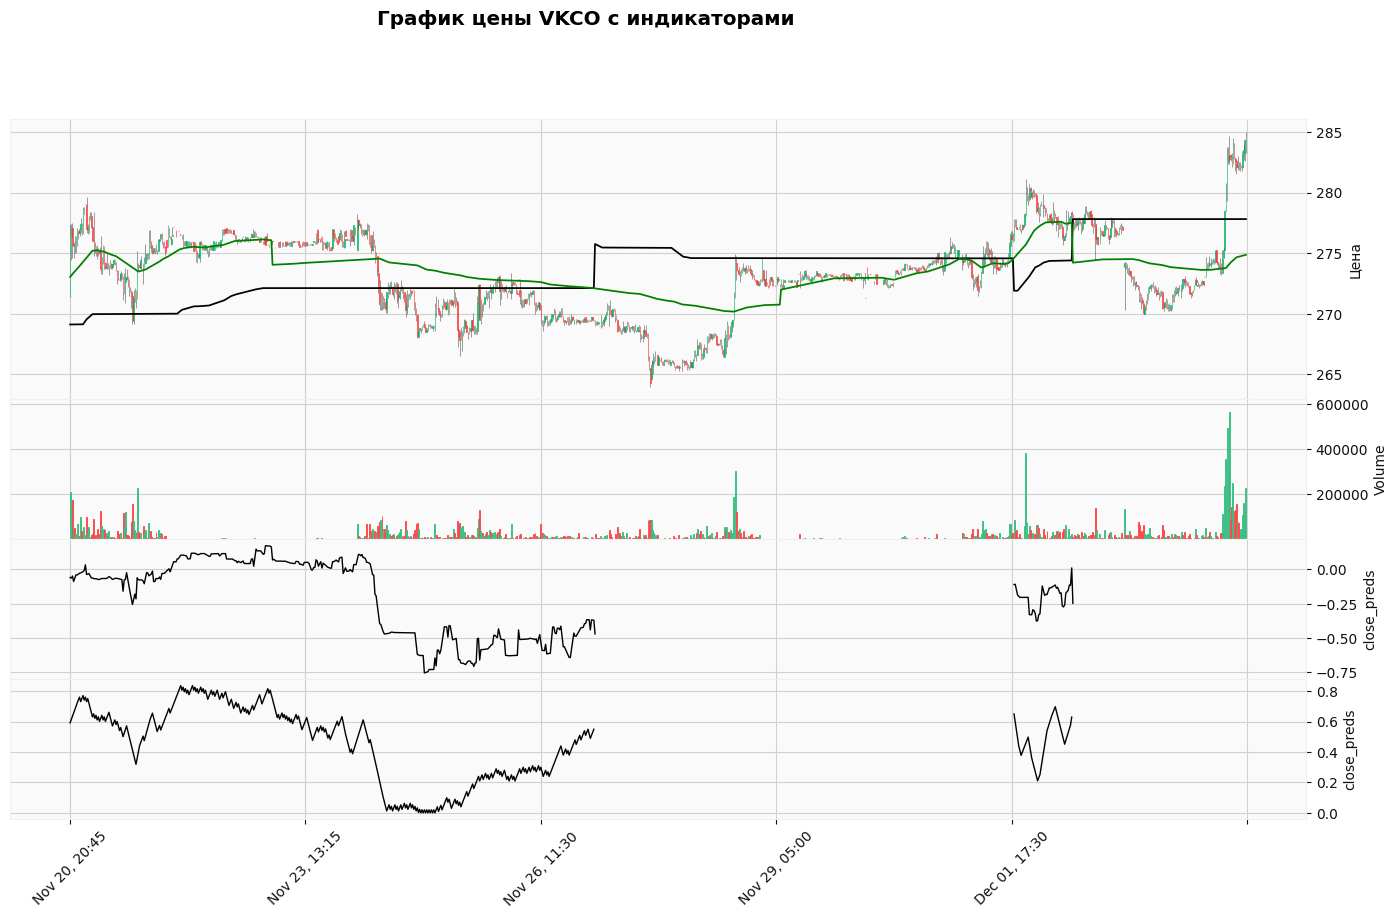

In [ ]:
plot_price_with_indicators_mplfinance1(df1.iloc[-1000:], ticker)

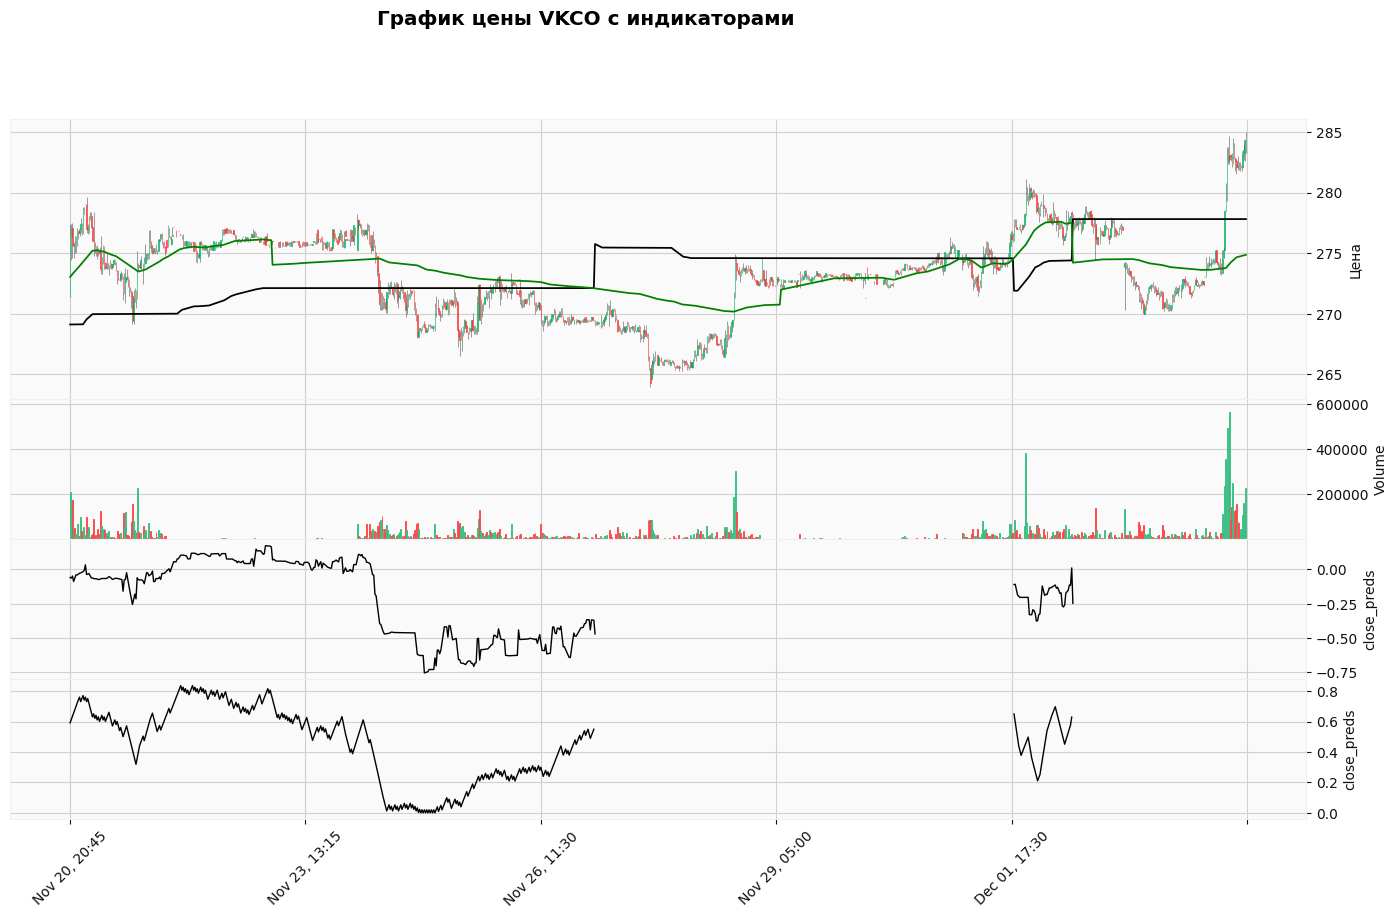

In [ ]:
plot_price_with_indicators_mplfinance1(df.iloc[-1000:], ticker)#, vline_time='08:00 24.11.2025')

##Модель Выхода

Рисуем → 50 свечей | VKCO - последний сегмент
Debug batch: len=50, batch_id=0


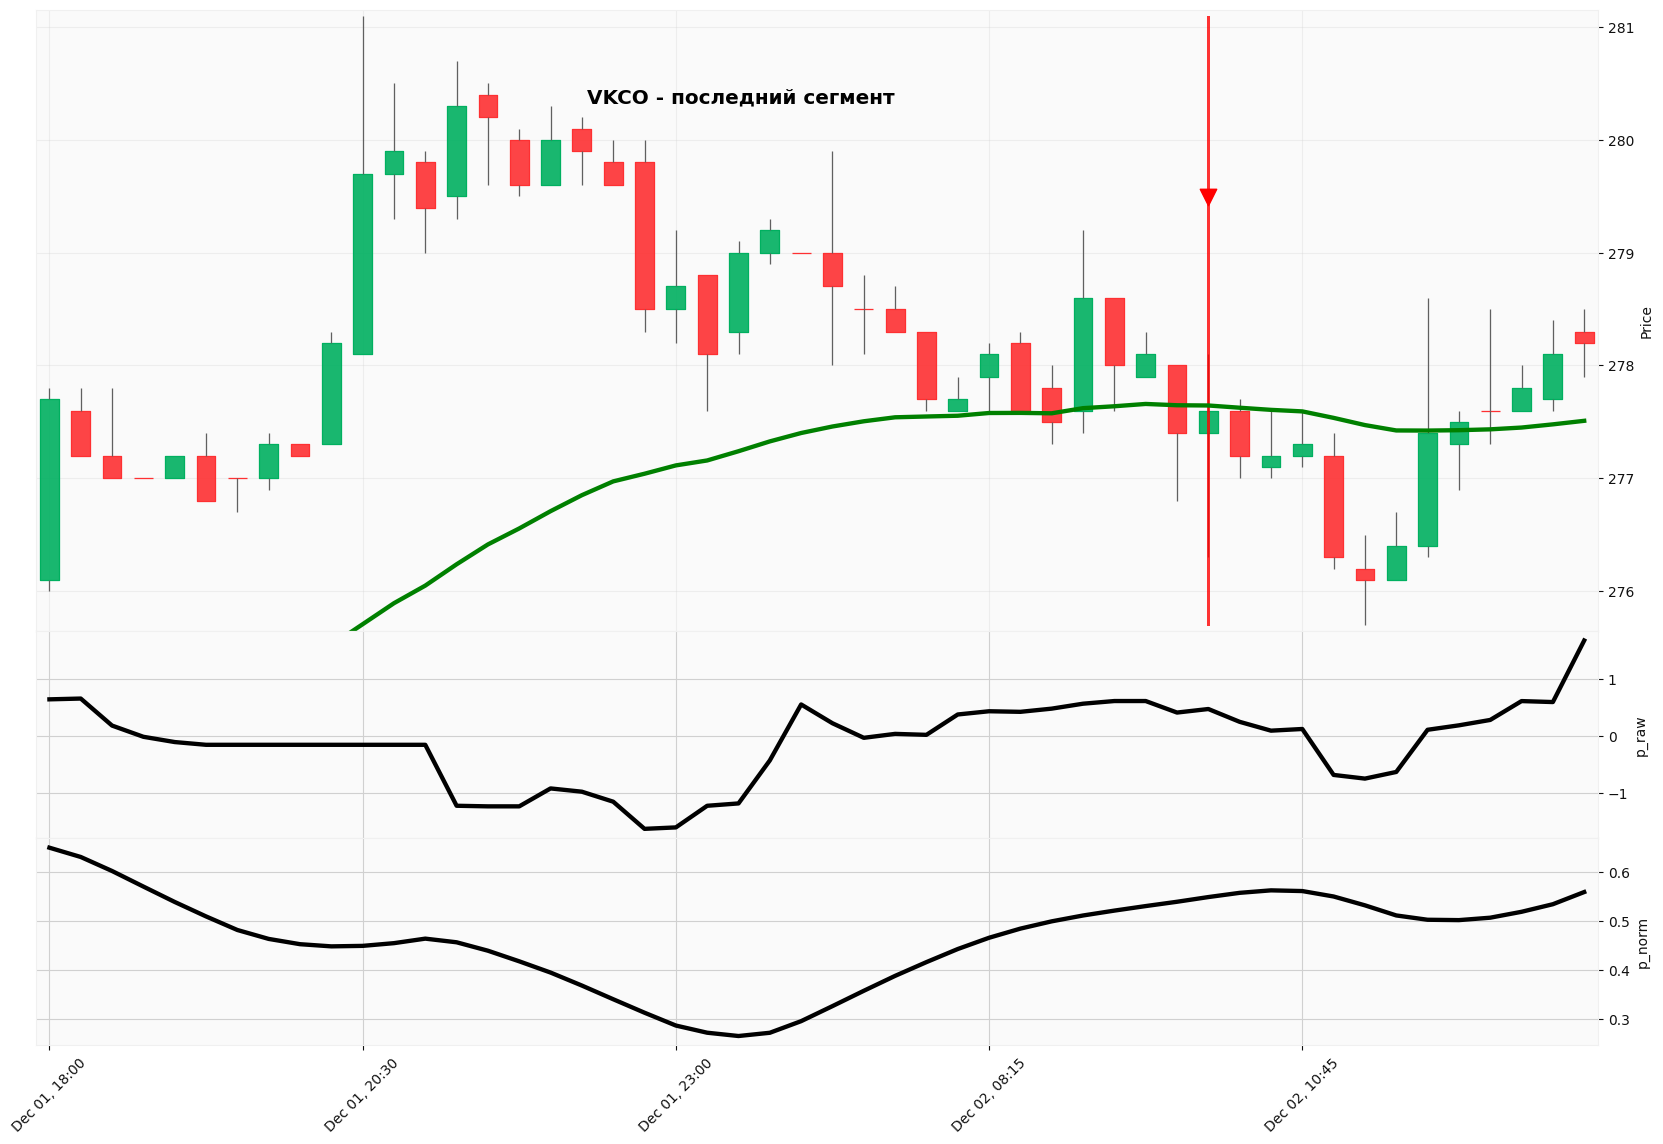

✓ Готово: candle, exit #37, t_exit=2025-12-02 10:00:00+00:00


In [ ]:
save_dir = 'C:/Users/aleksandrovva1/Desktop/data science/0-trade/t/fgdfg'
ticker = 'VKCO'
df = pd.DataFrame({
    'time': pd.to_datetime(time_last_kline_start[ticker], utc=True),
    'time_close': pd.to_datetime(time_last_kline_end[ticker], utc=True),
    'open':open_price[ticker],
    'high':high_price[ticker],
    'low':low_price[ticker],
    'close':close_price[ticker],
    'volume':volume[ticker],
    'ma':ma[ticker],
    'pmax':pmax[ticker],
    'preds':close_preds[ticker],
    'predictions_norm_fresh':close_preds_norm[ticker]
}
)
params_dict = out_model_params_main[ticker]  # как у вас раньше
df1 = plot_last_segment(df, params_dict, title=f"{ticker} - последний сегмент", save_path=None, ticker=ticker, show_current_open=False) #title=f"{ticker} - последний сегмент" #show_current_open=True

In [ ]:
save_dir = 'C:/Users/aleksandrovva1/Desktop/data science/0-trade/t/fgdfg'
ticker = 'VKCO'
df = pd.DataFrame({
    'time': pd.to_datetime(time_last_kline_start[ticker], utc=True),
    'time_close': pd.to_datetime(time_last_kline_end[ticker], utc=True),
    'open':open_price[ticker],
    'high':high_price[ticker],
    'low':low_price[ticker],
    'close':close_price[ticker],
    'volume':volume[ticker],
    'ma':ma[ticker],
    'pmax':pmax[ticker],
    'preds':close_preds[ticker],
    'predictions_norm_fresh':close_preds_norm[ticker]
}
)
params_dict = out_model_params_main[ticker]  # как у вас раньше
plot_last_segment_based_on_my_data(df, params_dict, title=f"{ticker} - последний сегмент", save_path=None)

##Проверка данных

In [18]:
import json
import pandas as pd
from datetime import datetime, timedelta
from tinkoff.invest import Client, CandleInterval, InstrumentStatus
import os

# ===================================================================
# НАСТРОЙКИ — ИЗМЕНА И ПУТИ
# ===================================================================
TICKER = "MGTSP"                     # ← тикер, который хотите проверить              # ← путь к папке с вашими данными
TOKEN = 't.bWjxPlU6vz77qoqS754OKy0QorLDaZP-CE091dhGl56v7GHrqgF-mQAdWaeRg2kDRJmmxzvaaOwKUTxW6dnOKg'   # ← ваш токен Tinkoff Invest API
DAYS = 450                          # сколько дней назад загрузить свежие свечи
INTERVAL = CandleInterval.CANDLE_INTERVAL_15_MIN   # ваш интервал (15-минутки)
TIMEZONE_OFFSET_HOURS = 3           # +3 часа от UTC → MSK
MAX_DAYS_PER_REQUEST = 14                        # ограничение API для 15-мин свечей
# ===================================================================


def get_figi_by_ticker(token: str, ticker: str) -> str:
    with Client(token) as client:
        resp = client.instruments.shares(instrument_status=InstrumentStatus.INSTRUMENT_STATUS_ALL)
        for instr in resp.instruments:
            if instr.ticker == ticker:
                return instr.figi
    raise ValueError(f"Тикер {ticker} не найден!")


def load_old_times(ticker: str, data_path: str) -> pd.DatetimeIndex:
    file_path = os.path.join(data_path, "back_data", "time_last_kline_start.txt")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Файл не найден: {file_path}")

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if ticker not in data:
        raise KeyError(f"Тикер {ticker} отсутствует в старых данных")

    iso_list = data[ticker]
    dt = pd.to_datetime(iso_list, utc=True).floor("T")
    dt = dt.drop_duplicates().sort_values()
    return pd.DatetimeIndex(dt)


def load_new_candles_chunked(token: str, figi: str, days: int) -> pd.DatetimeIndex:
    now = datetime.utcnow().replace(tzinfo=None)
    all_times = []

    for start_day in range(0, days, MAX_DAYS_PER_REQUEST):
        from_time = now - timedelta(days=start_day + MAX_DAYS_PER_REQUEST)
        to_time = now - timedelta(days=start_day)

        print(f"  Загрузка: {from_time.strftime('%Y-%m-%d')} → {to_time.strftime('%Y-%m-%d')}")

        with Client(token) as client:
            resp = client.market_data.get_candles(
                figi=figi,
                from_=from_time,
                to=to_time,
                interval=INTERVAL
            )
            for c in resp.candles:
                ts_utc = c.time
                ts_msk = ts_utc + timedelta(hours=TIMEZONE_OFFSET_HOURS)
                all_times.append(ts_msk.replace(second=0, microsecond=0))

        time.sleep(0.12)

    dt = pd.to_datetime(all_times, utc=True).floor("T")
    dt = dt.drop_duplicates().sort_values()
    return pd.DatetimeIndex(dt)


def analyze_ticker(ticker: str):
    print(f"\n{'='*70}")
    print(f"ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ ДЛЯ ТИКЕРА: {ticker}")
    print(f"{'='*70}")

    # 1. Старые данные
    old_times = load_old_times(ticker, DATA_PATH)
    print(f"Старые данные: {len(old_times)} уникальных свечей")

    # 2. FIGI + новые данные
    figi = get_figi_by_ticker(TOKEN, ticker)
    print(f"FIGI: {figi}")
    new_times = load_new_candles_chunked(TOKEN, figi, DAYS)
    print(f"Новые данные (за {DAYS} дней): {len(new_times)} уникальных свечей")

    # 3. Общий диапазон
    start = max(old_times.min(), new_times.min())
    end   = min(old_times.max(), new_times.max())
    old_range = old_times[(old_times >= start) & (old_times <= end)]
    new_range = new_times[(new_times >= start) & (new_times <= end)]

    # 4. Дубликаты
    dupes = old_times[old_times.duplicated(keep=False)]
    print(f"Дубликатов в старых данных: {len(dupes)}")

    # 5. Пропущенные / лишние
    missing = new_range.difference(old_range)
    extra   = old_range.difference(new_range)

    print(f"\nПропущено в старых (есть в новых): {len(missing)}")
    if len(missing):
        print("Примеры пропущенных:")
        print([t.strftime("%Y-%m-%d %H:%M") for t in missing[:20]])

    print(f"Лишние в старых (нет в новых): {len(extra)}")
    if len(extra):
        print("Примеры лишних:")
        print([t.strftime("%Y-%m-%d %H:%M") for t in extra[:20]])

    # 6. Разрывы (>15 минут)
    if len(old_range) > 1:
        diffs = old_range.to_series().diff().dropna()
        gaps = diffs[diffs > pd.Timedelta(minutes=15)]
        print(f"\nРазрывы в старых данных (>15 мин): {len(gaps)}")
        if len(gaps):
            # gaps.index — это время второй свечи в паре
            for gap_time in gaps.index[:10]:
                i = old_range.get_loc(gap_time)
                prev = old_range[i-1]
                curr = old_range[i]
                mins = int(gaps[gap_time].total_seconds() / 60)
                print(f"  {prev.strftime('%Y-%m-%d %H:%M')} → {curr.strftime('%Y-%m-%d %H:%M')} (разрыв {mins} мин)")
    else:
        print("\nРазрывов в старых данных: невозможно посчитать (менее 2 свечей)")

    # 7. Итог
    if len(missing) == 0 and len(extra) == 0 and (len(old_range) <= 1 or len(gaps) == 0):
        print(f"\n{ticker}: ДАННЫЕ ИДЕАЛЬНЫ — полное совпадение!")
    else:
        print(f"\n{ticker}: ЕСТЬ РАСХОЖДЕНИЯ — рекомендуется перезагрузить данные")


# ===================================================================
# ЗАПУСК
# ===================================================================
if __name__ == "__main__":
    analyze_ticker(TICKER)


ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ ДЛЯ ТИКЕРА: MGTSP
Старые данные: 4996 уникальных свечей
FIGI: BBG000PZ0833
  Загрузка: 2025-11-21 → 2025-12-05
  Загрузка: 2025-11-07 → 2025-11-21
  Загрузка: 2025-10-24 → 2025-11-07
  Загрузка: 2025-10-10 → 2025-10-24
  Загрузка: 2025-09-26 → 2025-10-10
  Загрузка: 2025-09-12 → 2025-09-26
  Загрузка: 2025-08-29 → 2025-09-12
  Загрузка: 2025-08-15 → 2025-08-29
  Загрузка: 2025-08-01 → 2025-08-15
  Загрузка: 2025-07-18 → 2025-08-01
  Загрузка: 2025-07-04 → 2025-07-18
  Загрузка: 2025-06-20 → 2025-07-04
  Загрузка: 2025-06-06 → 2025-06-20
  Загрузка: 2025-05-23 → 2025-06-06
  Загрузка: 2025-05-09 → 2025-05-23
  Загрузка: 2025-04-25 → 2025-05-09
  Загрузка: 2025-04-11 → 2025-04-25
  Загрузка: 2025-03-28 → 2025-04-11
  Загрузка: 2025-03-14 → 2025-03-28
  Загрузка: 2025-02-28 → 2025-03-14
  Загрузка: 2025-02-14 → 2025-02-28
  Загрузка: 2025-01-31 → 2025-02-14
  Загрузка: 2025-01-17 → 2025-01-31
  Загрузка: 2025-01-03 → 2025-01-17
  Загрузка: 2024-12-20 → 2025-01

##Проверка работоспособности

In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from typing import Dict, List
from joblib import Parallel, delayed
from collections import defaultdict, deque
import concurrent.futures

def calculate_target(df, threshold=3.0):
    # Проверка необходимых колонок
    required_columns = ['event_price', 'event_sell_price']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        raise ValueError(f"Отсутствуют необходимые колонки: {missing_cols}")

    # Копируем DataFrame чтобы не менять оригинал
    result_df = df.copy()

    # Рассчитываем процентное изменение
    result_df['price_change_pct'] = (
        (result_df['event_sell_price'] / result_df['event_price'] - 1) * 100
    )

    # Создаем целевой признак
    result_df['target'] = (result_df['price_change_pct'] >= threshold).astype(int)

    # Обработка случаев с отсутствующими данными
    result_df['target'] = result_df['target'].where(
        result_df[['event_price', 'event_sell_price']].notnull().all(axis=1),
        other=0
    )

    # Обработка случаев с нулевой ценой покупки (если такие есть)
    result_df['target'] = result_df['target'].where(
        result_df['event_price'] != 0,
        other=0
    )

    # Удаляем временную колонку
    result_df.drop('price_change_pct', axis=1, inplace=True)

    return result_df

class MachineLearningRSI:
    def __init__(self,
                 rsi_length=300,
                 use_smoothing=True,
                 smoothing_length=268,
                 smoothing_type='ALMA',
                 alma_sigma=6,
                 rsi_overbought=70,
                 rsi_oversold=30,
                 use_knn=True,
                 knn_neighbors=7,
                 knn_lookback=500,
                 knn_weight=0.6,
                 feature_count=5,
                 use_filter=True,
                 filter_method='Kalman',
                 filter_strength=0.7,
                 sma_length=20 + 7*24*4*3,
                 ema_length=21 + 7*24*4*3
                 ):

        # Базовые параметры
        self.rsi_length = rsi_length
        self.use_smoothing = use_smoothing
        self.smoothing_length = smoothing_length
        self.smoothing_type = smoothing_type
        self.alma_sigma = alma_sigma

        # Пороговые уровни
        self.rsi_overbought = rsi_overbought
        self.rsi_oversold = rsi_oversold

        # Параметры KNN
        self.use_knn = use_knn
        self.knn_neighbors = knn_neighbors
        self.knn_lookback = knn_lookback
        self.knn_weight = knn_weight
        self.feature_count = feature_count

        # Фильтрация
        self.use_filter = use_filter
        self.filter_method = filter_method
        self.filter_strength = filter_strength

        self.sma_length = sma_length
        self.ema_length = ema_length

    def calculate_rsi(self, close: pd.Series, length: int) -> pd.Series:
        """Расчет RSI через RMA аналогично PineScript ta.rsi"""
        delta = close.diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        avg_gain = gain.ewm(alpha=1/length, min_periods=length, adjust=False).mean()
        avg_loss = loss.ewm(alpha=1/length, min_periods=length, adjust=False).mean()
        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

    def smooth(self, series: pd.Series) -> pd.Series:
        """Корректный ALMA"""
        if self.smoothing_type == 'SMA':
            return series.rolling(self.smoothing_length).mean()
        elif self.smoothing_type == 'EMA':
            return series.ewm(span=self.smoothing_length, adjust=False).mean()
        elif self.smoothing_type == 'ALMA':
            m = self.smoothing_length
            offset = 0.85
            sigma = self.alma_sigma

            def alma(series):
                window = np.arange(m)
                weights = np.exp(-((window - offset * (m-1))**2) / (2*(sigma**2)))
                weights /= weights.sum()
                return np.convolve(series, weights, mode='valid')

            def alma_causal(series: pd.Series, length: int = 9, offset: float = 0.85, sigma: float = 6) -> pd.Series:
                """
                Казуальная реализация ALMA (Arnaud Legoux Moving Average)
                Использует только прошлые и текущие значения, без lookahead bias.
                """
                if length > len(series):
                    return pd.Series(np.nan, index=series.index)

                # Предвычисление весов ALMA
                window = np.arange(length)
                m = offset * (length - 1)
                s = length / sigma
                weights = np.exp(-((window - m) ** 2) / (2 * s ** 2))
                weights /= weights.sum()

                # Применяем ALMA казуально (rolling + dot product)
                alma_vals = []
                for i in range(length - 1, len(series)):
                    window_data = series.iloc[i - length + 1:i + 1]
                    if window_data.isnull().any():
                        alma_vals.append(np.nan)
                    else:
                        alma_vals.append(np.dot(weights, window_data.values))

                # Паддинг NaN в начало, чтобы сохранить индекс
                alma_series = pd.Series([np.nan] * (length - 1) + alma_vals, index=series.index)

                return alma_series

            alma_series = alma_causal(series.fillna(method='ffill'), m, offset, sigma)#, index=series.index[pad:-pad])
            #alma_series = alma_series.reindex(series.index, method='nearest')
            return alma_series
        else:
            return series

    def feature_extraction(self, close: pd.Series, rsi: pd.Series) -> pd.DataFrame:
        """Извлечение признаков для KNN"""
        features = pd.DataFrame(index=close.index)
        features['rsi'] = self.normalize(rsi, self.knn_lookback)

        if self.feature_count >= 2:
            features['momentum_rsi'] = self.normalize(rsi.diff(3), self.knn_lookback)
        if self.feature_count >= 3:
            features['volatility_rsi'] = self.normalize(rsi.rolling(10).std(), self.knn_lookback)
        if self.feature_count >= 4:
            features['slope_rsi'] = self.normalize(self.get_slope(rsi, 5), self.knn_lookback)
        if self.feature_count >= 5:
            features['momentum_price'] = self.normalize(close.diff(5), self.knn_lookback)

        return features.dropna()

    def normalize(self, series: pd.Series, period: int) -> pd.Series:
        """Мин-макс нормализация"""
        min_val = series.rolling(period).min()
        max_val = series.rolling(period).max()
        norm = (series - min_val) / (max_val - min_val)
        return norm.clip(0, 1)

    def get_slope(self, series: pd.Series, window: int) -> pd.Series:
        """Расчет наклона линейной регрессии"""
        idx = np.arange(window)
        def linreg(x):
            A = np.vstack([idx, np.ones(len(idx))]).T
            m, c = np.linalg.lstsq(A, x, rcond=None)[0]
            return m
        return series.rolling(window).apply(linreg, raw=True)

    def apply_knn(self, features: pd.DataFrame, rsi: pd.Series) -> pd.Series:
        """
        Оптимизированная, но идентичная оригиналу версия KNN.
        Сохраняет точную математику оригинального apply_knn_b с ускорением через BallTree.
        """
        # Сохраняем структуру как в оригинале
        full_index = rsi.index
        common_index = features.index.intersection(rsi.index)
        features = features.loc[common_index]
        rsi = rsi.loc[common_index]

        enhanced_rsi = pd.Series(index=full_index, data=np.nan)
        enhanced_rsi.loc[rsi.index] = rsi

        if len(features) < self.knn_lookback:
            return enhanced_rsi

        feature_array = features.values
        rsi_array = rsi.values

        # Основное изменение: BallTree строится на скользящем окне
        for t in range(self.knn_lookback, len(feature_array)):
            window_start = t - self.knn_lookback
            window_end = t
            X_window = feature_array[window_start:window_end]
            y_window = rsi_array[window_start:window_end]

            # Строим дерево только на текущем окне
            tree = BallTree(X_window, metric='euclidean')
            distances, indices = tree.query(feature_array[t].reshape(1, -1),
                                          k=self.knn_neighbors)

            # Точное воспроизведение оригинальной логики взвешивания
            weights = np.where(distances[0] < 1e-6, 1.0, 1.0 / distances[0])
            prediction = np.average(y_window[indices[0]], weights=weights)

            idx = common_index[t]
            enhanced_rsi.loc[idx] = (1 - self.knn_weight) * rsi.loc[idx] + self.knn_weight * prediction

        return enhanced_rsi

    def kalman_filter(self, series: pd.Series) -> pd.Series:
        """Калман-фильтр с параметрами ближе к PineScript"""
        n = len(series)
        xhat = np.full(n, np.nan)
        P = np.zeros(n)
        R = self.filter_strength * 0.1  # Очень маленький measurement noise
        Q = self.filter_strength * 0.01  # Очень маленький process noise

        first_valid_idx = series.first_valid_index()
        if first_valid_idx is None:
            return pd.Series(xhat, index=series.index)

        first_idx = series.index.get_loc(first_valid_idx)
        xhat[first_idx] = series.iloc[first_idx]
        P[first_idx] = 1.0

        for k in range(first_idx + 1, n):
            if np.isnan(series.iloc[k]):
                xhat[k] = xhat[k - 1]
                P[k] = P[k - 1] + Q
            else:
                xhatminus = xhat[k-1]
                Pminus = P[k-1] + Q
                K = Pminus / (Pminus + R)
                xhat[k] = xhatminus + K * (series.iloc[k] - xhatminus)
                P[k] = (1 - K) * Pminus

        return pd.Series(xhat, index=series.index)

    def filter_series(self, series: pd.Series) -> pd.Series:
        """Применение фильтрации к финальному RSI"""
        if self.filter_method == 'None':
            return series
        elif self.filter_method == 'Kalman':
            return self.kalman_filter(series)
        elif self.filter_method == 'DoubleEMA':
            ema1 = series.ewm(span=int(self.filter_strength * 10)).mean()
            ema2 = ema1.ewm(span=int(self.filter_strength * 5)).mean()
            return ema2
        elif self.filter_method == 'ALMA':
            return self.smooth(series)
        else:
            return series

    def week_level(self, close):
        sma_length = self.sma_length
        ema_length = self.ema_length

        # Вычисление 20-недельной SMA
        SMA_20w = close.rolling(window=sma_length, min_periods=1).mean()

        # Вычисление 21-недельной EMA
        MA_21w = close.ewm(span=ema_length, adjust=False).mean()

        return SMA_20w, MA_21w


    def fit(self, close: pd.Series) -> pd.Series:
        """Основная функция расчёта"""
        rsi = self.calculate_rsi(close, self.rsi_length)
        if self.use_smoothing:
            rsi = self.smooth(rsi)
        if self.use_knn:
            features = self.feature_extraction(close, rsi)

            rsi = self.apply_knn(features, rsi)

        if self.use_filter:
            rsi = self.filter_series(rsi)

        sma, ma = self.week_level(close)

        return rsi.clip(0, 100), sma, ma


class TinkoffHistoricalDataCollector:
    def __init__(self):
        self.sma_state = {}

    def generateVar(self, high_array, low_array, moving_average_length=10):
        valpha = 2 / (moving_average_length + 1)
        hl2 = (high_array + low_array) / 2

        before_val = hl2[0] if len(hl2) > 0 else 0

        vud1 = []
        vdd1 = []
        for current_hl2 in hl2:
            if current_hl2 > before_val:
                vud1.append(current_hl2 - before_val)
                vdd1.append(0)
            elif current_hl2 < before_val:
                vdd1.append(before_val - current_hl2)
                vud1.append(0)
            else:
                vud1.append(0)
                vdd1.append(0)
            before_val = current_hl2

        def calculate_window_sums(arr, window_size=9):
          return [sum(arr[max(0, i - window_size + 1):i+1]) for i in range(len(arr))]

        vUD = calculate_window_sums(vud1, 9)
        vDD = calculate_window_sums(vdd1, 9)

        vUD_ar = np.array(vUD)
        vDD_ar = np.array(vDD)

        epsilon = 1e-10
        with np.errstate(divide='ignore', invalid='ignore'):
            vCMO = np.divide(vUD_ar - vDD_ar, vUD_ar + vDD_ar + epsilon)

        vCMO = np.nan_to_num(vCMO, nan=0.0)

        var = []
        var_before = 0.0
        for i in range(len(hl2)):
            if i < len(vCMO):
                cmo = abs(vCMO[i])
                var_current = (valpha * cmo * hl2[i]) + (1 - valpha * cmo) * var_before
            else:
                var_current = var_before
            var.append(var_current)
            var_before = var_current

        return np.array(var)

    def generateAma(self, high_array, low_array, close_array, atr_period=14, min_period=5, max_period=50):
        """
        Генерация адаптивного скользящего среднего на основе волатильности.

        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param close_array: Массив значений close.
        :param atr_period: Период для расчета ATR.
        :param min_period: Минимальный период скользящего среднего.
        :param max_period: Максимальный период скользящего среднего.
        :return: Массив значений адаптивного скользящего среднего.
        """
        # Рассчитываем ATR
        atr = self._calculate_atr(high_array, low_array, close_array, atr_period)

        # Нормализуем ATR для использования в качестве коэффициента
        normalized_atr = (atr - np.min(atr)) / (np.max(atr) - np.min(atr) + 1e-10)

        # Рассчитываем динамический период
        dynamic_period = min_period + (max_period - min_period) * normalized_atr

        # Рассчитываем адаптивное скользящее среднее (гибрид SMA и EMA)
        adaptive_ma = np.zeros_like(close_array)
        for i in range(len(close_array)):
            if i < int(dynamic_period[i]):
                adaptive_ma[i] = np.mean(close_array[:i+1])  # SMA для начальных значений
            else:
                period = int(dynamic_period[i])
                alpha = 2 / (period + 1)
                adaptive_ma[i] = alpha * close_array[i] + (1 - alpha) * adaptive_ma[i-1]  # EMA

        return adaptive_ma

    def _calculate_atr(self, high_array, low_array, close_array, period=14):
        """
        Рассчитывает Average True Range (ATR).

        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param close_array: Массив значений close.
        :param period: Период для расчета ATR.
        :return: Массив значений ATR.
        """
        tr = np.zeros_like(high_array)
        tr[0] = high_array[0] - low_array[0]

        for i in range(1, len(high_array)):
            hl = high_array[i] - low_array[i]
            hc = abs(high_array[i] - close_array[i-1])
            lc = abs(low_array[i] - close_array[i-1])
            tr[i] = max(hl, hc, lc)

        atr = np.zeros_like(tr)
        atr[period-1] = np.mean(tr[:period])

        for i in range(period, len(tr)):
            atr[i] = (atr[i-1] * (period-1) + tr[i]) / period

        return atr

    def generateAtr(self, high_array, low_array, close_array, period=14):

        # Рассчитываем True Range (TR)
        tr1 = high_array - low_array
        tr2 = np.abs(high_array - np.roll(close_array, 1))
        tr3 = np.abs(low_array - np.roll(close_array, 1))

        tr = np.maximum(tr1, np.maximum(tr2, tr3))

        # Рассчитываем ATR
        atr = np.zeros_like(tr)
        atr[period - 1] = np.mean(tr[:period])

        for i in range(period, len(tr)):
            atr[i] = (atr[i - 1] * (period - 1) + tr[i]) / period

        return atr

    def generateSma(self, high_array, low_array, window=10):
        """
        Генерация Simple Moving Average (SMA).

        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param window: Период SMA.
        :return: Массив значений SMA.
        """
        hl2 = (high_array + low_array) * 0.5

        if window <= 1:
            return hl2

        # Создаем массив для результатов с NaN
        sma = np.full_like(hl2, np.nan)

        # Рассчитываем кумулятивную сумму
        cumsum = np.cumsum(hl2)

        # Создаем сдвинутый кумулятивный массив
        shifted_cumsum = np.zeros_like(cumsum)
        shifted_cumsum[window:] = cumsum[:-window]

        # Вычисляем SMA для валидных периодов
        valid = slice(window - 1, None)
        sma[valid] = (cumsum[valid] - shifted_cumsum[valid]) / window

        return sma

    def generatePMax(self, var_array, close_array, high_array, low_array, atr_period, atr_multiplier):
        """
        Генерация PMax (Profit Maximizer).

        :param var_array: Массив значений скользящего среднего.
        :param close_array: Массив значений close.
        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param atr_period: Период для расчета ATR.
        :param atr_multiplier: Множитель ATR.
        :return: Массив значений PMax.
        """
        try:
            atr = self.generateAtr(high_array, low_array, close_array, period=atr_period)
        except Exception as exp:
            print('exception in atr:', str(exp), flush=True)
            return []

        previous_final_upperband = 0
        previous_final_lowerband = 0
        final_upperband = 0
        final_lowerband = 0
        previous_var = 0
        previous_pmax = 0
        pmax = []
        pmaxc = 0

        for i in range(0, len(close_array)):
            if np.isnan(close_array[i]):
                pass
            else:
                atrc = atr[i]
                varc = var_array[i]

                if math.isnan(atrc):
                    atrc = 0

                basic_upperband = varc + atr_multiplier * atrc
                basic_lowerband = varc - atr_multiplier * atrc

                if basic_upperband < previous_final_upperband or previous_var > previous_final_upperband:
                    final_upperband = basic_upperband
                else:
                    final_upperband = previous_final_upperband

                if basic_lowerband > previous_final_lowerband or previous_var < previous_final_lowerband:
                    final_lowerband = basic_lowerband
                else:
                    final_lowerband = previous_final_lowerband

                if previous_pmax == previous_final_upperband and varc <= final_upperband:
                    pmaxc = final_upperband
                else:
                    if previous_pmax == previous_final_upperband and varc >= final_upperband:
                        pmaxc = final_lowerband
                    else:
                        if previous_pmax == previous_final_lowerband and varc >= final_lowerband:
                            pmaxc = final_lowerband
                        elif previous_pmax == previous_final_lowerband and varc <= final_lowerband:
                            pmaxc = final_upperband

                pmax.append(pmaxc)

                previous_var = varc

                previous_final_upperband = final_upperband

                previous_final_lowerband = final_lowerband

                previous_pmax = pmaxc

        return pmax

    def generatePMax_new(
        self,
        var_array: np.ndarray,
        close_array: np.ndarray,
        high_array: np.ndarray,
        low_array: np.ndarray,
        atr_period: int,
        atr_multiplier: float,
        exit_multiplier: float = None,
        band_smooth_factor: float = 0.2,
        hysteresis_thresh: float = 0.0
    ) -> np.ndarray:
        """
        VAR-based PMax with:
          • entry ATR-multiplier = atr_multiplier
          • exit ATR-multiplier  = exit_multiplier (если None, берём atr_multiplier)
          • сглаживание band    = EMA final_upper/lower с alpha = band_smooth_factor
          • переключение состояния по пробою close, а не var
          • опциональный hysteresis_thresh:
            требуется пробой глубже exit_band ± hysteresis_thresh * ATR.
        """
        # 1. Считаем ATR
        atr = self.generateAtr(high_array, low_array, close_array, period=atr_period)

        # 2. Задаём exit-множитель и массивы
        if exit_multiplier is None:
            exit_multiplier = atr_multiplier

        n = len(var_array)
        final_upper = np.zeros(n, dtype=float)
        final_lower = np.zeros(n, dtype=float)
        pmax       = np.zeros(n, dtype=float)

        # Начальное состояние: берём var[0] и устанавливаем полосы
        v0 = var_array[0]
        a0 = atr[0]
        fu = v0 + atr_multiplier * a0
        fl = v0 - atr_multiplier * a0
        # EMA-инициализация
        final_upper[0] = fu
        final_lower[0] = fl
        # старт с нижней полосы, чтобы при росте первый сигнал был на покупку
        p = fl
        pmax[0] = p

        # 3. Основной цикл
        for i in range(1, n):
            v = var_array[i]
            a = atr[i]
            # базовые полосы
            bu = v + atr_multiplier * a
            bl = v - atr_multiplier * a
            eu = v + exit_multiplier  * a
            el = v - exit_multiplier  * a

            # Этап сглаживания полос (EMA):
            # final_upper = α * bu + (1-α) * prev_final_upper
            fu = band_smooth_factor * bu + (1 - band_smooth_factor) * final_upper[i-1]
            fl = band_smooth_factor * bl + (1 - band_smooth_factor) * final_lower[i-1]
            final_upper[i] = fu
            final_lower[i] = fl

            # 4. Определяем, пробит ли exit band ценой:
            #    для шорт-режима (мы в шорте): price > eu + hysteresis
            #    для лонг-режима  (мы в лонге):  price < el - hysteresis
            price = close_array[i]
            his = hysteresis_thresh * a
            if p == final_upper[i-1]:
                # сейчас «сидим» на верхней полосе → лонг-позиция
                # выходим, как только price закрылся ниже (el - his)
                exit_condition = price < (el - his)
                if exit_condition:
                    p = fl  # переключаемся на «шорт-уровень»
            else:
                # сейчас «сидим» на нижней полосе → шорт-позиция
                # выходим, как только price закрылся выше (eu + his)
                exit_condition = price > (eu + his)
                if exit_condition:
                    p = fu  # переключаемся на «лонг-уровень»

            pmax[i] = p

        return pmax

    def generate_signals(self, df, moving_average_length=10, atr_period=10, atr_multiplier=3, average_type='SMA',
                        ama_params=None):
        """
        Генерация сигналов на основе SMA или AMA.

        :param df: DataFrame с данными.
        :param moving_average_length: Период скользящего среднего.
        :param atr_period: Период ATR.
        :param atr_multiplier: Множитель ATR.
        :param average_type: Тип скользящего среднего ('SMA' или 'AMA').
        :param ama_params: Параметры для AMA (если используется).
        :return: DataFrame с добавленными сигналами.
        """
        high_array = df["high"].values
        low_array = df["low"].values
        close_array = df["close"].values
        df = df.copy()

        if average_type == 'SMA':
            ma_arr = self.generateSma(high_array, low_array, moving_average_length)
        elif average_type == 'VAR':
            ma_arr = self.generateVar(high_array, low_array, moving_average_length)
        elif average_type == 'AMA':
            if ama_params is None:
                raise ValueError("Для AMA необходимо указать параметры ama_params.")
            ma_arr = self.generateAma(high_array, low_array, close_array, **ama_params)
        else:
            raise ValueError("Неподдерживаемый тип скользящего среднего.")

        pmax = self.generatePMax(ma_arr, close_array, high_array, low_array, atr_period, atr_multiplier)
        df["pmax"] = pmax
        df["ma"] = ma_arr
        df["buy_signal"] = (df["ma"] > df["pmax"]) & (df["ma"].shift(1) < df["pmax"].shift(1))
        df["sell_signal"] = (df["ma"] < df["pmax"]) & (df["ma"].shift(1) > df["pmax"].shift(1))

        return df

def prepare_regime_params(optuna_params):
    """
    Преобразует параметры из формата Optuna в два словаря: базовые параметры режимов и параметры расчета.

    Args:
        optuna_params (dict): Словарь с параметрами из Optuna

    Returns:
        dict: Словарь с двумя ключами: 'base_params' (параметры режимов) и 'calc_params' (остальные параметры)
    """
    # Инициализируем словари для базовых параметров и параметров расчета
    start_params = {}
    base_params = {}
    calc_params = {}

    # Сначала обрабатываем параметры режимов (0-4)

    start_params['moving_average_length'] = optuna_params.get('moving_average_length', 14)
    start_params['atr_period'] = optuna_params.get('atr_period', 10)
    for regime in range(5):
        regime_key = f'regime_{regime}_'
        regime_params = {}

        # Основные параметры режима
        regime_params['average_type'] = optuna_params.get(f'{regime_key}average_type', 'SMA')
        regime_params['moving_average_length'] = optuna_params.get(f'{regime_key}ma_length', 50)
        regime_params['atr_period'] = optuna_params.get(f'{regime_key}atr_period', 14)
        regime_params['atr_multiplier'] = optuna_params.get(f'{regime_key}atr_multiplier', 3.0)

        # Параметры AMA, если они есть
        ama_atr_period = optuna_params.get(f'{regime_key}ama_atr_period')
        ama_min_period = optuna_params.get(f'{regime_key}ama_min_period')
        ama_max_period = optuna_params.get(f'{regime_key}ama_max_period')

        if regime_params['average_type'] == 'AMA' and all(p is not None for p in [ama_atr_period, ama_min_period, ama_max_period]):
            regime_params['ama_params'] = {
                'atr_period': int(ama_atr_period),
                'min_period': int(ama_min_period),
                'max_period': int(ama_max_period)
            }

        base_params[regime] = regime_params

    # Теперь собираем все остальные параметры в calc_params
    other_params = [
        'rsi_length', 'use_smoothing', 'smoothing_length', 'smoothing_type',
        'alma_sigma', 'rsi_overbought', 'rsi_oversold', 'use_knn',
        'knn_neighbors', 'knn_lookback', 'knn_weight', 'feature_count',
        'use_filter', 'filter_method', 'filter_strength', 'sma_length',
        'ema_length', 'rsi_helbuth'
    ]

    for param in other_params:
        if param in optuna_params:
            calc_params[param] = optuna_params[param]

    return {
        'start_params': start_params,
        'base_params': base_params,
        'calc_params': calc_params
    }


class AdaptiveTradingSystem:
    def __init__(self, regime_params: Dict[int, dict]):
        self.regime_params = regime_params

    # ──────────────────────────────────────────────────────────────

    def generate_adaptive_signals(
        self,
        df: pd.DataFrame,
        regime_series: pd.Series
    ) -> pd.DataFrame:

        df      = df.reset_index(drop=True)
        regimes = regime_series.reset_index(drop=True).astype(int).values
        n       = len(df)
        high    = df['high'].values
        low     = df['low'].values
        close   = df['close'].values

        # 0) создаём «коллектор» – единая точка доступа ко всем MA/ATR
        collector = TinkoffHistoricalDataCollector()

        # ────────────────────────────── 1. PRECOMPUTE  ────────────
        ma_cache:  Dict[int, np.ndarray] = {}
        atr_cache: Dict[int, np.ndarray] = {}

        for regime, p in self.regime_params.items():
            atype = p['average_type']
            L     = p['moving_average_length']
            P     = p['atr_period']

            # ---- MA ------------------------------------------------
            if atype == 'SMA':
                # готовая реализация из collector
                ma = collector.generateSma(high, low, window=L)

            elif atype == 'VAR':
                ma = collector.generateVar(high, low, moving_average_length=L)

            elif atype == 'EMA':
                ma = collector.generateEma(high, low, moving_average_length=L)

            elif atype == 'AMA':
                ama_pars = p.get('ama_params',                   # защита от None
                                 {'atr_period': 14,
                                  'min_period': 5,
                                  'max_period': 50})

                ma = collector.generateAma(
                    high, low, close,
                    atr_period=ama_pars['atr_period'],
                    min_period=ama_pars['min_period'],
                    max_period=ama_pars['max_period']
                )
            else:
                raise ValueError(f"Unknown MA type {atype!r}")

            ma_cache[regime] = ma

            # ---- ATR ----------------------------------------------
            atr_cache[regime] = collector.generateAtr(
                high, low, close, period=P
            )

        # ────────────────────────────── 2. МЭРДЖ ПО РЕЖИМАМ ───────
        var_all = np.empty(n, dtype=np.float64)
        atr_all = np.empty(n, dtype=np.float64)
        mul_all = np.empty(n, dtype=np.float64)

        for regime, p in self.regime_params.items():
            mask          = (regimes == regime)
            var_all[mask] = ma_cache[regime][mask]
            atr_all[mask] = atr_cache[regime][mask]
            mul_all[mask] = p['atr_multiplier']

        # Заполняем возможные NaN в начале серии MA одной первой валидной точкой
        if np.isnan(var_all[0]):
            first_valid = var_all[~np.isnan(var_all)][0]
            var_all[np.isnan(var_all)] = first_valid

        # ────────────────────────────── 3. PMax STATE MACHINE ─────
        pmax_all = np.zeros(n, dtype=float)
        for regime, p in self.regime_params.items():
            mask = (regimes == regime)
            if not mask.any():
                continue
            var_r = ma_cache[regime][mask]
            # atr_r берём из atr_cache
            atr_r = atr_cache[regime][mask]
            # close_r подтягиваем из общего массива
            close_r = close[mask]
            # генерим pmax для этого regime
            pmax_r = collector.generatePMax_new(
                var_array      = var_r,
                close_array    = close_r,
                high_array     = high[mask],
                low_array      = low[mask],
                atr_period     = p['atr_period'],
                atr_multiplier = p['atr_multiplier'],
                exit_multiplier= p['atr_multiplier'] * 1.5,  # можно варьировать на вход/выход
                band_smooth_factor = 0.12,
                hysteresis_thresh  = 0.3  # 10% ATR доп. «гистерезиса»
            )
            pmax_all[mask] = pmax_r

        # затем собираем buy/sell на основе pmax_all и var_all, как раньше:
        v_prev = np.concatenate(([var_all[0]], var_all[:-1]))
        p_prev = np.concatenate(([pmax_all[0]], pmax_all[:-1]))
        buy  = (v_prev < p_prev) & (var_all > pmax_all)
        sell = (v_prev > p_prev) & (var_all < pmax_all)

        # ────────────────────────────── 5. ВЫХОДНОЙ DataFrame ──────
        out = df.copy()
        out['ma']   = var_all
        out['pmax'] = pmax_all
        out['buy_signal']    = buy
        out['sell_signal']   = sell
        out['regime']        = regimes

        return out


    def generate_adaptive_signals1(
        self,
        df: pd.DataFrame,
        regime_series: pd.Series
    ) -> pd.DataFrame:

        df      = df.reset_index(drop=True)
        regimes = regime_series.reset_index(drop=True).astype(int).values
        n       = len(df)
        high    = df['high'].values
        low     = df['low'].values
        close   = df['close'].values

        # 0) создаём «коллектор» – единая точка доступа ко всем MA/ATR
        collector = TinkoffHistoricalDataCollector()

        # ────────────────────────────── 1. PRECOMPUTE  ────────────
        ma_cache:  Dict[int, np.ndarray] = {}
        atr_cache: Dict[int, np.ndarray] = {}

        for regime, p in self.regime_params.items():
            atype = p['average_type']
            L     = p['moving_average_length']
            P     = p['atr_period']

            # ---- MA ------------------------------------------------
            if atype == 'SMA':
                # готовая реализация из collector
                ma = collector.generateSma(high, low, window=L)

            elif atype == 'VAR':
                ma = collector.generateVar(high, low, moving_average_length=L)

            elif atype == 'EMA':
                ma = collector.generateEma(high, low, moving_average_length=L)

            elif atype == 'AMA':
                ama_pars = p.get('ama_params',                   # защита от None
                                 {'atr_period': 14,
                                  'min_period': 5,
                                  'max_period': 50})

                ma = collector.generateAma(
                    high, low, close,
                    atr_period=ama_pars['atr_period'],
                    min_period=ama_pars['min_period'],
                    max_period=ama_pars['max_period']
                )
            else:
                raise ValueError(f"Unknown MA type {atype!r}")

            ma_cache[regime] = ma

            # ---- ATR ----------------------------------------------
            atr_cache[regime] = collector.generateAtr(
                high, low, close, period=P
            )

        # ────────────────────────────── 2. МЭРДЖ ПО РЕЖИМАМ ───────
        var_all = np.empty(n, dtype=np.float64)
        atr_all = np.empty(n, dtype=np.float64)
        mul_all = np.empty(n, dtype=np.float64)

        for regime, p in self.regime_params.items():
            mask          = (regimes == regime)
            var_all[mask] = ma_cache[regime][mask]
            atr_all[mask] = atr_cache[regime][mask]
            mul_all[mask] = p['atr_multiplier']

        # Заполняем возможные NaN в начале серии MA одной первой валидной точкой
        if np.isnan(var_all[0]):
            first_valid = var_all[~np.isnan(var_all)][0]
            var_all[np.isnan(var_all)] = first_valid

        # ────────────────────────────── 3. PMax STATE MACHINE ─────
        pmax_all = np.empty(n, dtype=np.float64)

        prev_var = var_all[0]
        prev_atr = atr_all[0]
        prev_mul = mul_all[0]

        prev_fu = prev_var + prev_mul * prev_atr
        prev_fl = prev_var - prev_mul * prev_atr
        prev_p  = prev_fl                                # стартовое состояние
        pmax_all[0] = prev_p

        for i in range(1, n):
            v   = var_all[i]
            a   = atr_all[i]
            m   = mul_all[i]

            bu  = v + m * a
            bl  = v - m * a

            fu = bu if (bu < prev_fu or prev_var > prev_fu) else prev_fu
            fl = bl if (bl > prev_fl or prev_var < prev_fl) else prev_fl

            if prev_p == prev_fu:
                p = fu if v <= fu else fl
            else:  # prev_p == prev_fl
                p = fl if v >= fl else fu

            pmax_all[i] = p

            prev_var, prev_fu, prev_fl, prev_p = v, fu, fl, p

        # ────────────────────────────── 4. СИГНАЛЫ ────────────────
        v_prev = np.concatenate(([var_all[0]], var_all[:-1]))
        p_prev = np.concatenate(([pmax_all[0]], pmax_all[:-1]))

        buy  = (v_prev < p_prev) & (var_all > pmax_all)
        sell = (v_prev > p_prev) & (var_all < pmax_all)

        # ────────────────────────────── 5. ВЫХОДНОЙ DataFrame ──────
        out = df.copy()
        out['ma']   = var_all
        out['pmax'] = pmax_all
        out['buy_signal']    = buy
        out['sell_signal']   = sell
        out['regime']        = regimes

        return out
def extract_features(df: pd.DataFrame, window: int = 126):
    """
    Вычисляет устойчивые признаки для кластеризации рыночных режимов.
    """

    def calculate_macd(df, macd_fast_periods=[12], macd_slow_periods=[26], macd_signal_periods=[9]):
        """
        Быстрый расчет нормализованного MACD с использованием векторизованных операций
        """
        close = df['close']

        # Создаем множества для уникальных периодов
        unique_fast = set(macd_fast_periods)
        unique_slow = set(macd_slow_periods)


        # Предварительно вычисляем все необходимые EMA и скользящие средние
        ema_cache = {}
        rolling_cache = {}

        # Кешируем быстрые EMA
        for fp in unique_fast:
            ema_cache[f'ema_{fp}'] = close.ewm(span=fp, adjust=False).mean()

        # Кешируем медленные EMA и скользящие средние
        for sp in unique_slow:
            ema_cache[f'ema_{sp}'] = close.ewm(span=sp, adjust=False).mean()
            rolling_cache[f'rolling_{sp}'] = close.rolling(window=sp).mean()

        # Основной цикл вычислений
        for fp in macd_fast_periods:
            ema_fast = ema_cache[f'ema_{fp}']
            for sp in macd_slow_periods:
                ema_slow = ema_cache[f'ema_{sp}']
                rolling_mean = rolling_cache[f'rolling_{sp}']

                # Вычисляем MACD и нормализацию
                macd = ema_fast - ema_slow
                macd_norm = macd / rolling_mean

                # Сохраняем MACD только один раз для комбинации fp/sp

                # Обрабатываем сигнальные периоды
                for sig in macd_signal_periods:
                    # Вычисляем сигнальную линию
                    signal = macd.ewm(span=sig, adjust=False).mean()
                    signal_norm = signal / rolling_mean

        return pd.DataFrame([macd_norm, signal_norm, macd_norm - signal_norm]).T.fillna(0)

    def calculate_atr(df, atr_window=14):
        """
        Расчет ATR и его сдвигов.
        """
        high = df['high']
        low = df['low']
        close = df['close']

        tr1 = high - low
        tr2 = np.abs(high - close.shift(1))
        tr3 = np.abs(low - close.shift(1))
        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
        atr = tr.rolling(atr_window).mean()

        return pd.Series(atr).fillna(0)

    def calculate_rsi(df, rsi_period=14):
        """
        Расчет RSI и его сдвиги.
        """
        close = df['close']
        delta = close.diff()
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)
        avg_gain = gain.rolling(rsi_period).mean()
        avg_loss = loss.rolling(rsi_period).mean()
        rs = avg_gain / (avg_loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))

        return pd.Series(rsi).fillna(0)

    def calculate_bollinger_bands(df, bollinger_window=20):
        """
        Расчет Bollinger Bands (ширины полос) и сдвигов.
        """
        close = df['close']
        ma = close.rolling(bollinger_window).mean()
        std = close.rolling(bollinger_window).std()
        bb_width = (2 * std) / ma

        return pd.Series(bb_width).fillna(0)

    def detect_market_regime(df: pd.DataFrame, window: int = 30, n_clusters: int = 3) -> pd.Series:
        """
        Классифицирует рыночную фазу на основе кластеризации признаков: волатильность, автокорреляция, наклон тренда.
        Возвращает метку режима рынка для каждого окна.
        """
        from sklearn.cluster import KMeans
        from sklearn.preprocessing import StandardScaler
        import pandas as pd
        import numpy as np

        features = []

        for i in range(len(df) - window + 1):
            window_df = df.iloc[i:i+window]
            close = window_df['close'].values

            # Волатильность (стандартное отклонение)
            volatility = np.std(np.diff(close))

            # Наклон тренда (регрессия по времени)
            x = np.arange(window)
            y = close
            slope = np.polyfit(x, y, deg=1)[0]

            # Автокорреляция лаг-1
            autocorr = np.corrcoef(close[:-1], close[1:])[0, 1]

            features.append([volatility, slope, autocorr])

        features = np.array(features)
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)

        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(features_scaled)

        # Расширим метки до длины df
        regime_series = pd.Series(np.nan, index=df.index)
        regime_series.iloc[window - 1:] = labels

        return regime_series.fillna(0).ffill().astype(int)
    macd_trend = calculate_macd(df, macd_slow_periods=[window], macd_fast_periods=[window//3],
                                 macd_signal_periods=[window//6])
    atr = calculate_atr(df, atr_window=window)
    rel_volatility = atr / df["close"]
    rsi_ind = calculate_rsi(df, rsi_period=window//2)
    volume_ratio = df['volume'].rolling(window).apply(
        lambda x: x[-1]/x.mean(), raw=True
    ).fillna(1).values

    features = np.column_stack([
        macd_trend,
        rel_volatility,
        rsi_ind,
        volume_ratio
    ])

    return features

class FastRollingMode:
    def __init__(self, window_size):
        self.window = deque(maxlen=window_size)
        self.counts = {}

    def update(self, new_val):
        if len(self.window) == self.window.maxlen:
            old_val = self.window.popleft()
            self.counts[old_val] -= 1
            if self.counts[old_val] == 0:
                del self.counts[old_val]

        self.window.append(new_val)
        self.counts[new_val] = self.counts.get(new_val, 0) + 1
        return max(self.counts.items(), key=lambda x: x[1])[0]

def calculate_target(df, threshold=3.0):
    # Проверка необходимых колонок
    required_columns = ['event_price', 'event_sell_price']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        raise ValueError(f"Отсутствуют необходимые колонки: {missing_cols}")

    # Копируем DataFrame чтобы не менять оригинал
    result_df = df.copy()

    # Рассчитываем процентное изменение
    result_df['price_change_pct'] = (
        (result_df['event_sell_price'] / result_df['event_price'] - 1) * 100
    )

    # Создаем целевой признак
    result_df['target'] = (result_df['price_change_pct'] >= threshold).astype(int)

    # Обработка случаев с отсутствующими данными
    result_df['target'] = result_df['target'].where(
        result_df[['event_price', 'event_sell_price']].notnull().all(axis=1),
        other=0
    )

    # Обработка случаев с нулевой ценой покупки (если такие есть)
    result_df['target'] = result_df['target'].where(
        result_df['event_price'] != 0,
        other=0
    )

    # Удаляем временную колонку
    result_df.drop('price_change_pct', axis=1, inplace=True)

    return result_df

path = '/content/drive/MyDrive/test_files_15'
list_dir = os.listdir('/content/drive/MyDrive/test_files_15')
file_name = [i for i in list_dir if ticker in i.split('_')[0]][0]
df_old = pd.read_parquet(os.path.join(path, file_name))

params = tickers_param[ticker]['params']

window = int(params['moving_average_length']*9.5)
features = extract_features(df_old, window=window)
scaled = scaler_global.transform(features)
labels = kmeans_global.predict(scaled)

regime_series = pd.Series(labels, index=df_old.index)
window_size = int(params['atr_period']*5.5)

smoother = FastRollingMode(window_size=window_size)
smoothed = [smoother.update(x) for x in labels]
smoothed_regime = pd.Series(smoothed, index=df_old.index)

regime_params = prepare_regime_params(params)

CV = AdaptiveTradingSystem(regime_params['base_params'])

df_old = CV.generate_adaptive_signals(df_old, regime_series=smoothed_regime)


buy_signals = df_old[df_old['buy_signal']]
sell_signals = df_old[df_old['sell_signal']]
for _, buy in buy_signals.iterrows():
    sell = sell_signals[sell_signals.time > buy.time].head(1)
    if not sell.empty:
        df_old.loc[buy.name, "event_time"] = buy.time
        df_old.loc[buy.name, "event_price"] = buy.close
        df_old.loc[buy.name, "event_sell_time"] = sell.time.values[0]
        df_old.loc[buy.name, "event_sell_price"] = sell.close.values[0]

df_old['pnl'] = ((df_old['event_sell_price'] * (1 - 0.003)) / (df_old['event_price'] * (1 + 0.003)) - 1) * 100

In [ ]:
np.sum(df_old['pnl'])

np.float64(30.606710304682085)

In [ ]:
#plot_price_with_indicators_mplfinance1(df_old[1200:12000], ticker)

In [ ]:
#plot_price_with_indicators_mplfinance1(df_old[12000:25000], ticker)

In [ ]:
#%%time
from os import close
from collections import defaultdict, deque
def prepare_regime_params(optuna_params):
    """
    Преобразует параметры из формата Optuna в два словаря: базовые параметры режимов и параметры расчета.

    Args:
        optuna_params (dict): Словарь с параметрами из Optuna

    Returns:
        dict: Словарь с двумя ключами: 'base_params' (параметры режимов) и 'calc_params' (остальные параметры)
    """
    # Инициализируем словари для базовых параметров и параметров расчета
    start_params = {}
    base_params = {}
    calc_params = {}

    # Сначала обрабатываем параметры режимов (0-4)

    start_params['moving_average_length'] = optuna_params.get('moving_average_length', 14)
    start_params['atr_period'] = optuna_params.get('atr_period', 10)
    for regime in range(5):
        regime_key = f'regime_{regime}_'
        regime_params = {}

        # Основные параметры режима
        regime_params['average_type'] = optuna_params.get(f'{regime_key}average_type', 'SMA')
        regime_params['moving_average_length'] = optuna_params.get(f'{regime_key}ma_length', 50)
        regime_params['atr_period'] = optuna_params.get(f'{regime_key}atr_period', 14)
        regime_params['atr_multiplier'] = optuna_params.get(f'{regime_key}atr_multiplier', 3.0)

        # Параметры AMA, если они есть
        ama_atr_period = optuna_params.get(f'{regime_key}ama_atr_period')
        ama_min_period = optuna_params.get(f'{regime_key}ama_min_period')
        ama_max_period = optuna_params.get(f'{regime_key}ama_max_period')

        if regime_params['average_type'] == 'AMA' and all(p is not None for p in [ama_atr_period, ama_min_period, ama_max_period]):
            regime_params['ama_params'] = {
                'atr_period': int(ama_atr_period),
                'min_period': int(ama_min_period),
                'max_period': int(ama_max_period)
            }

        base_params[regime] = regime_params

    # Теперь собираем все остальные параметры в calc_params
    other_params = [
        'rsi_length', 'use_smoothing', 'smoothing_length', 'smoothing_type',
        'alma_sigma', 'rsi_overbought', 'rsi_oversold', 'use_knn',
        'knn_neighbors', 'knn_lookback', 'knn_weight', 'feature_count',
        'use_filter', 'filter_method', 'filter_strength', 'sma_length',
        'ema_length', 'rsi_helbuth'
    ]

    for param in other_params:
        if param in optuna_params:
            calc_params[param] = optuna_params[param]

    return {
        'start_params': start_params,
        'base_params': base_params,
        'calc_params': calc_params
    }

class FastRollingMode:
    def __init__(self, window_size):
        self.window = deque(maxlen=window_size)
        self.counts = {}

    def update(self, new_val):
        if len(self.window) == self.window.maxlen:
            old_val = self.window.popleft()
            self.counts[old_val] -= 1
            if self.counts[old_val] == 0:
                del self.counts[old_val]

        self.window.append(new_val)
        self.counts[new_val] = self.counts.get(new_val, 0) + 1
        return max(self.counts.items(), key=lambda x: x[1])[0]


class TradingBot:
    def __init__(self, df, ticker):
        # Маппинг тикеров и FIGI
        self.ticker_to_figi = {}
        self.figi_to_ticker = {}

        # Исторические данные
        self.df = df
        self.ticker = ticker
        self.open_price = df_old['open']
        self.close_price = df_old['close']
        self.high_price = df_old['high']
        self.low_price = df_old['low']
        self.volume = df_old['volume']
        self.time_last_kline_start = df_old['time']
        #self.time_last_kline_end = time_last_kline_end
        self.ma = None
        self.pmax = None
        #self.signals = signals

        self.active_tickers = {}

        self._smoothers       = {}    # ticker → FastRollingMode
        self._regime_history  = {}    # ticker → deque[int]
        self._adaptive_params = {}
        self._regime_hist    = {}


        self.api_limits = {
            'remaining': 600,
            'reset_time': None,
            'last_request': None
        }

        # Создать папку для сохранения данных, если её нет
        #if not os.path.exists(self.data_path):
        #    os.makedirs(self.data_path)

    def calculate_indicators_and_signals(self, df, ticker: str, periods_passed: int = None):
        # 0) Читаем цену
        high_arr = self.df['high'].iloc[:].reset_index(drop=True).copy()
        low_arr = self.df['low'].iloc[:].reset_index(drop=True).copy()
        close_arr = self.df['close'].iloc[:].reset_index(drop=True).copy()
        vol_arr = self.df['volume'].iloc[:].reset_index(drop=True).copy()

        if len(high_arr) < 2 or len(low_arr) < 2 or len(close_arr) < 2:
            return

        n = high_arr.shape[0]

        # 1) Режимная часть: кластерим + сглаживаем
        params       = tickers_param[ticker]['params']
        # размер окна для признаков
        window_feat  = int(params['moving_average_length'] * 9.5)
        # формируем DataFrame-мини-окно для extract_features
        import pandas as pd
        hist_df = pd.DataFrame({
            'high':   high_arr,
            'low':    low_arr,
            'close':  close_arr,
            'volume': vol_arr
        })
        features = extract_features(hist_df, window=window_feat)  # ваша функция
        # scale + predict
        scaled = scaler_global.transform(features)
        labels = kmeans_global.predict(scaled)

        # сглаживаем
        window_smooth = int(params['atr_period'] * 5.5)
        smoother = FastRollingMode(window_size=window_smooth)
        regimes = np.array([smoother.update(l) for l in labels], dtype=int)

        # 2) Готовим базовые параметры по режиму
        regime_params = prepare_regime_params(params)['base_params']

        # 3) PRE-COMPUTE MA & ATR для каждого режима
        ma_cache  = {}
        atr_cache = {}
        for regime, p in regime_params.items():
            atype = p['average_type']
            L     = p['moving_average_length']
            P     = p['atr_period']

            if atype == 'SMA':
                ma = self.generateSma(high_arr, low_arr, window=L)
            elif atype == 'VAR':
                ma = self.generateVar(high_arr, low_arr, moving_average_length=L)
            elif atype == 'EMA':
                ma = self.generateEma(high_arr, low_arr, moving_average_length=L)
            elif atype == 'AMA':
                ama_p = p.get('ama_params', {'atr_period':14,'min_period':5,'max_period':50})
                ma = self.generateAma(
                    high_arr, low_arr, close_arr,
                    atr_period=ama_p['atr_period'],
                    min_period=ama_p['min_period'],
                    max_period=ama_p['max_period']
                )
            else:
                raise ValueError(f"Unknown MA type {atype!r}")

            ma_cache[regime]  = ma
            atr_cache[regime] = self.generateAtr(high_arr, low_arr, close_arr, length=P)

        # 4) MERGE по маске режимов
        var_all = np.empty(n, dtype=float)
        atr_all = np.empty(n, dtype=float)
        mul_all = np.empty(n, dtype=float)

        for regime, p in regime_params.items():
            mask = (regimes == regime)
            var_all[mask] = ma_cache[regime][mask]
            atr_all[mask] = atr_cache[regime][mask]
            mul_all[mask] = p['atr_multiplier']

        # Заполняем NAN в начале var_all
        if np.isnan(var_all[0]):
            first = var_all[~np.isnan(var_all)][0]
            var_all[np.isnan(var_all)] = first

        # 5) PMax state machine
        atr_all = np.nan_to_num(atr_all, nan=0.0)
        first_var = var_all[~np.isnan(var_all)][0]
        var_all = np.nan_to_num(var_all, nan=first_var)
        pmax_all = np.empty(n, dtype=float)
        prev_v   = var_all[0]
        prev_a   = atr_all[0]
        prev_m   = mul_all[0]
        prev_fu  = prev_v + prev_m * prev_a
        prev_fl  = prev_v - prev_m * prev_a
        prev_p   = prev_fl
        pmax_all[0] = prev_p

        for i in range(1, n):
            v = var_all[i]; a = atr_all[i]; m = mul_all[i]
            bu = v + m * a
            bl = v - m * a

            fu = bu if (bu < prev_fu or prev_v > prev_fu) else prev_fu
            fl = bl if (bl > prev_fl or prev_v < prev_fl) else prev_fl

            if prev_p == prev_fu:
                p = fu if v <= fu else fl
            else:
                p = fl if v >= fl else fu

            pmax_all[i] = p
            prev_v, prev_fu, prev_fl, prev_p = v, fu, fl, p

        # 6) Обновляем ваши словари ma[] и pmax[]
        #if periods_passed is None:
        #    ma[ticker]   = ma[ticker][1:] + [var_all[-1]]
        #    pmax[ticker] = pmax[ticker][1:] + [pmax_all[-1]]
        #else:
        #    ma[ticker]   = ma[ticker][periods_passed:] + list(var_all[-periods_passed:])
        #    pmax[ticker] = pmax[ticker][periods_passed:] + list(pmax_all[-periods_passed:])

        v_prev = np.concatenate(([var_all[0]], var_all[:-1]))
        p_prev = np.concatenate(([pmax_all[0]], pmax_all[:-1]))
        buy = (v_prev < p_prev) & (var_all > pmax_all)
        sell = (v_prev > p_prev) & (var_all < pmax_all)

        self.df['ma'] = var_all
        self.df['pmax'] = pmax_all
        self.df['buy_signal'] = buy
        self.df['sell_signal'] = sell

        return self.df

    def calculate_indicators_and_signals1(self, df, ticker):
        # 1. Сырые данные

        high_data = self.df['high'].iloc[-5000:].copy()
        low_data = self.df['low'].iloc[-5000:].copy()
        close_data = self.df['close'].iloc[-5000:].copy()
        vol_data = self.df['volume'].iloc[-5000:].copy()


        # Проверяем, есть ли данные
        #if high_data.empty or low_data.empty or close_data.empty:
        #    logging.warning(f"Пустые данные для тикера {ticker}")
        #    return

        n = len(close_data)
        if n < 2:
            return

        # 2. Параметры и инициализация
        optuna = tickers_param[ticker]['params']
        if ticker not in self._adaptive_params:
            pr = prepare_regime_params(optuna)
            self._adaptive_params[ticker] = pr
            ws = int(pr['start_params']['atr_period'] * 5.5)
            self._smoothers[ticker] = FastRollingMode(window_size=ws)
            self._regime_hist[ticker] = []

        pr = self._adaptive_params[ticker]
        base_params = pr['base_params']
        start_p = pr['start_params']
        smoother = self._smoothers[ticker]
        rhist = self._regime_hist[ticker]

        # 3. Режим-детекция
        feat_window = int(start_p['moving_average_length'] * 9.5)
        if n < feat_window:
            return

        tmp_df = pd.DataFrame({
            'high': high_data,
            'low': low_data,
            'close': close_data,
            'volume': vol_data
        })
        feats = extract_features(tmp_df, window=feat_window)
        scaled = scaler_global.transform(feats)
        labels = kmeans_global.predict(scaled)
        sm_lab = smoother.update(int(labels[-1]))

        # 3.1. История режимов
        if not rhist:
            self._regime_hist[ticker] = [sm_lab] * n
        else:
            self._regime_hist[ticker] = self._regime_hist[ticker][1:] + [sm_lab]
        regimes = self._regime_hist[ticker]
        assert len(regimes) == n

        # 4. Precompute: для каждого режима считаем МА/ATR на ВСЁМ окне (длиной n)
        #high_np, low_np, close_np = np.array(high_data), np.array(low_data), np.array(close_data)
        ma_cache, atr_cache, mul_cache = {}, {}, {}

        for regime in set(regimes):
            p = base_params[regime]
            L, P, M = int(p['moving_average_length']), int(p['atr_period']), float(p['atr_multiplier'])
            atype = p['average_type']
            # --- MA расчет ---
            if atype == 'SMA':
                ma_arr = self.generateSma(high_data, low_data, window=L)
            elif atype == 'VAR':
                ma_arr = self.generateVar(high_data, low_data, moving_average_length=L)
            elif atype == 'AMA':
                ama_pr = p.get('ama_params')
                if not ama_pr:
                    raise ValueError("AMA params are required for AMA type")
                ma_arr = self.generateAma(high_data, low_data, close_data, **ama_pr)
            else:
                raise ValueError(f"Unsupported MA type {atype}")
            # --- ATR расчет ---
            atr_arr = self.generateAtr(high_data, low_data, close_data, length=P)
            # --- Заполняем NaN первой валидной точкой (как в оригинале) ---
            if np.isnan(ma_arr).any():
                mask = np.isnan(ma_arr)
                valids = np.where(~mask)[0]
                if len(valids):
                    ma_arr[mask] = ma_arr[valids[0]]
                else:
                    ma_arr[:] = 0.0
            if np.isnan(atr_arr).any():
                mask = np.isnan(atr_arr)
                valids = np.where(~mask)[0]
                if len(valids):
                    atr_arr[mask] = atr_arr[valids[0]]
                else:
                    atr_arr[:] = 0.0
            ma_cache[regime] = ma_arr
            atr_cache[regime] = atr_arr
            mul_cache[regime] = M

        # 5. Собираем итоговые массивы длиной n
        var_all = np.array([ma_cache[r][i] for i, r in enumerate(regimes)], dtype=float)
        atr_all = np.array([atr_cache[r][i] for i, r in enumerate(regimes)], dtype=float)
        mul_all = np.array([mul_cache[r] for r in regimes], dtype=float)

        # 6. PMax state-machine (точно как в AdaptiveTradingSystem)
        pmax_all = np.zeros(n, dtype=float)
        prev_var = var_all[0]
        prev_atr = atr_all[0]
        prev_mul = mul_all[0]
        prev_fu = prev_var + prev_mul * prev_atr
        prev_fl = prev_var - prev_mul * prev_atr
        prev_p = prev_fl
        pmax_all[0] = prev_p
        for i in range(1, n):
            v, a, m = var_all[i], atr_all[i], mul_all[i]
            bu, bl = v + m * a, v - m * a
            fu = bu if (bu < prev_fu or prev_var > prev_fu) else prev_fu
            fl = bl if (bl > prev_fl or prev_var < prev_fl) else prev_fl
            if prev_p == prev_fu:
                p = fu if v <= fu else fl
            else:
                p = fl if v >= fl else fu
            pmax_all[i] = p
            prev_var, prev_fu, prev_fl, prev_p = v, fu, fl, p

        # 7. Сигналы
        v_prev = np.concatenate(([var_all[0]], var_all[:-1]))
        p_prev = np.concatenate(([pmax_all[0]], pmax_all[:-1]))
        buy = (v_prev < p_prev) & (var_all > pmax_all)
        sell = (v_prev > p_prev) & (var_all < pmax_all)

        # 8. Обновление истории
        ma_hist = ma.setdefault(ticker, [0.0]*n)
        pmax_hist = pmax.setdefault(ticker, [0.0]*n)


        ma[ticker] = var_all
        pmax[ticker] = pmax_all

        self.df['ma'] = var_all
        self.df['pmax'] = pmax_all
        self.df['buy_signal'] = buy
        self.df['sell_signal'] = sell

        return self.df


        #try:
        #   signal = self.generate_signal(var_all[-2:], pmax_all[-2:])
        #    logging.debug(f"Сигнал для {ticker}: {signal}")
        #except Exception as e:
        #    logging.error(f"Ошибка при генерации сигнала для тикера {ticker}: {e}")
        #    return

        # Сохраняем сигнал
        #self.signals[ticker] = signal
        #logging.debug(f"Сигнал сохранен для {ticker}: {signal}")

    async def calculate_indicators_and_signals1(self, df, ticker):
        """
        Вычисление индикаторов и сигналов для каждого тикера.

        """
        # Получаем последние данные для тикера

        #Paramsticker_params
        params = ticker_params[ticker]['params']
        MOVING_AVERAGE_LENGHT = params['moving_average_length']
        ATR_PERIOD = params['atr_period']
        ATR_MULTIPLIER = params['atr_multiplier']
        average_type = params['average_type']
        if average_type == 'AMA':
          ama_params = {
          'atr_period': int(params['ama_atr_period']),
          'min_period': int(params['ama_min_period']),
          'max_period': int(params['ama_max_period'])
          }


        high_data = df['high'].copy()
        low_data = df['low'].copy()
        close_data = df['close'].copy()


        # Проверяем, есть ли данные
        if high_data.empty or low_data.empty or close_data.empty:
            logging.warning(f"Пустые данные для тикера {ticker}")
            return

        # Генерация индикаторов

        try:
          if average_type == 'SMA':
              ma_data = self.generateSma(high_data, low_data, MOVING_AVERAGE_LENGHT)
          elif average_type == 'VAR':
              ma_data = self.generateVar(high_data, low_data, MOVING_AVERAGE_LENGHT)
          elif average_type == 'AMA':
              if ama_params is None:
                  raise ValueError("Для AMA необходимо указать параметры ama_params.")
              ma_data = self.generateAma(high_data, low_data, close_data, **ama_params)
          else:
              raise ValueError("Неподдерживаемый тип скользящего среднего.")
        except Exception as e:
            logging.error(f"Ошибка при вычислении линий средних для тикера {ticker}: {e}")
            return
        try:
            logging.debug(f"ma_data: {ma_data}")

            pmax_data = self.generatePMax(ma_data, close_data, high_data, low_data, atr_period=ATR_PERIOD,
                                          atr_multiplier=ATR_MULTIPLIER)
            logging.debug(f"pmax_data: {pmax_data}")
        except Exception as e:
            logging.error(f"Ошибка при вычислении индикаторов для тикера {ticker}: {e}")
            return

        # Обновляем словари с индикаторами
        self.ma[ticker] = ma_data
        self.pmax[ticker] = pmax_data

        # Вычисляем сигналы
        try:
            signal = self.generate_signal(ma_data[-2:], pmax_data[-2:])
            logging.debug(f"Сигнал для {ticker}: {signal}")
        except Exception as e:
            logging.error(f"Ошибка при генерации сигнала для тикера {ticker}: {e}")
            return

        # Сохраняем сигнал
        self.signals[ticker] = signal
        logging.debug(f"Сигнал сохранен для {ticker}: {signal}")

        '''# Отправляем сигнал в Telegram если необходимо
        if signal == 'buy':
            send_buy_signal_to_telegram(ticker, close_data[-1])
        elif signal == 'sell':
            send_sell_signal_to_telegram(ticker, close_data[-1])'''

    def generateVar(self, high_array, low_array, moving_average_length=14):
        """
        Генерация VAR (Volatility Adjusted Ratio).

        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param moving_average_length: Период для расчета VAR.
        :return: Массив значений VAR.
        """
        # Константа alpha
        valpha = 2 / (moving_average_length + 1)

        # Вычисляем среднее значение между high и low
        hl2 = (high_array + low_array) / 2

        # Вычисляем разницы для vud1 и vdd1
        diff = np.diff(hl2, prepend=hl2[0])
        vud1 = np.where(diff > 0, diff, 0)
        vdd1 = np.where(diff < 0, -diff, 0)

        # Функция для расчета скользящих сумм
        def calculate_window_sums(arr, window_size=9):
            cumsum = np.cumsum(arr)
            return cumsum - np.concatenate((np.zeros(window_size), cumsum[:-window_size]))

        # Вычисляем vUD и vDD
        vUD = calculate_window_sums(vud1, 9)
        vDD = calculate_window_sums(vdd1, 9)

        # Вычисляем vCMO
        epsilon = 1e-10
        with np.errstate(divide='ignore', invalid='ignore'):
            vCMO = np.divide(vUD - vDD, vUD + vDD + epsilon)
        vCMO = np.nan_to_num(vCMO, nan=0.0)

        # Вычисляем VAR
        cmo_abs = np.abs(vCMO)
        var = np.zeros_like(hl2)
        var_before = 0.0
        for i in range(len(hl2)):
            if i < len(cmo_abs):
                var[i] = (valpha * cmo_abs[i] * hl2[i]) + (1 - valpha * cmo_abs[i]) * var_before
            else:
                var[i] = var_before
            var_before = var[i]
        del valpha, hl2, vud1, vdd1, var_before, vUD, vDD, vCMO
        return var

    def generateAma(self, high_array, low_array, close_array, atr_period=14, min_period=5, max_period=50):
        """
        Генерация адаптивного скользящего среднего на основе волатильности.

        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param close_array: Массив значений close.
        :param atr_period: Период для расчета ATR.
        :param min_period: Минимальный период скользящего среднего.
        :param max_period: Максимальный период скользящего среднего.
        :return: Массив значений адаптивного скользящего среднего.
        """
        # Рассчитываем ATR
        atr = self._calculate_atr(high_array, low_array, close_array, atr_period)

        # Нормализуем ATR для использования в качестве коэффициента
        normalized_atr = (atr - np.min(atr)) / (np.max(atr) - np.min(atr) + 1e-10)

        # Рассчитываем динамический период
        dynamic_period = min_period + (max_period - min_period) * normalized_atr

        # Рассчитываем адаптивное скользящее среднее (гибрид SMA и EMA)
        adaptive_ma = np.zeros_like(close_array)
        for i in range(len(close_array)):
            if i < int(dynamic_period[i]):
                adaptive_ma[i] = np.mean(close_array[:i+1])  # SMA для начальных значений
            else:
                period = int(dynamic_period[i])
                alpha = 2 / (period + 1)
                adaptive_ma[i] = alpha * close_array[i] + (1 - alpha) * adaptive_ma[i-1]  # EMA

        return adaptive_ma

    def _calculate_atr(self, high_array, low_array, close_array, period=14):
        """
        Рассчитывает Average True Range (ATR).

        :param high_array: Массив значений high.
        :param low_array: Массив значений low.
        :param close_array: Массив значений close.
        :param period: Период для расчета ATR.
        :return: Массив значений ATR.
        """
        tr = np.zeros_like(high_array)
        tr[0] = high_array[0] - low_array[0]

        for i in range(1, len(high_array)):
            hl = high_array[i] - low_array[i]
            hc = abs(high_array[i] - close_array[i-1])
            lc = abs(low_array[i] - close_array[i-1])
            tr[i] = max(hl, hc, lc)

        atr = np.zeros_like(tr)
        atr[period-1] = np.mean(tr[:period])

        for i in range(period, len(tr)):
            atr[i] = (atr[i-1] * (period-1) + tr[i]) / period

        return atr

    def generateEma(self, high_array, low_array, moving_average_length=14):
        """Вычисление EMA."""
        if high_array.empty or low_array.empty:
            return []

        hl2 = [(high + low) / 2 for high, low in zip(high_array, low_array)]
        ema = np.full_like(hl2, np.nan)
        alpha = 2 / (moving_average_length + 1)

        if moving_average_length <= 1:
            return hl2

        start_idx = moving_average_length - 1
        sma = np.mean(hl2[:moving_average_length])
        ema[start_idx] = sma

        for i in range(start_idx + 1, len(hl2)):
            ema[i] = alpha * hl2[i] + (1 - alpha) * ema[i - 1]

        del hl2, alpha, start_idx, sma
        return ema

    def generateAtr(self, high_array, low_array, close_array, length=14):
        """Вычисление ATR."""
        if high_array.empty or low_array.empty or close_array.empty:
            return []

        n = len(high_array)
        if n == 0 or length > n:
            return []

        tr = np.zeros(n)
        atr = np.full(n, np.nan)

        prev_close = np.roll(close_array, 1)
        prev_close[0] = np.nan

        tr[0] = high_array[0] - low_array[0]

        for i in range(1, n):
            hl = high_array[i] - low_array[i]
            hc = abs(high_array[i] - prev_close[i])
            lc = abs(low_array[i] - prev_close[i])
            tr[i] = max(hl, hc, lc)

        if n >= length:
            atr[length - 1] = np.mean(tr[:length])
            alpha = 1.0 / length
            for i in range(length, n):
                atr[i] = alpha * tr[i] + (1 - alpha) * atr[i - 1]

        del n, tr, prev_close, hl, hc, lc, alpha
        return atr

    def generateSma(self, high_array, low_array, window=14):
        if len(high_array) < window or len(low_array) < window:
            return np.full(len(high_array), np.nan)

        hl2 = (high_array + low_array) * 0.5
        sma = np.full_like(hl2, np.nan)
        cumsum = np.cumsum(hl2)
        shifted_cumsum = np.zeros_like(cumsum)
        shifted_cumsum[window:] = cumsum[:-window]
        valid = slice(window - 1, None)
        sma[valid] = (cumsum[valid] - shifted_cumsum[valid]) / window

        return sma

    def generatePMax(self, var_array, close_array, high_array, low_array, atr_period=14, atr_multiplier=3):
        """Вычисление PMAX."""
        if high_array.size==0 or low_array.size==0 or close_array.size==0 or len(var_array) == 0:
            return []

        atr = self.generateAtr(high_array, low_array, close_array, length=atr_period)
        pmax = []
        previous_final_upperband = 0
        previous_final_lowerband = 0
        previous_var = 0
        previous_pmax = 0

        for i in range(len(close_array)):
            atrc = atr[i] if i < len(atr) and not np.isnan(atr[i]) else 0
            varc = var_array[i] if i < len(var_array) else 0

            basic_upperband = varc + atr_multiplier * atrc
            basic_lowerband = varc - atr_multiplier * atrc

            final_upperband = basic_upperband if (
                    basic_upperband < previous_final_upperband or previous_var > previous_final_upperband) else previous_final_upperband
            final_lowerband = basic_lowerband if (
                    basic_lowerband > previous_final_lowerband or previous_var < previous_final_lowerband) else previous_final_lowerband

            if previous_pmax == previous_final_upperband:
                pmaxc = final_upperband if varc <= final_upperband else final_lowerband
            else:
                pmaxc = final_lowerband if varc >= final_lowerband else final_upperband

            pmax.append(pmaxc)
            previous_var = varc
            previous_final_upperband = final_upperband
            previous_final_lowerband = final_lowerband
            previous_pmax = pmaxc

        del atr, previous_final_upperband, previous_final_lowerband, previous_var, previous_pmax, pmaxc
        return pmax
bot = TradingBot(
    df = df_tyy.iloc[:],
    ticker=ticker,
)
df_old1 = bot.calculate_indicators_and_signals(df_tyy.iloc[:].copy(), ticker)
#del df_old1, df_old
buy_signals = df_old1[df_old1['buy_signal']]
sell_signals = df_old1[df_old1['sell_signal']]
for _, buy in buy_signals.iterrows():
    sell = sell_signals[sell_signals.time > buy.time].head(1)
    if not sell.empty:
        df_old1.loc[buy.name, "event_time"] = buy.time
        df_old1.loc[buy.name, "event_price"] = buy.close
        df_old1.loc[buy.name, "event_sell_time"] = sell.time.values[0]
        df_old1.loc[buy.name, "event_sell_price"] = sell.close.values[0]
df_old1['pnl'] = ((df_old1['event_sell_price'] * (1 - 0.003)) / (df_old1['event_price'] * (1 + 0.003)) - 1) * 100

In [ ]:
path = '/content/drive/MyDrive/test_files_15'
list_dir = os.listdir('/content/drive/MyDrive/test_files_15')
file_name = [i for i in list_dir if ticker in i.split('_')[0]][0]
df_tyy = pd.read_parquet(os.path.join(path, file_name))

In [ ]:
df_old['pmax'].corr(df_old1['pmax'])

np.float64(0.9999992205941878)

In [ ]:
np.sum(df_old1['pnl']), len(df_old1[df_old1['pnl'].notna()]['pnl'])

(np.float64(83.19759210967628), 35)

In [ ]:
df_old1['high'].iloc[-5000:]

,high
31940,189.0
31941,188.4
31942,188.2
31943,188.0
31944,188.2
...,...
36935,186.2
36936,185.4
36937,185.4
36938,185.4


In [ ]:
import numpy as np

def generate_pmax_pinescript_style(high, low, close, ma_type="SMA", ma_length=10, atr_period=10, atr_mult=3.0):
    src = hl2(high, low)
    var = generate_var(src, length=ma_length)
    ma = calculate_ma(src, ma_length, ma_type, var=var)
    atr = wilder_atr(high, low, close, atr_period)

    long_stop = ma - atr_mult * atr
    short_stop = ma + atr_mult * atr

    long_stop_final = np.copy(long_stop)
    short_stop_final = np.copy(short_stop)

    dir_arr = np.ones_like(ma)
    pmax = np.zeros_like(ma)

    for i in range(1, len(ma)):
        # longStop: сохраняется, если MA выше предыдущего longStop
        if ma[i] > long_stop_final[i - 1]:
            long_stop_final[i] = max(long_stop[i], long_stop_final[i - 1])
        else:
            long_stop_final[i] = long_stop[i]

        # shortStop: сохраняется, если MA ниже предыдущего shortStop
        if ma[i] < short_stop_final[i - 1]:
            short_stop_final[i] = min(short_stop[i], short_stop_final[i - 1])
        else:
            short_stop_final[i] = short_stop[i]

        # dir: переключение направления
        if dir_arr[i - 1] == -1 and ma[i] > short_stop_final[i - 1]:
            dir_arr[i] = 1
        elif dir_arr[i - 1] == 1 and ma[i] < long_stop_final[i - 1]:
            dir_arr[i] = -1
        else:
            dir_arr[i] = dir_arr[i - 1]

        # pmax: выбор значения в зависимости от направления
        pmax[i] = long_stop_final[i] if dir_arr[i] == 1 else short_stop_final[i]

    pmax[0] = short_stop_final[0]  # начальное значение
    return pmax, ma, dir_arr

In [ ]:
df['pmax'], df['ma'], df['direction'] = generate_pmax_pinescript_style(df['high'], df['low'], df['close'],
                                     ma_type="SMA",
                                     ma_length=39,
                                     atr_period=42,
                                     atr_mult=5.25572)

In [ ]:
ful_tickers_params_new[ticker]['params']

{'alma_sigma': 6.0,
 'ama_atr_period': None,
 'ama_max_period': None,
 'ama_min_period': None,
 'atr_multiplier': 6.906815026939165,
 'atr_period': 113,
 'average_type': 'VAR',
 'ema_length': 4296.0,
 'feature_count': 2.0,
 'filter_method': 'None',
 'filter_strength': 0.4542323082319123,
 'knn_lookback': 604.0,
 'knn_neighbors': 11.0,
 'knn_weight': 0.28417277924193896,
 'moving_average_length': 69,
 'rsi_helbuth': 51.0,
 'rsi_length': 307.0,
 'rsi_overbought': 61.0,
 'rsi_oversold': 28.0,
 'sma_length': 3985.0,
 'smoothing_length': 185.0,
 'smoothing_type': 'ALMA',
 'use_filter': False,
 'use_knn': True,
 'use_smoothing': False}

In [ ]:
%%time
if ful_tickers_params_new[ticker]['params']['average_type'] == 'AMA':
  ama_params = {
     'atr_period': ful_tickers_params_new[ticker]['params']['ama_atr_period'],
     'max_period': ful_tickers_params_new[ticker]['params']['ama_max_period'],
     'min_period': ful_tickers_params_new[ticker]['params']['ama_min_period']

  }
else:
  ama_params = None
d1f = TinkoffHistoricalDataCollector().generate_signals(df_old,
                                            moving_average_length=ful_tickers_params_new[ticker]['params']['moving_average_length'],
                                            atr_period=ful_tickers_params_new[ticker]['params']['atr_period'],
                                            atr_multiplier=ful_tickers_params_new[ticker]['params']['atr_multiplier'],
                                            average_type=ful_tickers_params_new[ticker]['params']['average_type'],
                                            ama_params=ama_params)
buy_signals = d1f[d1f['buy_signal']]
sell_signals = d1f[d1f['sell_signal']]
for _, buy in buy_signals.iterrows():
    sell = sell_signals[sell_signals.time > buy.time].head(1)
    if not sell.empty:
        d1f.loc[buy.name, "event_time"] = buy.time
        d1f.loc[buy.name, "event_price"] = buy.close
        d1f.loc[buy.name, "event_sell_time"] = sell.time.values[0]
        d1f.loc[buy.name, "event_sell_price"] = sell.close.values[0]

CPU times: user 302 ms, sys: 884 µs, total: 303 ms
Wall time: 303 ms


In [ ]:
def prepare_regime_params(optuna_params):
    """
    Преобразует параметры из формата Optuna в два словаря: базовые параметры режимов и параметры расчета.

    Args:
        optuna_params (dict): Словарь с параметрами из Optuna

    Returns:
        dict: Словарь с двумя ключами: 'base_params' (параметры режимов) и 'calc_params' (остальные параметры)
    """
    # Инициализируем словари для базовых параметров и параметров расчета
    start_params = {}
    base_params = {}
    calc_params = {}

    # Сначала обрабатываем параметры режимов (0-4)

    start_params['moving_average_length'] = optuna_params.get('moving_average_length', 14)
    start_params['atr_period'] = optuna_params.get('atr_period', 10)
    for regime in range(5):
        regime_key = f'regime_{regime}_'
        regime_params = {}

        # Основные параметры режима
        regime_params['average_type'] = optuna_params.get(f'{regime_key}average_type', 'SMA')
        regime_params['moving_average_length'] = optuna_params.get(f'{regime_key}ma_length', 50)
        regime_params['atr_period'] = optuna_params.get(f'{regime_key}atr_period', 14)
        regime_params['atr_multiplier'] = optuna_params.get(f'{regime_key}atr_multiplier', 3.0)

        # Параметры AMA, если они есть
        ama_atr_period = optuna_params.get(f'{regime_key}ama_atr_period')
        ama_min_period = optuna_params.get(f'{regime_key}ama_min_period')
        ama_max_period = optuna_params.get(f'{regime_key}ama_max_period')

        if regime_params['average_type'] == 'AMA' and all(p is not None for p in [ama_atr_period, ama_min_period, ama_max_period]):
            regime_params['ama_params'] = {
                'atr_period': int(ama_atr_period),
                'min_period': int(ama_min_period),
                'max_period': int(ama_max_period)
            }

        base_params[regime] = regime_params

    # Теперь собираем все остальные параметры в calc_params
    other_params = [
        'rsi_length', 'use_smoothing', 'smoothing_length', 'smoothing_type',
        'alma_sigma', 'rsi_overbought', 'rsi_oversold', 'use_knn',
        'knn_neighbors', 'knn_lookback', 'knn_weight', 'feature_count',
        'use_filter', 'filter_method', 'filter_strength', 'sma_length',
        'ema_length', 'rsi_helbuth'
    ]

    for param in other_params:
        if param in optuna_params:
            calc_params[param] = optuna_params[param]

    return {
        'start_params': start_params,
        'base_params': base_params,
        'calc_params': calc_params
    }
print(tickers_param['VKCO'])

{'params': {'regime_0_ama_atr_period': None, 'regime_0_ama_max_period': None, 'regime_0_ama_min_period': None, 'regime_0_atr_multiplier': 5.6337228230189655, 'regime_0_atr_period': 126, 'regime_0_average_type': 'VAR', 'regime_0_ma_length': 99, 'regime_1_ama_atr_period': 132.0, 'regime_1_ama_max_period': 109.0, 'regime_1_ama_min_period': 41.0, 'regime_1_atr_multiplier': 2.2094452393478985, 'regime_1_atr_period': 149, 'regime_1_average_type': 'AMA', 'regime_1_ma_length': 98, 'regime_2_ama_atr_period': None, 'regime_2_ama_max_period': None, 'regime_2_ama_min_period': None, 'regime_2_atr_multiplier': 6.0442735700090715, 'regime_2_atr_period': 72, 'regime_2_average_type': 'VAR', 'regime_2_ma_length': 173, 'regime_3_ama_atr_period': None, 'regime_3_ama_max_period': None, 'regime_3_ama_min_period': None, 'regime_3_atr_multiplier': 7.317851776738896, 'regime_3_atr_period': 33, 'regime_3_average_type': 'VAR', 'regime_3_ma_length': 135, 'regime_4_ama_atr_period': 141.0, 'regime_4_ama_max_period'

In [ ]:
for ticker in time_last_kline_end.keys():
  if len(time_last_kline_end[ticker]) ==5000:
  #ticker = 'RBCM'
    df = pd.DataFrame({
        'time': time_last_kline_end[ticker],
        'time_close': time_last_kline_end[ticker],
        'open':open_price[ticker],
        'high':high_price[ticker],
        'low':low_price[ticker],
        'volume':volume[ticker],
        'close':close_price[ticker],
        'pmax':pmax[ticker],
        'ma':ma[ticker]
    }
    )
    #plot_price_with_indicators_mplfinance1(df, ticker)

In [ ]:
time_last_kline_start.keys()

dict_keys(['KZIZP', 'LIFE', 'IRKT', 'UNAC', 'CNRU', 'VKCO', 'TTLK', 'MGNT', 'KZIZ', 'ETLN', 'KZOSP', 'GEMC', 'UGLD', 'LNZL', 'SELG', 'TATNP', 'PRFN', 'MAGN', 'NKHP', 'TGKJ', 'BANEP', 'OKEY', 'MRKP', 'FLOT', 'TATN', 'SPBE', 'DVEC', 'OZPH', 'TGKN', 'TRNFP', 'OBNE', 'PMSB', 'RBCM', 'RAGR', 'NSVZ', 'UWGN', 'SNGSP', 'X5', 'NVTK', 'VRSB', 'MOEX', 'NOMP', 'TGKBP', 'ABRD', 'ROSN', 'TRMK', 'MRKU', 'OBNEP', 'MRKV', 'LSRG', 'SVAV', 'MGTSP', 'NTZL', 'HEAD', 'YDEX', 'BANE', 'AFLT', 'SBER', 'GECO', 'PMSBP', 'MSTT', 'MTLR', 'MDMG', 'SBERP', 'LENT', 'BSPB', 'RKKE', 'LSNG', 'RENI', 'MRKC', 'KROT', 'TGKB', 'KLSB', 'CHMK', 'RNFT', 'MRKZ', 'GTRK', 'NLMK', 'LNZLP', 'FESH', 'LSNGP', 'UPRO', 'AFKS', 'PLZL', 'LKOH', 'NMTP', 'FRHC', 'CNTLP', 'MTLRP'])

In [ ]:
ticker = 'ABRD'
df = pd.DataFrame({
    'time': time_last_kline_start[ticker],
    'time_close': time_last_kline_end[ticker],
    'open':open_price[ticker],
    'high':high_price[ticker],
    'low':low_price[ticker],
    'close':close_price[ticker],
    'volume':volume[ticker],
    'ma':ma[ticker],
    'pmax':pmax[ticker]
}
)

In [ ]:
DATA_PATH = '/content/drive/MyDrive/t_ml/data/'
pss = pd.read_parquet(f'{DATA_PATH}phase_modded.pq')

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
for ticker in time_last_kline_end.keys():
  if len(time_last_kline_end[ticker]) ==5000:
    df = pd.DataFrame({
        'time': time_last_kline_end[ticker],
        'time_close': time_last_kline_end[ticker],
        'open':open_price[ticker],
        'high':high_price[ticker],
        'low':low_price[ticker],
        'close':close_price[ticker],
        'ma_f':ma[ticker],
        'pmax_f':pmax[ticker]
    }
    )
    test_df = df[df['time']>='2025-06-02T00:00:00+00:00']
    bye = (test_df["ma_f"] > test_df["pmax_f"]) & (test_df["ma_f"].shift(1) < test_df["pmax_f"].shift(1))
    sell = (test_df["ma_f"] < test_df["pmax_f"]) & (test_df["ma_f"].shift(1) > test_df["pmax_f"].shift(1))
    print(f'[TICKER] {ticker}, длинна свечей {len(test_df)}, кол-во покупок{len(test_df[bye])}, кол-во продаж {len(test_df[sell])}')
    if len(test_df[bye])!=0:
      print(test_df[bye].time.values)
    if len(test_df[sell])!=0:
      print(test_df[sell].time.values)


[TICKER] KZIZP, длинна свечей 2, кол-во покупок0, кол-во продаж 0
[TICKER] LIFE, длинна свечей 9, кол-во покупок0, кол-во продаж 0
[TICKER] IRKT, длинна свечей 16, кол-во покупок0, кол-во продаж 0
[TICKER] UNAC, длинна свечей 17, кол-во покупок0, кол-во продаж 0
[TICKER] CNRU, длинна свечей 16, кол-во покупок0, кол-во продаж 0
[TICKER] VKCO, длинна свечей 17, кол-во покупок0, кол-во продаж 0
[TICKER] TTLK, длинна свечей 10, кол-во покупок0, кол-во продаж 0
[TICKER] MGNT, длинна свечей 17, кол-во покупок0, кол-во продаж 0
[TICKER] KZIZ, длинна свечей 4, кол-во покупок0, кол-во продаж 0
[TICKER] ETLN, длинна свечей 13, кол-во покупок0, кол-во продаж 0
[TICKER] KZOSP, длинна свечей 9, кол-во покупок0, кол-во продаж 0
[TICKER] GEMC, длинна свечей 14, кол-во покупок0, кол-во продаж 0
[TICKER] UGLD, длинна свечей 17, кол-во покупок0, кол-во продаж 0
[TICKER] LNZL, длинна свечей 3, кол-во покупок0, кол-во продаж 0
[TICKER] SELG, длинна свечей 17, кол-во покупок0, кол-во продаж 0
[TICKER] TATN

In [ ]:
def retrospective_signal_handler(ticker: str, periods_passed: int):
        """
        Обработка сигналов на основании пропущенных свечей.
        :param ticker: тикер
        :param periods_passed: количество новых свечей, загруженных из backfill
        """
        # Получаем последние N свечей (включая новые)
        closes = close_price[ticker][-periods_passed:]
        end_times = time_last_kline_end[ticker][-periods_passed:]


        for i in range(periods_passed,0,-1):
            print(time_last_kline_end[ticker][-i], ma[ticker][-i-1:][:2], pmax[ticker][-i-1:][:2])
            signal = generate_signal(ma[ticker][-i-1:][:2] , pmax[ticker][-i-1:][:2])
            if signal == 'buy':
                print(signal)
                #await self._handle_buy_signal(ticker, closes[-i], end_times[-i])
            elif signal == 'sell':
                print(signal)
                #await self._handle_sell_signal(ticker, closes[-i], end_times[-i])
            else:
              print('Сигнала нет')

def generate_signal(var, pmax):
    """Генерация сигнала на основе VAR и PMAX."""

    if len(var)== 0 or not pmax:
        return None

    last_var = var[-1]

    previous_var = var[-2] if len(var) >= 2 else last_var
    last_pmax = pmax[-1]
    previous_pmax = pmax[-2] if len(pmax) >= 2 else last_pmax

    if last_var > last_pmax and previous_var < previous_pmax:
        del last_var, previous_var, last_pmax, previous_pmax
        return 'buy'
    elif last_var < last_pmax and previous_var > previous_pmax:
        del last_var, previous_var, last_pmax, previous_pmax
        return 'sell'
    else:
        del last_var, previous_var, last_pmax, previous_pmax
        return 'hold'

In [ ]:
r = np.round(pd.Series(df_old.iloc[:]['pmax']),5) == np.round(pd.Series(df_old1.iloc[:]['pmax']), 5)

In [ ]:
r[r!=True].index

Index([ 159,  160,  161,  162,  163,  164,  165,  166,  167,  168,
       ...
       2034, 2040, 2073, 2097, 2154, 2162, 2195, 2197, 2273, 2275],
      dtype='int64', length=1539)

In [ ]:
#plot_price_with_indicators_mplfinance1(df_old.iloc[10000:20000], ticker)

In [ ]:
#plot_price_with_indicators_mplfinance1(df_old1.iloc[10000:20000], ticker)

In [ ]:
#plot_price_with_indicators_mplfinance1(d1f.iloc[6000:12000], ticker)

In [ ]:
https://poe.com/asoiaf_18_bot

In [ ]:
token = 't.bWjxPlU6vz77qoqS754OKy0QorLDaZP-CE091dhGl56v7GHrqgF-mQAdWaeRg2kDRJmmxzvaaOwKUTxW6dnOKg'
tg_bot_token = "7734846848:AAHjM7r9ZInzC59GYkUfQUZr7a6ynIaTRAg"
bot = telebot.TeleBot(tg_bot_token)
'''def close_trade(ticker, current_price, max_price, reason):
    """
    Закрытие сделки.
    """
    trade_data = open_trades.get(ticker, None)

    if trade_data:
        buy_price = trade_data['buy_price']
        buy_time_str = trade_data['buy_time']

        # Преобразуем строку в datetime, если это необходимо
        if isinstance(buy_time_str, str):
            buy_time = dt.strptime(buy_time_str, "%Y-%m-%dT%H:%M:%S.%f")  # Формат соответствует вашему примеру
        else:
            buy_time = buy_time_str  # Уже datetime

        pnl = ((current_price - buy_price) / buy_price) * 100
        trade_duration = (dt.utcnow() - buy_time).total_seconds() // 60

        #open_trades[ticker]['status'] = 'closed'

        #bot.send_message(
        #    self.stat_tg,
        #    f"[TRADE CLOSED] Сделка для {ticker} закрыта по цене {current_price}, на отрезке максимальная цена была {max_price} "
        #    f"с прибылью {pnl:.2f}% (продолжительность: {trade_duration:.2f} минут). "
        #    f"Причина: {reason}."
        #)
        process_trade(ticker,
                            buy_time,
                            buy_price,
                            dt.utcnow(),
                            current_price,
                            pnl,
                            reason)
    else:
      print('Дебил')
      #bot.send_message(self.stats_tg, f"По тикету {ticker} нет данных об открытых позициях")'''

async def fetch_tinkoff_candles(figi, start_time, end_time, interval):
    """Получение исторических данных из Tinkoff API (асинхронная версия)"""
    candles = []
    current_time = start_time
    candleintervall = SubscriptionInterval.SUBSCRIPTION_INTERVAL_FIFTEEN_MINUTES
    #figi = self.ticker_to_figi[ticker]
    fifi = 'BBG004S683W7'


    with AsyncClient(token) as client:
        while current_time < end_time:
            try:
                # Используем асинхронный генератор
                async for candle in client.get_all_candles(
                        figi=figi,
                        from_=current_time,
                        to=end_time,
                        interval=candleintervall):
                    candles.append({
                        "time": candle.time + timedelta(hours=3),
                        "open": float(candle.open.units + candle.open.nano * 1e-9),
                        "close": float(candle.close.units + candle.close.nano * 1e-9),
                        "high": float(candle.high.units + candle.high.nano * 1e-9),
                        "low": float(candle.low.units + candle.low.nano * 1e-9),
                        "volume": candle.volume,
                    })
                break
            except Exception as e:
                print(f"Ошибка получения данных: {e}")
                break

        return candles

'''def find_klines(ticker):
    candles = []
    time_list = time_last_kline_end[ticker]  # Формат: ['2025-06-03T14:30:00+00:00', ...]
    buy_time_str = open_trades[ticker]['buy_time']  # '2025-05-30T16:45:00.805244'

    # 1. Приводим buy_time к нужному формату с учётом смещения +3 часа
    buy_time = pd.to_datetime(buy_time_str)
    buy_time_normalized = buy_time.replace(second=0, microsecond=0).isoformat() + '+00:00'
    print(buy_time_normalized)

    # 2. Векторизованный поиск через pandas
    time_series = pd.Series(time_list)
    mask = time_series == buy_time_normalized
    index = mask.idxmax() - 40

    candles.append({
        "time": time_last_kline_end[ticker][index:],
        "open": open_price[ticker][index:],
        "close": close_price[ticker][index:],
        "high": high_price[ticker][index:],
        "low": low_price[ticker][index:],
        "volume": volume[ticker][index:],
        "pmax": pmax[ticker][index:],
        "ma": ma[ticker][index:],
    })

    return candles'''

def find_klines(ticker, lookback=40):
    candles = []
    try:
        # Получаем временные метки свечей
        time_list = time_last_kline_end[ticker]  # Формат: ['2025-06-03T14:30:00+00:00', ...]

        # Получаем время покупки
        buy_time_str = open_trades[ticker]['buy_time']  # Может быть в любом формате

        # 1. Универсальное преобразование времени покупки в naive datetime
        if isinstance(buy_time_str, str):
            # Удаляем временную зону если она есть
            if '+' in buy_time_str:
                buy_time_str = buy_time_str.split('+')[0]
            # Удаляем микросекунды если они есть
            if '.' in buy_time_str:
                buy_time_str = buy_time_str.split('.')[0]

            # Парсим как naive datetime
            buy_time = dt.strptime(buy_time_str, "%Y-%m-%dT%H:%M:%S")
        else:
            buy_time = buy_time_str
            if buy_time.tzinfo is not None:  # Если есть временная зона
                buy_time = buy_time.replace(tzinfo=None)  # Удаляем временную зону

        # Добавляем 3 часа если нужно
        buy_time += timedelta(hours=3)
        buy_time = buy_time.replace(second=0, microsecond=0)

        # 2. Преобразуем список временных меток в datetime
        time_series = []
        for t in time_list:
            # Обрабатываем каждую временную метку аналогично buy_time
            if isinstance(t, str):
                if '+' in t:
                    t = t.split('+')[0]
                if '.' in t:
                    t = t.split('.')[0]
                t_dt = dt.strptime(t, "%Y-%m-%dT%H:%M:%S")
            else:
                t_dt = t
                if t_dt.tzinfo is not None:
                    t_dt = t_dt.replace(tzinfo=None)
            time_series.append(t_dt)

        # 3. Находим ближайшую временную метку
        closest_idx = 0
        min_diff = float('inf')
        for i, t in enumerate(time_series):
            diff = abs((t - buy_time).total_seconds())
            if diff < min_diff:
                min_diff = diff
                closest_idx = i

        # 4. Проверяем что разница не слишком большая (не более 30 минут)
        if min_diff > 1800:  # 30 минут в секундах
            print(f"Предупреждение: для {ticker} большая разница во времени: {min_diff/60:.1f} минут")

        # 5. Определяем диапазон свечей
        start_idx = max(0, closest_idx - lookback)
        end_idx = len(time_series)  # Берем все свечи до конца

        # 6. Формируем данные свечей
        candles.append({
            "time": time_last_kline_end[ticker][start_idx:end_idx],
            "open": open_price[ticker][start_idx:end_idx],
            "close": close_price[ticker][start_idx:end_idx],
            "high": high_price[ticker][start_idx:end_idx],
            "low": low_price[ticker][start_idx:end_idx],
            "volume": volume[ticker][start_idx:end_idx],
            "pmax": pmax[ticker][start_idx:end_idx],
            "ma": ma[ticker][start_idx:end_idx],
        })

    except Exception as e:
        print(f"Ошибка в find_klines для {ticker}: {str(e)}")
        raise  # Пробрасываем исключение дальше

    return candles


def prepare_tinkoff_data(candles):
    """Подготовка данных из Tinkoff в DataFrame"""
    if not candles:
        return pd.DataFrame()

    df = pd.DataFrame(candles[0])
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').drop_duplicates('time').reset_index(drop=True)
    df.set_index('time', inplace=True)
    return df

def save_tinkoff_trade_chart(df, file_path, ticker, alert_price, alert_time,
                             exit_time, exit_price, pnl, reason):
    """Сохранение графика для сделки в Tinkoff"""
    if df.empty:
        return

    # Преобразуем цены в проценты относительно alert_price
    price_cols = ['open', 'high', 'low', 'close', 'pmax', 'ma']
    for col in price_cols:
        df[col] = ((df[col] - alert_price) / alert_price) * 100

    alert_price_percent = 0
    exit_price_percent = ((exit_price - alert_price) / alert_price) * 100

    trade_start_index = df.index.get_loc((pd.to_datetime(open_trades[ticker]['buy_time'])+timedelta(hours=3)).replace(second=0, microsecond=0).isoformat())

    # Преобразуем временные метки
    alert_time = pd.to_datetime(alert_time.replace(second=0, microsecond=0))
    exit_time = pd.to_datetime(exit_time.replace(second=0, microsecond=0))

    # Линии и точки на графике
    alert_line = [alert_price_percent] * len(df)

    # Вертикальные линии для времени входа и выхода
    trade_start_marker = np.full(len(df), np.nan)
    trade_start_marker[trade_start_index] = 0

    # Подготовка дополнительных графиков
    add_plot = [
        mpf.make_addplot(alert_line, color='gray', linestyle='--', label='Alert price', secondary_y=False),
        mpf.make_addplot(trade_start_marker, type='scatter', marker='v', markersize=100,
                         color='orange', label='Trade Start'),
        mpf.make_addplot(df['pmax'], color='blue', label='PMAX', secondary_y=False),
        mpf.make_addplot(df['ma'], color='green', label=f'MA', secondary_y=False)
    ]

    '''if not reason:
        exit_scatter = np.full(len(df), np.nan)
        exit_idx = df.index.get_loc(exit_time)
        exit_scatter[exit_idx] = exit_price_percent
        add_plot.append(
            mpf.make_addplot(exit_scatter, type='scatter', marker='^', markersize=50,
                             color='red', label='Exit', alpha=0.7)
        )'''

    title = (f'\n\n\nTinkoff Trade Report; {ticker}; Alert time: {alert_time}; Alert price: {alert_price:.2f};\n'
             f'Exit time: {exit_time}; Exit price: {exit_price:.2f};\n'
             f'PNL: {pnl:.2f}%')

    # Сохранение графика
    mpf.plot(df, type='candle', style='charles', addplot=add_plot, title=title,
             ylabel='Price Change (%)', savefig=file_path, figsize=(15, 10))

def save_and_send_tinkoff_report(ticker, alert_price, trade_start_time, exit_time,
                                 exit_price, pnl, reason, link, tg_channels):
    """Сохранение и отправка отчета по сделке в Tinkoff"""
    try:
        # Конвертация времени
        #trade_start = dt.utcfromtimestamp(trade_start_time / 1000)
        #exit_dt = dt.utcfromtimestamp(exit_time / 1000)

        # Формирование данных результата
        results = {
            'symbol': ticker,
            'alert_time': trade_start_time,
            'alert_price': alert_price,
            'exit_time': exit_time,
            'exit_price': exit_price,
            'pnl': pnl,
            'reason': reason,
            'link': link
        }

        # Сохранение в индивидуальный файл
        df = pd.DataFrame([results])
        filename = f"tinkoff_trade_{ticker}_{trade_start_time.strftime('%Y%m%d_%H%M%S')}.xlsx"
        file_path = f'./reports/{filename}'
        os.makedirs('./reports', exist_ok=True)
        df.to_excel(file_path, index=False)

        # Работа с итоговым файлом за неделю
        week_number = trade_start_time.isocalendar()[1]
        year = trade_start_time.year
        summary_filename = f"tinkoff_trades_week_{week_number}_{year}.xlsx"
        summary_path = f'./reports/weekly/{summary_filename}'
        os.makedirs('./reports/weekly', exist_ok=True)

        if os.path.exists(summary_path):
            existing_df = pd.read_excel(summary_path)
            updated_df = pd.concat([existing_df, df], ignore_index=True)
        else:
            updated_df = df

        updated_df.to_excel(summary_path, index=False)

        # Отправка в Telegram (замените на вашу реализацию)
        if 'bot' in globals():
            with open(file_path, 'rb') as file:
                bot.send_document(tg_channels['stat'], file)

    except Exception as e:
        if 'bot' in globals():
            bot.send_message(tg_channels['error'], f"Ошибка в отчете Tinkoff: {e}")

def process_trade(ticker, alert_time, alert_price, exit_time, exit_price, pnl, reason):
    # Определяем интервал
    #trade_duration = (pd.to_datetime(exit_time) - alert_time) // 1000
    interval = '15m'  # if trade_duration < 5 * 3600 else '5m'
    #print(trade_duration, pd.to_datetime(exit_time), alert_time)

    # Получаем данные
    klines = find_klines(ticker)

    #klines = process_ticker_data(ticker, alert_time, exit_time, interval)
    df = prepare_tinkoff_data(klines)

    # Сохраняем график
    chart_file_path = f"/content/drive/MyDrive/t_ml/data/png/{ticker}_{dt.now().strftime('%Y%m%d_%H%M%S')}.png"
    save_tinkoff_trade_chart(df, chart_file_path, ticker, alert_price, alert_time, exit_time, exit_price,
                              pnl, reason)

    # Отправляем график
    caption = f"{ticker}\n\nSG Model; PNL: {pnl:.2f}%"
    sent_message = bot.send_photo('-1002681271607', open(chart_file_path, 'rb'), caption=caption)
    message_link = f"https://t.me/c/2681271607/{sent_message.message_id}"

    # Сохраняем и отправляем отчет
    save_and_send_tinkoff_report(ticker, alert_price, alert_time, exit_time, exit_price, pnl, reason, message_link, tg_channels)

def close_trade(ticker, current_price, max_price, reason):
    """
    Закрытие сделки с универсальной обработкой временных меток.
    Обрабатывает форматы:
    - "2025-05-30T16:45:00.805244" (без временной зоны)
    - "2025-05-28T20:30:00+00:00" (с временной зоной)
    """
    trade_data = open_trades.get(ticker, None)

    if trade_data:
        buy_price = trade_data['buy_price']
        buy_time_str = trade_data['buy_time']

        # Универсальное преобразование времени
        if isinstance(buy_time_str, str):
            try:
                # Удаляем временную зону если она есть
                if '+' in buy_time_str:
                    buy_time_str = buy_time_str.split('+')[0]
                # Удаляем микросекунды если они есть
                if '.' in buy_time_str:
                    buy_time_str = buy_time_str.split('.')[0]

                # Парсим как naive datetime
                buy_time = dt.strptime(buy_time_str, "%Y-%m-%dT%H:%M:%S")

                # Добавляем 3 часа если нужно
                buy_time += timedelta(hours=3)

            except Exception as e:
                bot.send_message(stat_tg, f"Ошибка преобразования даты для {ticker}: {str(e)}")
                return
        else:
            buy_time = buy_time_str  # Уже datetime
            if buy_time.tzinfo is not None:  # Если есть временная зона
                buy_time = buy_time.replace(tzinfo=None)  # Удаляем временную зону
            buy_time += timedelta(hours=3)

        # Вычисляем PnL
        pnl = ((current_price - buy_price) / buy_price) * 100

        # Получаем текущее время как naive datetime
        current_time = dt.utcnow()
        trade_duration = (current_time - buy_time).total_seconds() // 60

        open_trades[ticker]['status'] = 'closed'

        process_trade(ticker,
                     buy_time,
                     buy_price,
                     current_time,
                     current_price,
                     pnl,
                     reason)
    else:
        bot.send_message(stat_tg, f"По тикету {ticker} нет данных об открытых позициях")

tg_channels = {
    'error': '-1002596481496',
    'a1_screen': '-1002555215009',
    'memory': '-1002277392256',
    'stat': '-1002681271607',
    'sells': '-1002619839070'
}

error_tg = tg_channels['error']
a1_screen_tg = tg_channels['a1_screen']
memmory_id = tg_channels['memory']
stat_tg = tg_channels['stat']

In [ ]:
(pd.to_datetime(open_trades[ticker]['buy_time'])+timedelta(hours=3)).isoformat()

'2025-05-30T15:45:00.692393'

In [ ]:
open_trades.keys

<function dict.keys>

In [ ]:
open_trades[ticker]

{'buy_price': 0.06775,
 'buy_time': '2025-05-30T12:45:00.692393',
 'max_price': 0.09685,
 'status': 'closed',
 'reason': 'BASE',
 'stop_loss': 0.09635587108577809}

In [ ]:
ticker = 'LSRG'

In [ ]:
close_trade(ticker, close_price[ticker][-10], open_trades[ticker]['max_price'], open_trades[ticker]['reason'])

In [ ]:
time_last_kline_start[ticker][-460:-455]

['2025-06-17T20:30:00+00:00',
 '2025-06-17T20:45:00+00:00',
 '2025-06-17T21:00:00+00:00',
 '2025-06-17T21:15:00+00:00',
 '2025-06-17T21:30:00+00:00']